In [42]:
import importlib
import os
from pathlib import Path
from datetime import datetime

import pedestrian
import ModificationFactor2

# --------------------------------------------------
# Reload modules
# --------------------------------------------------
pedestrian = importlib.reload(pedestrian)
ModificationFactor2 = importlib.reload(ModificationFactor2)

print("Modules reloaded successfully.\n")

# --------------------------------------------------
# Function to print saved/modified date and time
# --------------------------------------------------
def print_saved_time(module):
    file_path = Path(module.__file__).resolve()
    modified_time = os.path.getmtime(file_path)

    modified_datetime = datetime.fromtimestamp(modified_time)

    print(f"File: {file_path.name}")
    print(f"Path: {file_path}")
    print(f"Last saved / modified: {modified_datetime.strftime('%Y-%m-%d %H:%M:%S')}")
    print("-" * 70)


# --------------------------------------------------
# Print saved date and time
# --------------------------------------------------
print_saved_time(pedestrian)
print_saved_time(ModificationFactor2)

Modules reloaded successfully.

File: pedestrian.py
Path: \\ad.monash.edu\home\User029\slok0019\Documents\BSEN1990 2023\pedestrian.py
Last saved / modified: 2026-05-08 10:57:45
----------------------------------------------------------------------
File: ModificationFactor2.py
Path: \\ad.monash.edu\home\User029\slok0019\Documents\BSEN1990 2023\ModificationFactor2.py
Last saved / modified: 2026-05-08 11:00:49
----------------------------------------------------------------------


In [18]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import torch
torch.set_num_threads(1)

import multiprocessing as mp
import numpy as np
import matplotlib.pyplot as plt
from ModificationFactor2 import run_simulation

# -----------------------------
# SETTINGS
# -----------------------------
NUM_SIMULATIONS = 1
NUM_PROCESSES = 10

densities = [0.0333, 0.1667, 0.3333, 0.5000, 0.6667, 0.8333, 1.0]
#bridge_frequencies = [ 0.31, 0.45, 0.5, 0.55, 0.6, 0.65, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5, 2.75, 3.0, 3.25, 3.5, 3.75, 4.0, 4.25, 4.5, 4.75, 5.0, 5.2, 5.25, 5.5, 5.6, 5.75, 5.8, 5.9, 6.0, 6.15, 6.2, 6.25, 6.3,6.4, 6.5,6.6, 6.75, 7.0, 7.25, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0, 15.0, 20.0, 30.0]
damping_values = [0.005, 0.01, 0.015, 0.02, 0.025, 0.03]

frequency_bands = {
    "1.25_to_4.60": np.round(np.arange(1.25, 4.60 + 0.001, 0.025), 3)
}


length = 50.0
width = 2.0
peddamp = 0.25
pedBodyF = 3.10
Linearmass = 500.0

if __name__ == "__main__":

    try:
        mp.set_start_method("spawn")
    except RuntimeError:
        pass

    rng = np.random.default_rng(12345)

    # results_all[band_name][beamdamp][bf][density] = {...}
    results_all = {}

    ctx = mp.get_context("spawn")

    with ctx.Pool(processes=NUM_PROCESSES) as pool:

        for band_name, bridge_frequencies in frequency_bands.items():

            print(f"\n==============================")
            print(f"Running frequency band: {band_name}")
            print(f"==============================")

            results_all[band_name] = {}

            for beamdamp in damping_values:

                print(f"\nRunning structural damping = {beamdamp}")
                results_all[band_name][beamdamp] = {}

                for bf in bridge_frequencies:

                    print(f"   Running bridge frequency = {bf} Hz")
                    results_all[band_name][beamdamp][bf] = {}

                    beamFreq = np.array([bf])

                    for density in densities:

                        print(f"      Running density = {density}")

                        seeds = rng.integers(
                            0,
                            2**31 - 1,
                            size=NUM_SIMULATIONS
                        )

                        args_list = [
                            (
                                int(seed),
                                peddamp,
                                pedBodyF,
                                beamFreq,
                                beamdamp,
                                density,
                                length,
                                width,
                                Linearmass
                            )
                            for seed in seeds
                        ]

                        results = pool.map(run_simulation, args_list)

                        (
                            t_all,
                            modalpedmass_all,
                            modification_factor_all,
                            frf_ratio_all,
                            psi_ratio_all, 
                            psi_ratio_valid_all,
                            f_eff_peak_all,
                            f0_peak_all
                        ) = zip(*results)

                        t_plot = np.array(t_all[0])

                        modalpedmass_all = np.array(modalpedmass_all)
                        modification_factor_all = np.array(modification_factor_all)
                        frf_ratio_all = np.array(frf_ratio_all)
                        psi_ratio_all = np.array(psi_ratio_all)
                        psi_ratio_valid_all = np.array(psi_ratio_valid_all)
                        f_eff_peak_all = np.array(f_eff_peak_all)
                        f0_peak_all = np.array(f0_peak_all)

                        results_all[band_name][beamdamp][bf][density] = {
                            "t": t_plot,
                            "modalpedmass_i": modalpedmass_all,
                            "modification_factor": modification_factor_all,
                            "frf_ratio": frf_ratio_all,
                            "psi_ratio": psi_ratio_all,
                            "psi_ratio_valid": psi_ratio_valid_all,
                            "f_eff_peak": f_eff_peak_all,
                            "f0_peak": f0_peak_all,
                        }

    print("\nFinished all runs.")
    print("Stored frequency bands:", list(results_all.keys()))


Running frequency band: 1.25_to_4.60

Running structural damping = 0.005
   Running bridge frequency = 1.25 Hz
      Running density = 0.0333
      Running density = 0.1667
      Running density = 0.3333
      Running density = 0.5
      Running density = 0.6667
      Running density = 0.8333
      Running density = 1.0
   Running bridge frequency = 1.275 Hz
      Running density = 0.0333
      Running density = 0.1667
      Running density = 0.3333
      Running density = 0.5
      Running density = 0.6667
      Running density = 0.8333
      Running density = 1.0
   Running bridge frequency = 1.3 Hz
      Running density = 0.0333
      Running density = 0.1667
      Running density = 0.3333
      Running density = 0.5
      Running density = 0.6667
      Running density = 0.8333
      Running density = 1.0
   Running bridge frequency = 1.325 Hz
      Running density = 0.0333
      Running density = 0.1667
      Running density = 0.3333
      Running density = 0.5
      Running densi

In [20]:
import pickle
# -----------------------------
# SAVE RESULTS TO PKL
# -----------------------------
save_data = {
    "results_all": results_all,
    "frequency_bands": frequency_bands,
    "densities": densities,
    "damping_values": damping_values,
    "length": length,
    "width": width,
    "peddamp": peddamp,
    "pedBodyF": pedBodyF,
    "Linearmass": Linearmass,
    "NUM_SIMULATIONS": NUM_SIMULATIONS,
    "NUM_PROCESSES": NUM_PROCESSES,
}

output_file = "NMFR_2.pkl"

with open(output_file, "wb") as f:
    pickle.dump(save_data, f, protocol=pickle.HIGHEST_PROTOCOL)

print(f"\nSaved results to: {output_file}")


Saved results to: NMFR_2.pkl


In [21]:
import pickle
import numpy as np

pkl_file = "NMFR_2.pkl"

with open(pkl_file, "rb") as f:
    ff_data = pickle.load(f)

results_all = ff_data["results_all"]
frequency_bands = ff_data["frequency_bands"]
densities = ff_data["densities"]
damping_values = ff_data["damping_values"]

print("Loaded:", pkl_file)
print("Saved frequency_bands:")
for band_name, freqs in frequency_bands.items():
    freqs = np.asarray(freqs, dtype=float)
    print(f"  {band_name}: min={freqs.min():.3f}, max={freqs.max():.3f}, n={len(freqs)}")
    print(f"  last 10 = {freqs[-10:]}")

print("\nActual frequencies stored in results_all:")
for band_name in results_all.keys():
    print(f"\nBand: {band_name}")

    for damp in damping_values:
        freqs = sorted([float(f) for f in results_all[band_name][damp].keys()])
        freqs = np.asarray(freqs, dtype=float)

        print(f"  damping={damp:.4f}: min={freqs.min():.3f}, max={freqs.max():.3f}, n={len(freqs)}")
        print(f"  last 10 = {freqs[-10:]}")

Loaded: NMFR_2.pkl
Saved frequency_bands:
  1.25_to_4.60: min=1.250, max=4.600, n=135
  last 10 = [4.375 4.4   4.425 4.45  4.475 4.5   4.525 4.55  4.575 4.6  ]

Actual frequencies stored in results_all:

Band: 1.25_to_4.60
  damping=0.0050: min=1.250, max=4.600, n=135
  last 10 = [4.375 4.4   4.425 4.45  4.475 4.5   4.525 4.55  4.575 4.6  ]
  damping=0.0100: min=1.250, max=4.600, n=135
  last 10 = [4.375 4.4   4.425 4.45  4.475 4.5   4.525 4.55  4.575 4.6  ]
  damping=0.0150: min=1.250, max=4.600, n=135
  last 10 = [4.375 4.4   4.425 4.45  4.475 4.5   4.525 4.55  4.575 4.6  ]
  damping=0.0200: min=1.250, max=4.600, n=135
  last 10 = [4.375 4.4   4.425 4.45  4.475 4.5   4.525 4.55  4.575 4.6  ]
  damping=0.0250: min=1.250, max=4.600, n=135
  last 10 = [4.375 4.4   4.425 4.45  4.475 4.5   4.525 4.55  4.575 4.6  ]
  damping=0.0300: min=1.250, max=4.600, n=135
  last 10 = [4.375 4.4   4.425 4.45  4.475 4.5   4.525 4.55  4.575 4.6  ]


Plotting bands: ['1.25_to_4.60']
Mass-ratio labels:
density = 0.0333, mass ratio = 0.0089
density = 0.1667, mass ratio = 0.0530
density = 0.3333, mass ratio = 0.1004
density = 0.5000, mass ratio = 0.1477
density = 0.6667, mass ratio = 0.2009
density = 0.8333, mass ratio = 0.2481
density = 1.0000, mass ratio = 0.2954


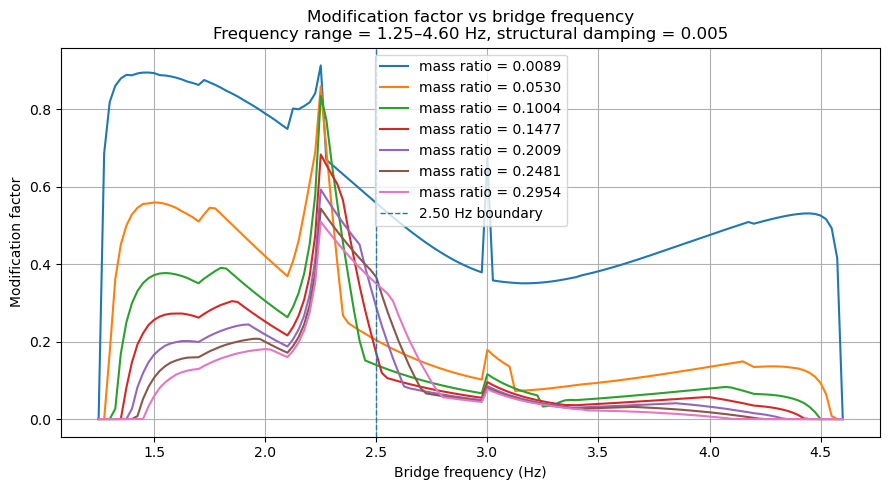

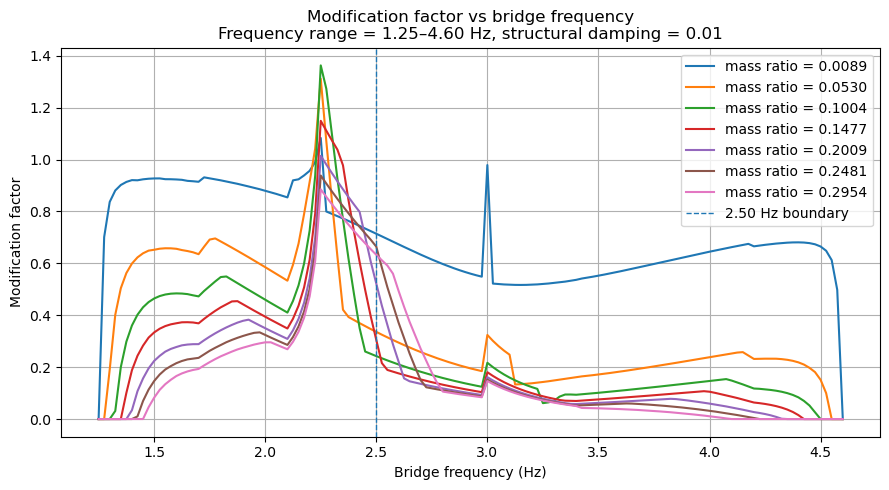

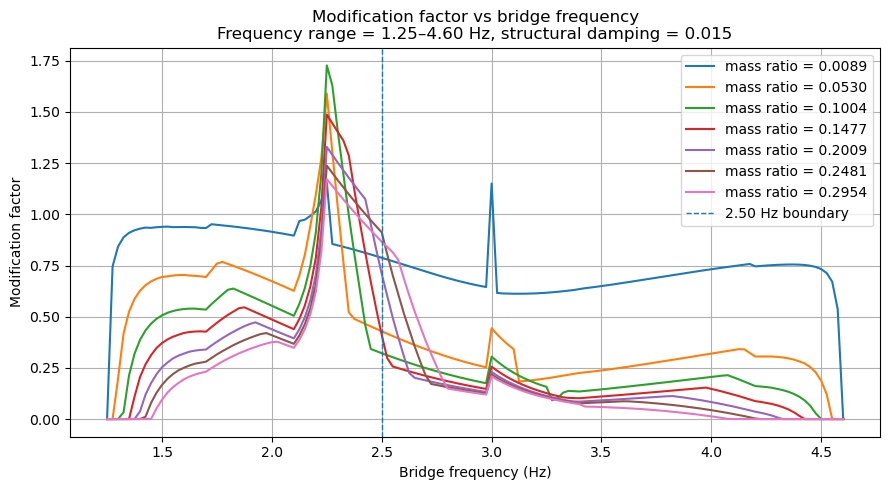

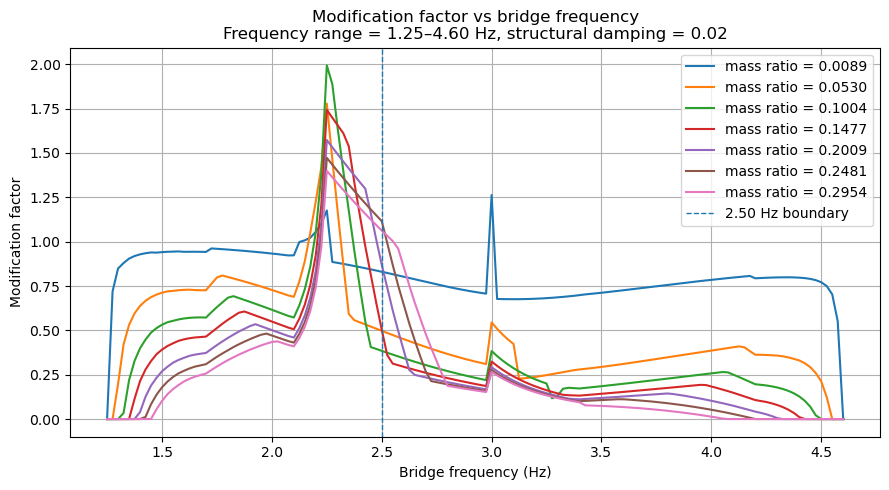

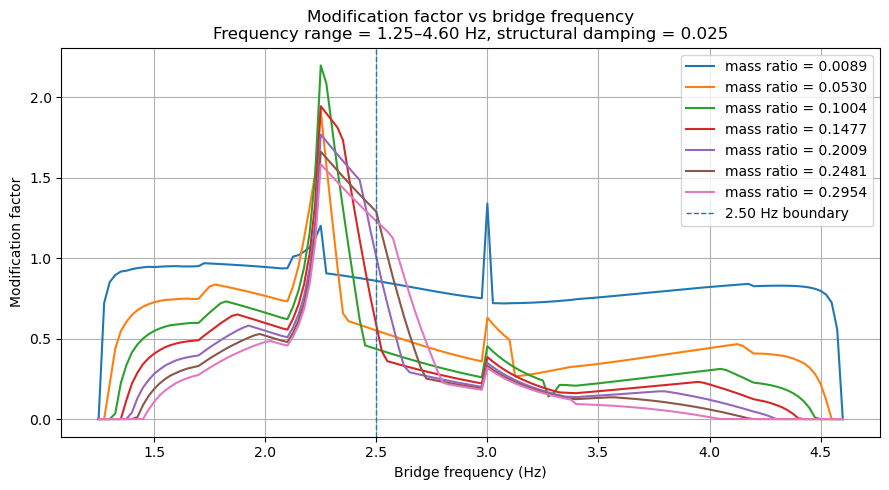

...

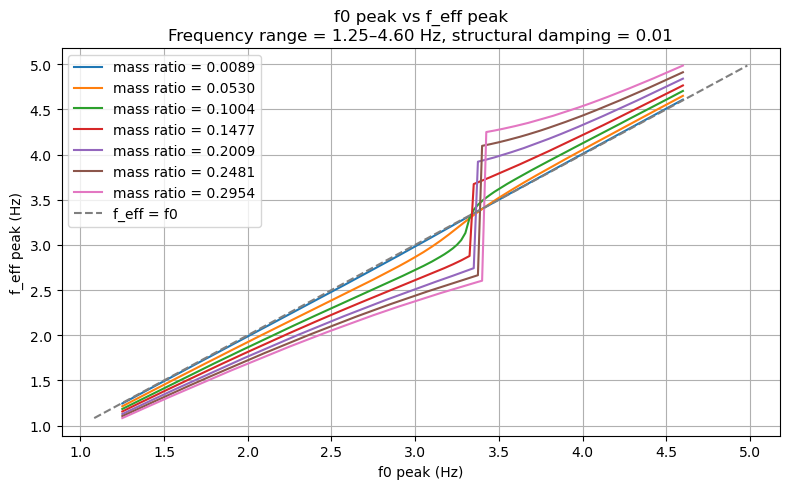

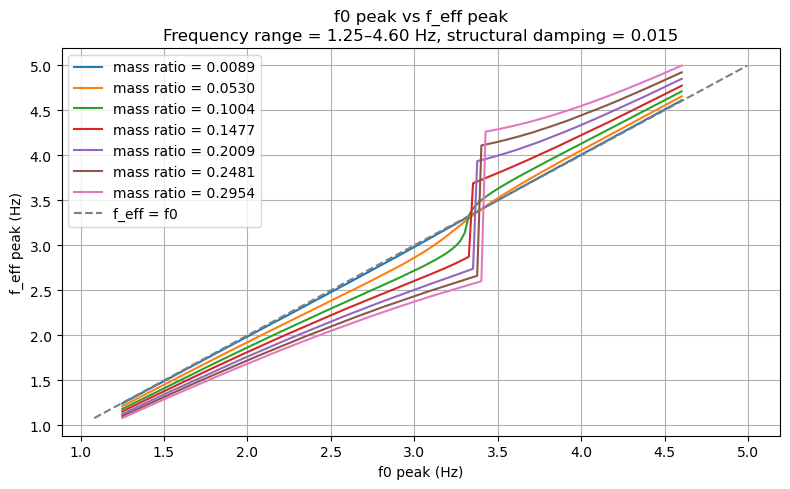

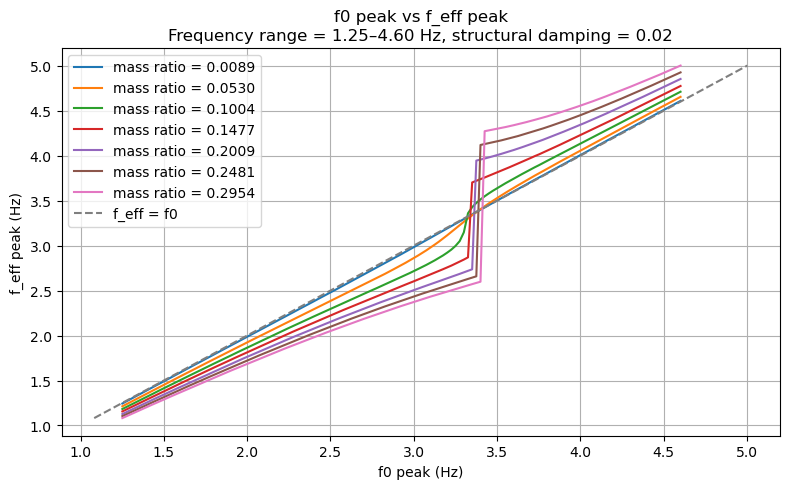

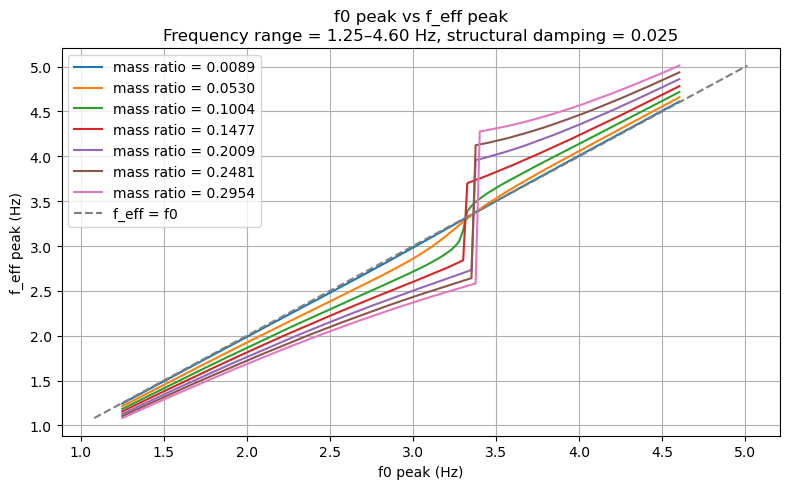

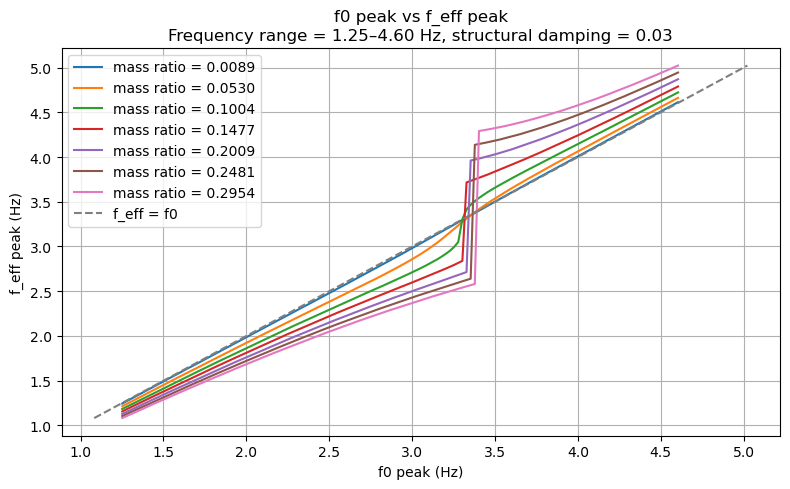

In [19]:
# -----------------------------
# FREQUENCY BANDS FOR PLOTTING
# -----------------------------

bands_to_combine = list(results_all.keys())

print("Plotting bands:", bands_to_combine)


def collect_metric_vs_frequency(results_all, bands_to_combine, beamdamp, density, key):
    """
    Collect one output quantity across one or more frequency bands.
    If the same bridge frequency appears in multiple bands, its values are averaged.
    """

    freq_to_values = {}

    for band_name in bands_to_combine:
        bridge_frequencies_band = sorted(results_all[band_name][beamdamp].keys())

        for bf in bridge_frequencies_band:
            arr = np.array(
                results_all[band_name][beamdamp][bf][density][key],
                dtype=float
            )

            value = np.mean(arr)

            if bf not in freq_to_values:
                freq_to_values[bf] = []

            freq_to_values[bf].append(value)

    freqs = np.array(sorted(freq_to_values.keys()))
    vals = np.array([np.mean(freq_to_values[bf]) for bf in freqs])

    return freqs, vals


# -----------------------------
# MASS-RATIO LABELS
# -----------------------------

mass_ratio_label = {}

first_band = bands_to_combine[0]
ref_damping = damping_values[0]
ref_bf = sorted(results_all[first_band][ref_damping].keys())[0]

for density in densities:
    arr = np.array(
        results_all[first_band][ref_damping][ref_bf][density]["modalpedmass_i"],
        dtype=float
    )
    mass_ratio_label[density] = np.mean(arr)

print("Mass-ratio labels:")
for density, mval in mass_ratio_label.items():
    print(f"density = {density:.4f}, mass ratio = {mval:.4f}")


# -----------------------------
# PLOTS:
# modification factor, FRF ratio, psi ratio
# x-axis = bridge frequency
# one graph for each structural damping
# -----------------------------

plot_specs = [
    ("modification_factor", "Modification factor"),
    ("frf_ratio", "FRF ratio"),
   
]

for key, ylabel in plot_specs:

    for beamdamp in damping_values:

        plt.figure(figsize=(9, 5))

        for density in densities:

            x_vals, y_vals = collect_metric_vs_frequency(
                results_all,
                bands_to_combine,
                beamdamp,
                density,
                key
            )

            mval = mass_ratio_label[density]

            plt.plot(
                x_vals,
                y_vals,
                label=f"mass ratio = {mval:.4f}"
            )

        plt.axvline(2.50, linestyle="--", linewidth=1, label="2.50 Hz boundary")

        plt.xlabel("Bridge frequency (Hz)")
        plt.ylabel(ylabel)
        plt.title(
            f"{ylabel} vs bridge frequency\n"
            f"Frequency range = 1.25–4.60 Hz, structural damping = {beamdamp}"
        )
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

# -----------------------------
# HELPER: collect f0_peak and f_eff_peak
# -----------------------------

def collect_f0_feff(results_all, bands_to_combine, beamdamp, density):
    """
    Collect f0_peak and f_eff_peak across one or more frequency bands.
    """

    freq_to_f0 = {}
    freq_to_feff = {}

    for band_name in bands_to_combine:
        bridge_frequencies_band = sorted(results_all[band_name][beamdamp].keys())

        for bf in bridge_frequencies_band:

            arr_f0 = np.array(
                results_all[band_name][beamdamp][bf][density]["f0_peak"],
                dtype=float
            )

            arr_feff = np.array(
                results_all[band_name][beamdamp][bf][density]["f_eff_peak"],
                dtype=float
            )

            f0_mean = np.mean(arr_f0)
            feff_mean = np.mean(arr_feff)

            if bf not in freq_to_f0:
                freq_to_f0[bf] = []
                freq_to_feff[bf] = []

            freq_to_f0[bf].append(f0_mean)
            freq_to_feff[bf].append(feff_mean)

    freqs = sorted(freq_to_f0.keys())

    x_vals = np.array([np.mean(freq_to_f0[bf]) for bf in freqs])
    y_vals = np.array([np.mean(freq_to_feff[bf]) for bf in freqs])

    return x_vals, y_vals


# -----------------------------
# PLOT: f0_peak vs f_eff_peak
# one graph for each structural damping
# -----------------------------

for beamdamp in damping_values:

    plt.figure(figsize=(8, 5))

    all_x = []
    all_y = []

    for density in densities:

        x_vals, y_vals = collect_f0_feff(
            results_all,
            bands_to_combine,
            beamdamp,
            density
        )

        all_x.extend(x_vals)
        all_y.extend(y_vals)

        mval = mass_ratio_label[density]

        plt.plot(
            x_vals,
            y_vals,
            label=f"mass ratio = {mval:.4f}"
        )

    lo = min(min(all_x), min(all_y))
    hi = max(max(all_x), max(all_y))

    plt.plot([lo, hi], [lo, hi], linestyle="--", label="f_eff = f0")

    plt.xlabel("f0 peak (Hz)")
    plt.ylabel("f_eff peak (Hz)")
    plt.title(
        f"f0 peak vs f_eff peak\n"
        f"Frequency range = 1.25–4.60 Hz, structural damping = {beamdamp}"
    )
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

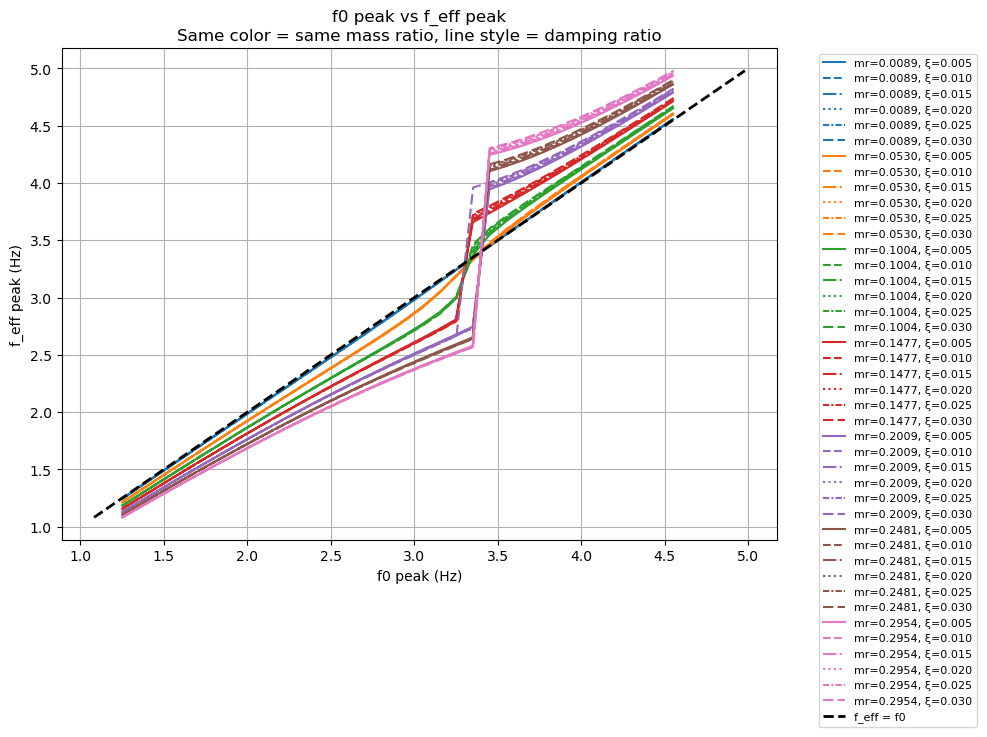

In [8]:
# -----------------------------
# COMBINED PLOT: f0_peak vs f_eff_peak
# same color for same mass ratio
# different line style for damping ratios
# -----------------------------

plt.figure(figsize=(10, 7))

# line styles for structural damping ratios
line_styles = ["-", "--", "-.", ":", (0, (3, 1, 1, 1)), (0, (5, 2))]

# use matplotlib default color cycle
default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# assign one color per density / mass ratio
density_to_color = {}
for i, density in enumerate(densities):
    density_to_color[density] = default_colors[i % len(default_colors)]

all_x = []
all_y = []

for density in densities:

    color = density_to_color[density]
    mval = mass_ratio_label[density]

    for i, beamdamp in enumerate(damping_values):

        ls = line_styles[i % len(line_styles)]

        x_vals, y_vals = collect_f0_feff(
            results_all,
            bands_to_combine,
            beamdamp,
            density
        )

        all_x.extend(x_vals)
        all_y.extend(y_vals)

        plt.plot(
            x_vals,
            y_vals,
            color=color,
            linestyle=ls,
           
            label=f"mr={mval:.4f}, ξ={beamdamp:.3f}"
        )

# reference line: no frequency shift
lo = min(min(all_x), min(all_y))
hi = max(max(all_x), max(all_y))

plt.plot(
    [lo, hi],
    [lo, hi],
    linestyle="--",
    linewidth=2,
    color="black",
    label="f_eff = f0"
)

plt.xlabel("f0 peak (Hz)")
plt.ylabel("f_eff peak (Hz)")
plt.title("f0 peak vs f_eff peak\nSame color = same mass ratio, line style = damping ratio")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

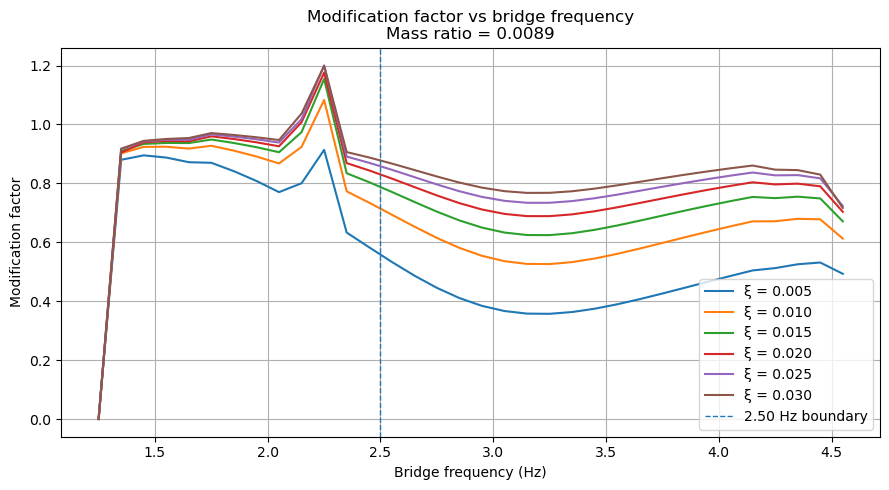

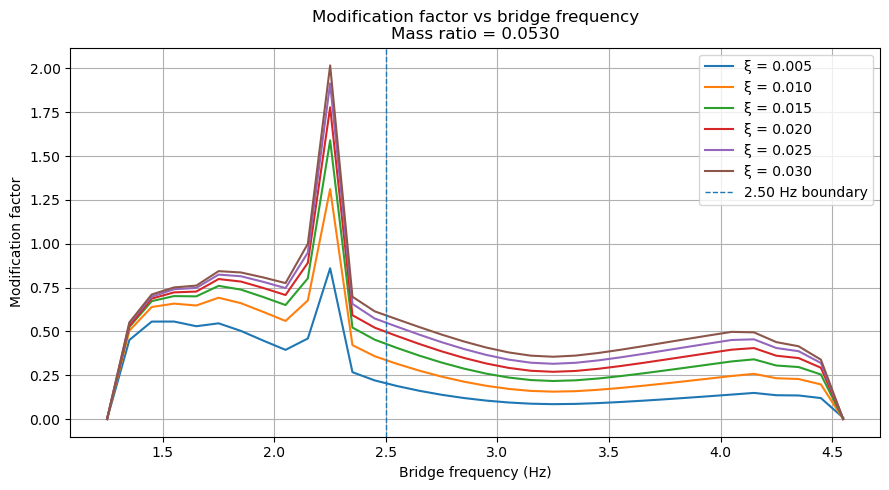

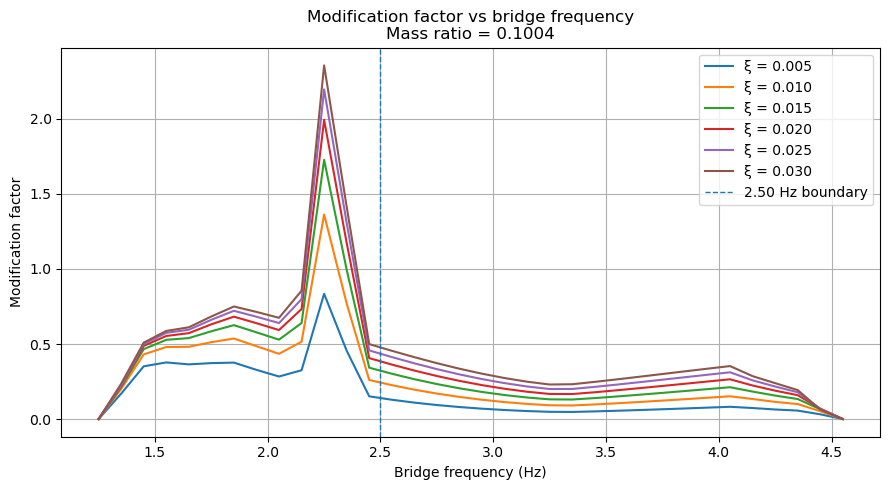

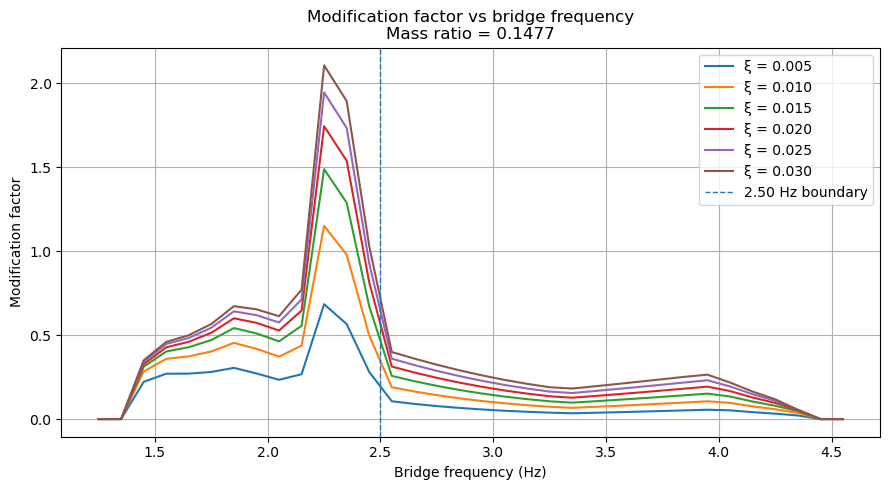

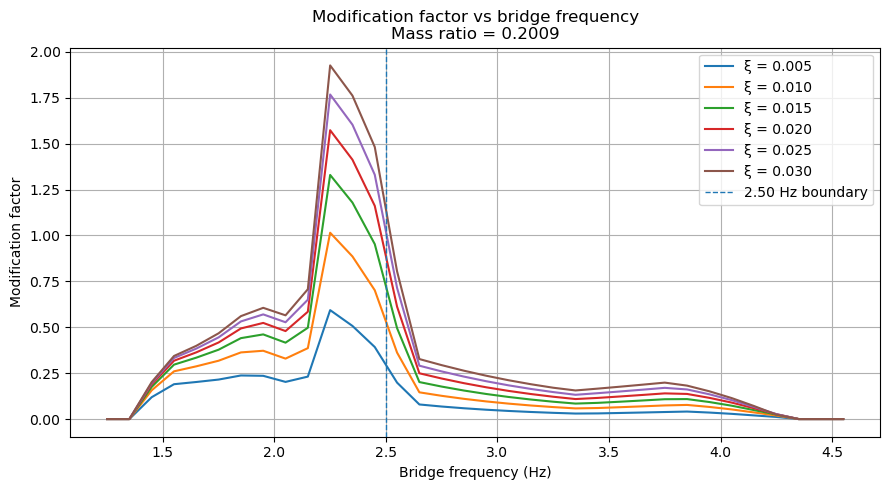

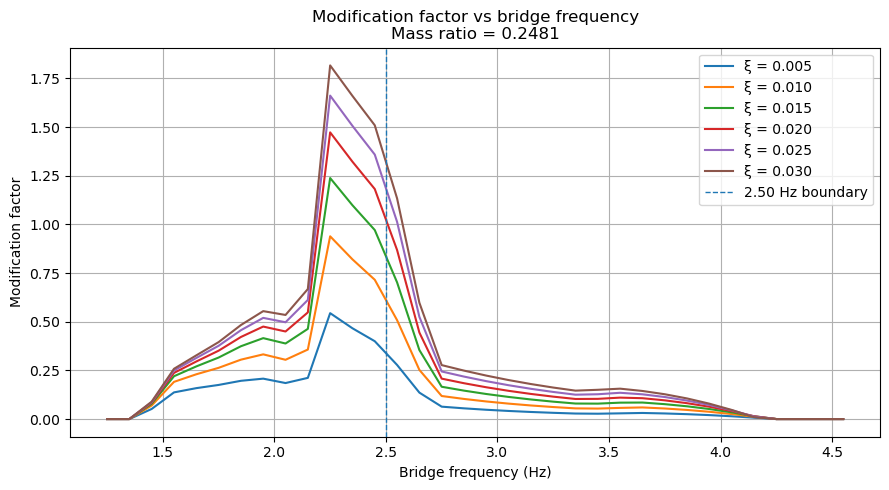

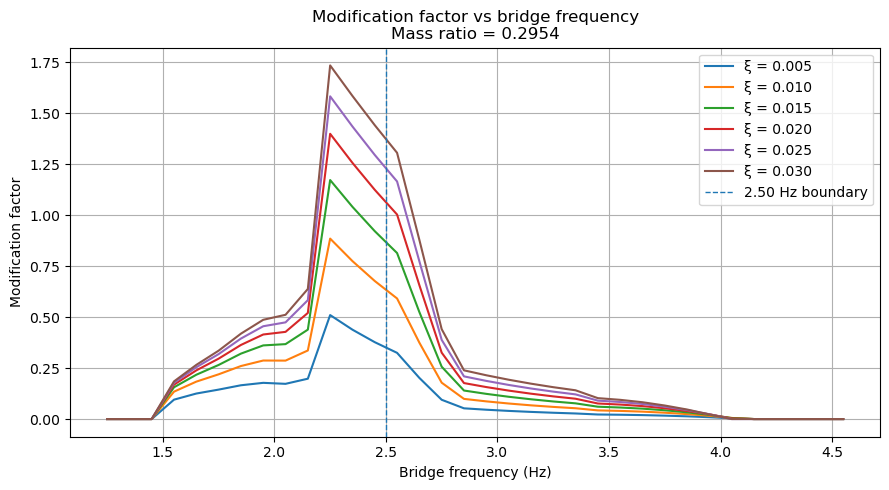

In [10]:
# -----------------------------
# PLOT: modification factor vs bridge frequency
# one graph for each mass ratio
# each graph contains all structural damping ratios
# -----------------------------

for density in densities:

    plt.figure(figsize=(9, 5))

    mval = mass_ratio_label[density]

    for beamdamp in damping_values:

        x_vals, y_vals = collect_metric_vs_frequency(
            results_all,
            bands_to_combine,
            beamdamp,
            density,
            "modification_factor"
        )

        plt.plot(
            x_vals,
            y_vals,
            label=f"ξ = {beamdamp:.3f}"
        )

    plt.axvline(2.50, linestyle="--", linewidth=1, label="2.50 Hz boundary")

    plt.xlabel("Bridge frequency (Hz)")
    plt.ylabel("Modification factor")
    plt.title(
        f"Modification factor vs bridge frequency\n"
        f"Mass ratio = {mval:.4f}"
    )
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [11]:
import numpy as np

# -----------------------------
# Helper: bracket lower and upper values
# -----------------------------
def bracket_values(values, target, name="target"):
    values = np.array(sorted(values), dtype=float)

    if target < values[0] or target > values[-1]:
        raise ValueError(
            f"{name} = {target} is outside available range "
            f"[{values[0]}, {values[-1]}]"
        )

    lower = values[values <= target].max()
    upper = values[values >= target].min()

    return lower, upper


# -----------------------------
# Helper: collect available frequencies from new results_all
# -----------------------------
def collect_available_frequencies(results_all, bands_to_combine, beamdamp):
    freqs = []

    for band_name in bands_to_combine:
        if band_name not in results_all:
            continue

        freqs.extend(list(results_all[band_name][beamdamp].keys()))

    freqs = np.array(sorted(set(freqs)), dtype=float)
    return freqs


# -----------------------------
# Helper: get data at one damping
# Interpolation over bridge frequency first,
# then interpolation over modal mass ratio
# -----------------------------
def interpolate_force_factor_one_damping_new(
    results_all,
    bands_to_combine,
    target_bf,
    target_mass_ratio,
    beamdamp,
    densities,
    factor_key="modification_factor"
):
    """
    Interpolates force/modification factor at one structural damping ratio.

    Steps:
    1. For each density/mass ratio, interpolate factor over bridge frequency.
    2. Then interpolate those values over modal mass ratio.
    """

    mass_ratio_grid = []
    factor_grid = []

    for density in densities:

        freq_to_values = {}
        mass_ratio_values = []

        for band_name in bands_to_combine:

            if band_name not in results_all:
                continue

            bridge_frequencies_band = sorted(results_all[band_name][beamdamp].keys())

            for bf in bridge_frequencies_band:

                data = results_all[band_name][beamdamp][bf][density]

                factor_arr = np.array(data[factor_key], dtype=float)
                mr_arr = np.array(data["modalpedmass_i"], dtype=float)

                factor_mean = np.mean(factor_arr)
                mr_mean = np.mean(mr_arr)

                if bf not in freq_to_values:
                    freq_to_values[bf] = []

                freq_to_values[bf].append(factor_mean)
                mass_ratio_values.append(mr_mean)

        freqs = np.array(sorted(freq_to_values.keys()), dtype=float)
        factors = np.array(
            [np.mean(freq_to_values[bf]) for bf in freqs],
            dtype=float
        )

        if target_bf < freqs.min() or target_bf > freqs.max():
            raise ValueError(
                f"target_bf = {target_bf} is outside available frequency range "
                f"[{freqs.min()}, {freqs.max()}]"
            )

        # interpolate over bridge frequency for this density
        factor_at_bf = np.interp(target_bf, freqs, factors)

        # representative mass ratio for this density
        mass_ratio_mean = np.mean(mass_ratio_values)

        mass_ratio_grid.append(mass_ratio_mean)
        factor_grid.append(factor_at_bf)

    mass_ratio_grid = np.array(mass_ratio_grid, dtype=float)
    factor_grid = np.array(factor_grid, dtype=float)

    # sort by mass ratio before interpolation
    sort_idx = np.argsort(mass_ratio_grid)
    mass_ratio_grid = mass_ratio_grid[sort_idx]
    factor_grid = factor_grid[sort_idx]

    if target_mass_ratio < mass_ratio_grid.min() or target_mass_ratio > mass_ratio_grid.max():
        raise ValueError(
            f"target_mass_ratio = {target_mass_ratio} is outside available range "
            f"[{mass_ratio_grid.min()}, {mass_ratio_grid.max()}]"
        )

    # interpolate over modal mass ratio
    factor_target = np.interp(
        target_mass_ratio,
        mass_ratio_grid,
        factor_grid
    )

    return factor_target, mass_ratio_grid, factor_grid


# -----------------------------
# Full interpolation:
# bridge frequency + mass ratio + damping ratio
# -----------------------------
def interpolate_force_factor_exact_point_new(
    results_all,
    target_bf,
    target_beamdamp,
    target_mass_ratio,
    damping_values,
    densities,
    bands_to_combine=None,
    factor_key="modification_factor"
):
    """
    Interpolate modification factor at:

        target bridge frequency
        target structural damping ratio
        target modal mass ratio

    New results_all structure:

        results_all[band_name][beamdamp][bf][density][factor_key]
    """

    if bands_to_combine is None:
        bands_to_combine = list(results_all.keys())

    lower_damp, upper_damp = bracket_values(
        damping_values,
        target_beamdamp,
        name="target_beamdamp"
    )

    # If exact damping ratio exists
    if np.isclose(lower_damp, upper_damp):

        ff_target, mr_grid, ff_grid = interpolate_force_factor_one_damping_new(
            results_all=results_all,
            bands_to_combine=bands_to_combine,
            target_bf=target_bf,
            target_mass_ratio=target_mass_ratio,
            beamdamp=lower_damp,
            densities=densities,
            factor_key=factor_key
        )

        details = {
            "lower_damp": lower_damp,
            "upper_damp": upper_damp,
            "ff_lower": ff_target,
            "ff_upper": ff_target,
            "damping_weight": 0.0,
            "mr_grid_lower": mr_grid,
            "ff_grid_lower": ff_grid,
            "mr_grid_upper": mr_grid,
            "ff_grid_upper": ff_grid,
        }

        return ff_target, details

    # Lower damping interpolation
    ff_lower, mr_grid_lower, ff_grid_lower = interpolate_force_factor_one_damping_new(
        results_all=results_all,
        bands_to_combine=bands_to_combine,
        target_bf=target_bf,
        target_mass_ratio=target_mass_ratio,
        beamdamp=lower_damp,
        densities=densities,
        factor_key=factor_key
    )

    # Upper damping interpolation
    ff_upper, mr_grid_upper, ff_grid_upper = interpolate_force_factor_one_damping_new(
        results_all=results_all,
        bands_to_combine=bands_to_combine,
        target_bf=target_bf,
        target_mass_ratio=target_mass_ratio,
        beamdamp=upper_damp,
        densities=densities,
        factor_key=factor_key
    )

    # Linear interpolation over damping ratio
    w = (target_beamdamp - lower_damp) / (upper_damp - lower_damp)

    ff_target = (1.0 - w) * ff_lower + w * ff_upper

    details = {
        "lower_damp": lower_damp,
        "upper_damp": upper_damp,
        "ff_lower": ff_lower,
        "ff_upper": ff_upper,
        "damping_weight": w,
        "mr_grid_lower": mr_grid_lower,
        "ff_grid_lower": ff_grid_lower,
        "mr_grid_upper": mr_grid_upper,
        "ff_grid_upper": ff_grid_upper,
    }

    return ff_target, details

Lower damping = 0.015
Upper damping = 0.02
Lower mass ratio = 0.10038570253646621 from density = 0.3333
Upper mass ratio = 0.14769999999999997 from density = 0.5


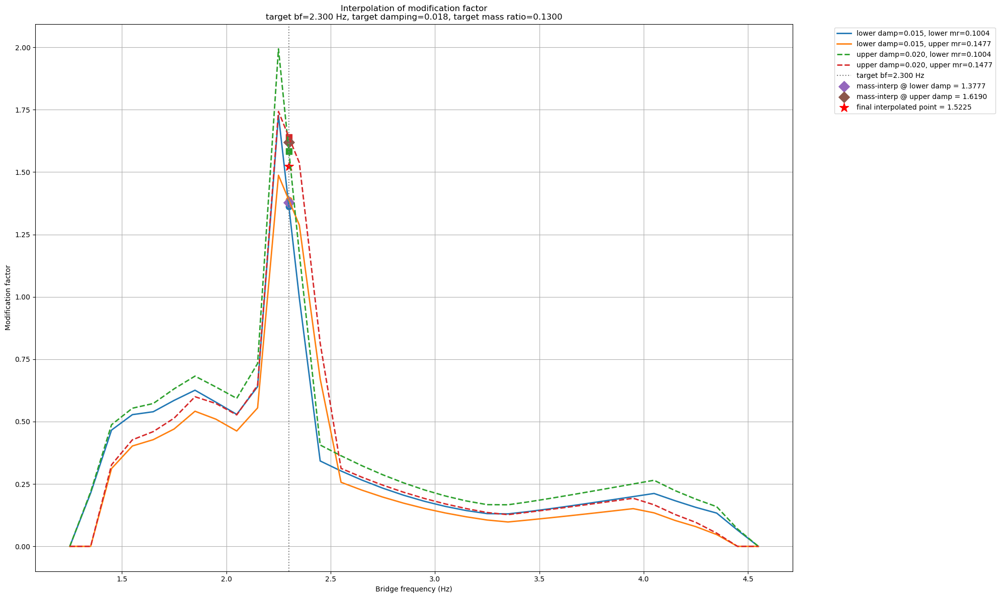

In [17]:
target_bf = 2.30
target_beamdamp = 0.018
target_mass_ratio = 0.13

bands_to_combine = ["1.25_to_4.60"]

force_factor_target, details = interpolate_force_factor_exact_point_new(
    results_all=results_all,
    target_bf=target_bf,
    target_beamdamp=target_beamdamp,
    target_mass_ratio=target_mass_ratio,
    damping_values=damping_values,
    densities=densities,
    bands_to_combine=bands_to_combine,
    factor_key="modification_factor"
)

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Helper: bracket values
# -----------------------------
def bracket_values(values, target, name="target"):
    values = np.array(sorted(values), dtype=float)

    if target < values[0] or target > values[-1]:
        raise ValueError(
            f"{name} = {target} is outside available range "
            f"[{values[0]}, {values[-1]}]"
        )

    lower = values[values <= target].max()
    upper = values[values >= target].min()

    return lower, upper


# -----------------------------
# Build mass-ratio labels from results_all
# -----------------------------
mass_ratio_label = {}

first_band = bands_to_combine[0]
ref_damping = damping_values[0]
ref_bf = sorted(results_all[first_band][ref_damping].keys())[0]

for density in densities:
    arr = np.array(
        results_all[first_band][ref_damping][ref_bf][density]["modalpedmass_i"],
        dtype=float
    )
    mass_ratio_label[density] = np.mean(arr)


# -----------------------------
# Helper: find density closest to a given mass ratio
# -----------------------------
def density_for_mass_ratio(target_mr, densities, mass_ratio_label):
    return min(densities, key=lambda d: abs(mass_ratio_label[d] - target_mr))


# -----------------------------
# Use interpolation details
# -----------------------------
lower_damp = details["lower_damp"]
upper_damp = details["upper_damp"]

mr_grid_lower = np.array(details["mr_grid_lower"], dtype=float)
mr_grid_upper = np.array(details["mr_grid_upper"], dtype=float)

# bracket target mass ratio
mr_lower, mr_upper = bracket_values(
    mr_grid_lower,
    target_mass_ratio,
    name="target_mass_ratio"
)

# corresponding densities
density_lower = density_for_mass_ratio(mr_lower, densities, mass_ratio_label)
density_upper = density_for_mass_ratio(mr_upper, densities, mass_ratio_label)

mr_lower_label = mass_ratio_label[density_lower]
mr_upper_label = mass_ratio_label[density_upper]

print("Lower damping =", lower_damp)
print("Upper damping =", upper_damp)
print("Lower mass ratio =", mr_lower_label, "from density =", density_lower)
print("Upper mass ratio =", mr_upper_label, "from density =", density_upper)


# -----------------------------
# Helper: collect metric vs frequency
# -----------------------------
def collect_metric_vs_frequency(results_all, bands_to_combine, beamdamp, density, key):
    freq_to_values = {}

    for band_name in bands_to_combine:
        bridge_frequencies_band = sorted(results_all[band_name][beamdamp].keys())

        for bf in bridge_frequencies_band:
            arr = np.array(
                results_all[band_name][beamdamp][bf][density][key],
                dtype=float
            )

            value = np.mean(arr)

            if bf not in freq_to_values:
                freq_to_values[bf] = []

            freq_to_values[bf].append(value)

    freqs = np.array(sorted(freq_to_values.keys()))
    vals = np.array([np.mean(freq_to_values[bf]) for bf in freqs])

    return freqs, vals


# -----------------------------
# Collect the four bracketing curves
# -----------------------------
x_ll, y_ll = collect_metric_vs_frequency(
    results_all, bands_to_combine, lower_damp, density_lower, "modification_factor"
)

x_lu, y_lu = collect_metric_vs_frequency(
    results_all, bands_to_combine, lower_damp, density_upper, "modification_factor"
)

x_ul, y_ul = collect_metric_vs_frequency(
    results_all, bands_to_combine, upper_damp, density_lower, "modification_factor"
)

x_uu, y_uu = collect_metric_vs_frequency(
    results_all, bands_to_combine, upper_damp, density_upper, "modification_factor"
)


# -----------------------------
# Interpolated values at target_bf on the 4 curves
# -----------------------------
ff_ll = np.interp(target_bf, x_ll, y_ll)   # lower damp, lower mr
ff_lu = np.interp(target_bf, x_lu, y_lu)   # lower damp, upper mr
ff_ul = np.interp(target_bf, x_ul, y_ul)   # upper damp, lower mr
ff_uu = np.interp(target_bf, x_uu, y_uu)   # upper damp, upper mr

ff_lower = details["ff_lower"]   # after mass-ratio interpolation at lower damping
ff_upper = details["ff_upper"]   # after mass-ratio interpolation at upper damping


# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(20, 12))

# four bracketing curves
plt.plot(
    x_ll, y_ll, linewidth=2,
    label=f"lower damp={lower_damp:.3f}, lower mr={mr_lower_label:.4f}"
)

plt.plot(
    x_lu, y_lu, linewidth=2,
    label=f"lower damp={lower_damp:.3f}, upper mr={mr_upper_label:.4f}"
)

plt.plot(
    x_ul, y_ul, linewidth=2, linestyle="--",
    label=f"upper damp={upper_damp:.3f}, lower mr={mr_lower_label:.4f}"
)

plt.plot(
    x_uu, y_uu, linewidth=2, linestyle="--",
    label=f"upper damp={upper_damp:.3f}, upper mr={mr_upper_label:.4f}"
)

# vertical line at target bridge frequency
plt.axvline(target_bf, color="gray", linestyle=":", linewidth=1.5, label=f"target bf={target_bf:.3f} Hz")

# points on the four bracketing curves at target_bf
plt.scatter([target_bf], [ff_ll], s=80, marker="o")
plt.scatter([target_bf], [ff_lu], s=80, marker="o")
plt.scatter([target_bf], [ff_ul], s=80, marker="s")
plt.scatter([target_bf], [ff_uu], s=80, marker="s")

# interpolated value at lower damping
plt.scatter(
    [target_bf], [ff_lower],
    s=120, marker="D",
    label=f"mass-interp @ lower damp = {ff_lower:.4f}"
)

# interpolated value at upper damping
if not np.isclose(lower_damp, upper_damp):
    plt.scatter(
        [target_bf], [ff_upper],
        s=120, marker="D",
        label=f"mass-interp @ upper damp = {ff_upper:.4f}"
    )

# final interpolated point
plt.scatter(
    [target_bf], [force_factor_target],
    s=180, marker="*", color="red",
    label=f"final interpolated point = {force_factor_target:.4f}"
)

plt.xlabel("Bridge frequency (Hz)")
plt.ylabel("Modification factor")
plt.title(
    f"Interpolation of modification factor\n"
    f"target bf={target_bf:.3f} Hz, target damping={target_beamdamp:.3f}, "
    f"target mass ratio={target_mass_ratio:.4f}"
)
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [18]:
import importlib
import biascodefunction

biascodefunction = importlib.reload(biascodefunction)

from biascodefunction import (
    peak_rms_distribution,
    percentile_acc_distribution,
    peak_abs_acc_distribution,
    run_code_response_from_mc_inputs,
    sliding_rms,
    interpolate_modification_factor_banded
)

print("Reloaded biascodefunction.py")

Reloaded biascodefunction.py


Loaded NEW modification-factor database.
Available bands: ['1.25_to_4.60']
Available damping values: [0.005, 0.01, 0.015, 0.02, 0.025, 0.03]
Available densities: [0.0333, 0.1667, 0.3333, 0.5, 0.6667, 0.8333, 1.0]

Selected case
-------------
Bridge frequency = 2.400 Hz
Target density   = 0.8300 ped/m²
Actual density   = 0.8300 ped/m²
Total peds       = 83
Tocity, Outcity  = 41, 42

MC output
---------
Acceleration array shape = (24, 10001)
Mean modal mass ratio    = 0.250029

Force-factor interpolation input
--------------------------------
MC mean modal mass ratio      = 0.250029
Mass ratio used for x-factor  = 0.250029


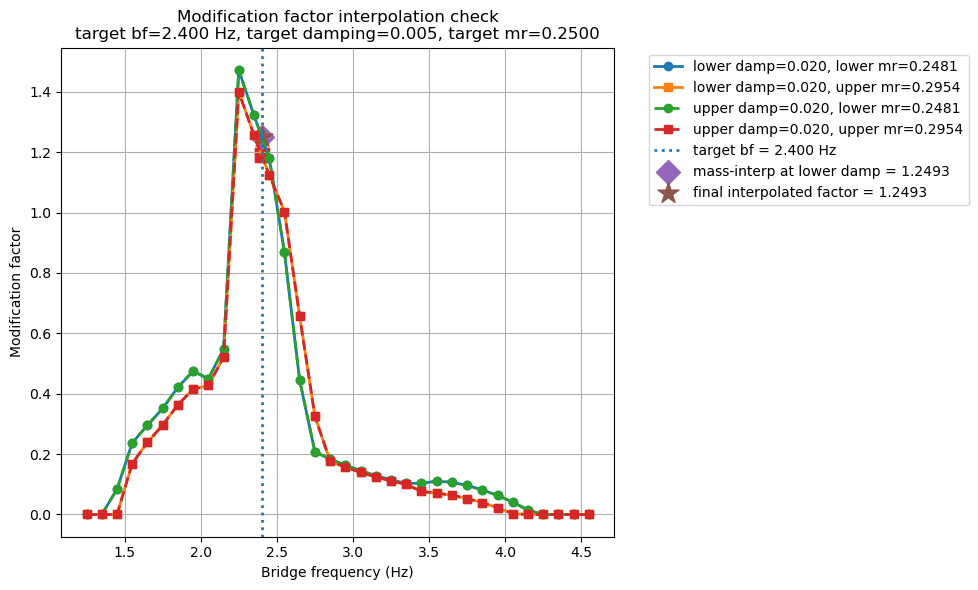


--- Simplified direct force factor rule ---
Bridge frequency                 = 2.400000 Hz
Interpolated modification factor = 1.249254
Force reduction factor used      = 1.249254
Density kept unchanged?          = True
Tocity, Outcity                  = 41, 42
Mass ratio used in simplified    = 0.250029

Response statistics
-------------------

Peak 1-sec RMS
  MC mean                 = 2.618512
  MC std                  = 0.468474
  MC 5%                   = 2.174034
  MC median               = 2.657142
  MC 95%                  = 3.212611
  Original code prediction = 1.342718
  Simplified prediction    = 2.096794
  Code mean bias           = 1.950158
  Code 5-95% bias          = [1.619129, 2.392618]
  Simplified mean bias     = 1.248817
  Simplified 5-95% bias    = [1.036837, 1.532154]

Peak absolute acceleration
  MC mean                 = 3.813547
  MC std                  = 0.688531
  MC 5%                   = 3.167458
  MC median               = 3.876427
  MC 95%                

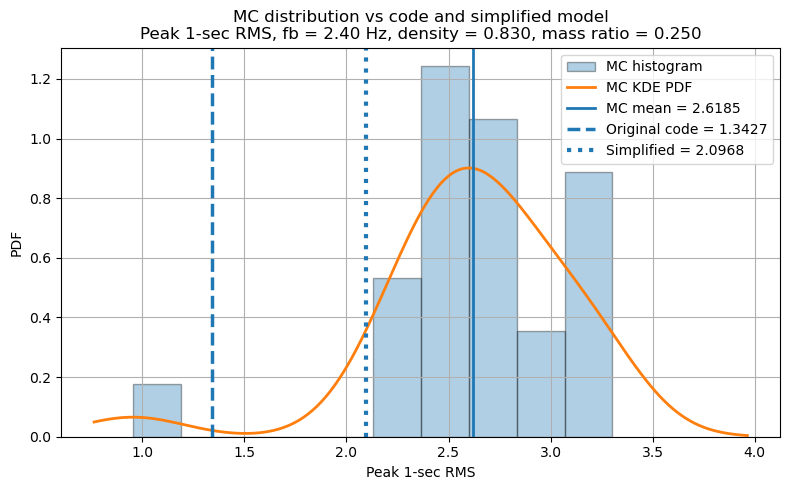

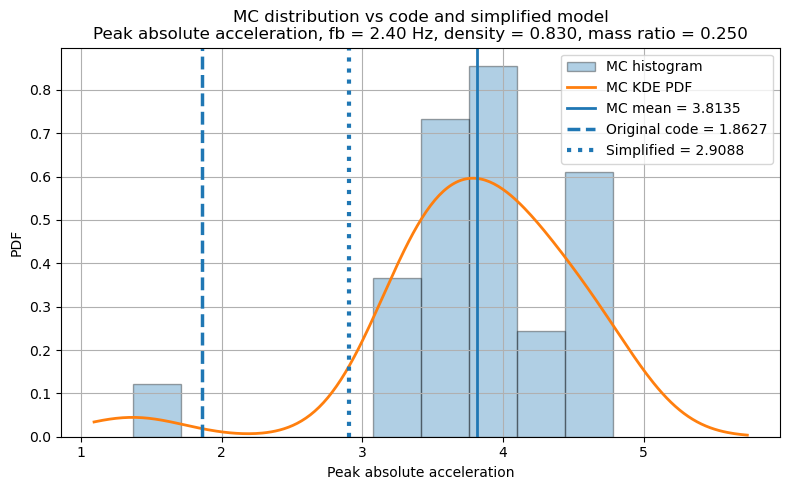

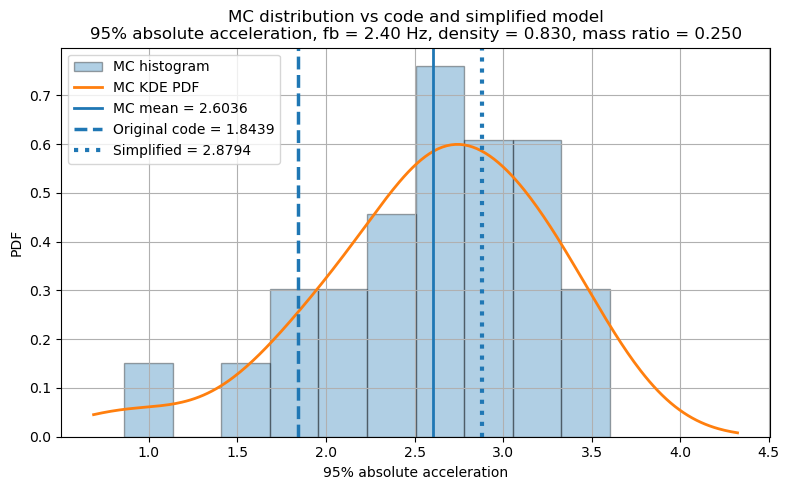

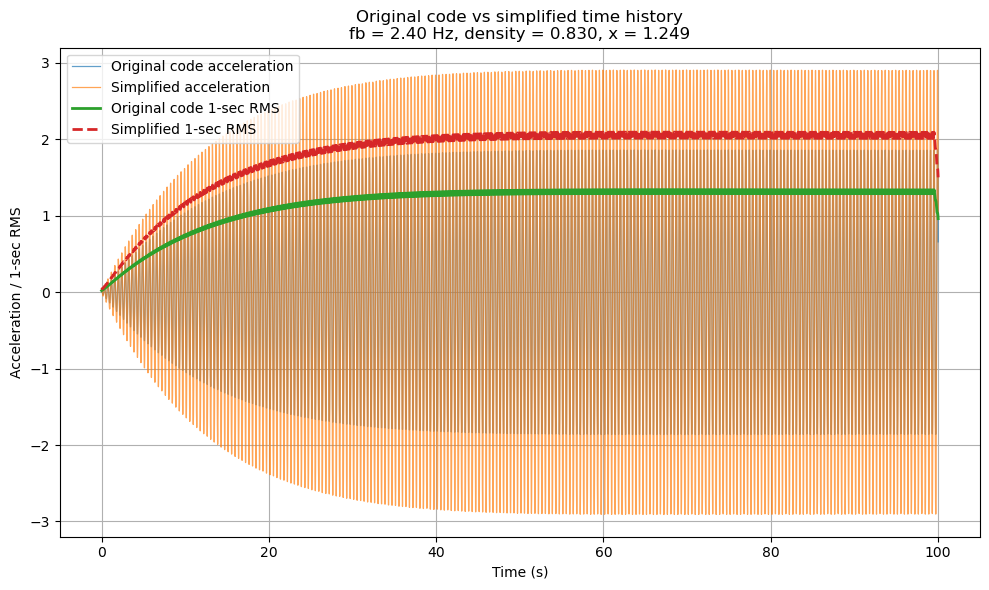

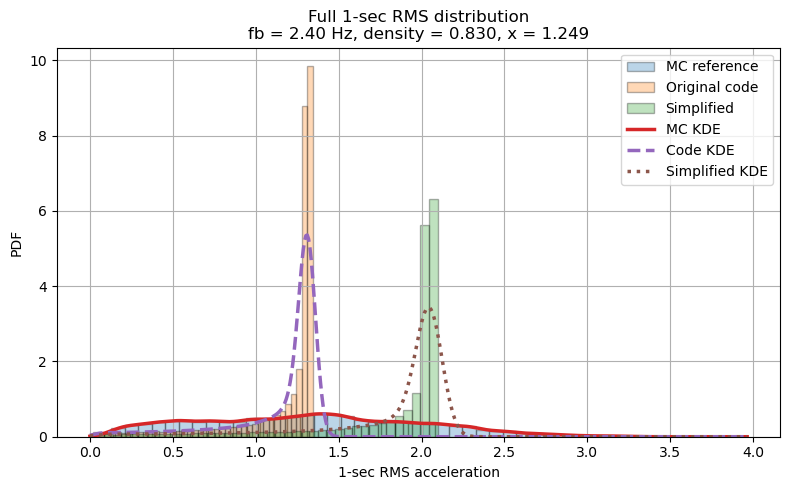


Full 1-sec RMS distribution statistics
--------------------------------------

MC reference
  Mean = 1.321977
  Std  = 0.667518
  5%   = 0.287963
  50%  = 1.317796
  95%  = 2.448990
  Peak = 3.302846

Original code
  Mean = 1.164568
  Std  = 0.285174
  5%   = 0.439128
  50%  = 1.292515
  95%  = 1.340038
  Peak = 1.342718

Simplified
  Mean = 1.818595
  Std  = 0.445329
  5%   = 0.685743
  50%  = 2.018397
  95%  = 2.092609
  Peak = 2.096794

Distribution-based 1-sec RMS bias: MC / model
---------------------------------------------
Original code mean-RMS bias = 1.135165
Simplified mean-RMS bias    = 0.726922

Original code 50% RMS bias  = 1.019560
Simplified 50% RMS bias     = 0.652892

Original code 95% RMS bias  = 1.827552
Simplified 95% RMS bias     = 1.170305


In [40]:
# ==================================================
# MC DISTRIBUTIONS + CODE + SIMPLIFIED PREDICTION
# Selected bridge frequency and density
# ==================================================

import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import torch
torch.set_num_threads(1)

import numpy as np
import matplotlib.pyplot as plt
import multiprocessing as mp
from scipy.stats import gaussian_kde
import pickle

from bias import run_simulation

from biascodefunction import (
    peak_rms_distribution,
    percentile_acc_distribution,
    peak_abs_acc_distribution,
    run_code_response_from_mc_inputs,
    sliding_rms,
    interpolate_modification_factor_banded
)

# --------------------------------------------------
# USER SETTINGS
# --------------------------------------------------
NUM_SIMULATIONS = 24
NUM_PROCESSES = 12

hht = 0.01
steady_start_time = 10.0
linear_mass = 500.0

peddamp = 0.30
pedBodyF = 3.10

Length = 50.0
Width = 2.0

target_bf = 2.4
target_beamdamp = 0.005
density = 0.83

eps = 1e-12

# Force-factor database
FORCE_FACTOR_FILE = "new_modification_factor_results_2.pkl"

# Mass-ratio cap for interpolation database
MR_MIN_DATABASE = 0.0089
MR_MIN_USED = 0.0090
MR_MAX_DATABASE = 0.2954
MR_MAX_USED = 0.29


# --------------------------------------------------
# Helper: cap MC mass ratio inside interpolation range
# --------------------------------------------------
def cap_mass_ratio_for_interpolation(mc_mass_ratio):
    mc_mass_ratio = float(mc_mass_ratio)

    if mc_mass_ratio < MR_MIN_DATABASE:
        return MR_MIN_USED
    elif mc_mass_ratio > MR_MAX_DATABASE:
        return MR_MAX_USED
    else:
        return mc_mass_ratio


# --------------------------------------------------
# Load new force/modification-factor database
# --------------------------------------------------
with open(FORCE_FACTOR_FILE, "rb") as f:
    ff_data = pickle.load(f)

ff_results_all = ff_data["results_all"]
ff_densities = ff_data["densities"]
ff_damping_values = ff_data["damping_values"]
ff_pedBodyF = ff_data["pedBodyF"]

# New database uses frequency bands
ff_bands_to_combine = list(ff_results_all.keys())

print("Loaded NEW modification-factor database.")
print("Available bands:", ff_bands_to_combine)
print("Available damping values:", ff_damping_values)
print("Available densities:", ff_densities)


# --------------------------------------------------
# Convert density to pedestrian numbers
# --------------------------------------------------
BeamFreq = np.array([target_bf, 4 * target_bf])
Beamdamp = np.array([target_beamdamp])

total_peds_float = density * Length * Width
total_peds_int = int(round(total_peds_float))
total_peds_int = max(1, total_peds_int)

Tocity = total_peds_int // 2
Outcity = total_peds_int - Tocity

actual_density = (Tocity + Outcity) / (Length * Width)

print("\nSelected case")
print("-------------")
print(f"Bridge frequency = {target_bf:.3f} Hz")
print(f"Target density   = {density:.4f} ped/m²")
print(f"Actual density   = {actual_density:.4f} ped/m²")
print(f"Total peds       = {total_peds_int}")
print(f"Tocity, Outcity  = {Tocity}, {Outcity}")


# --------------------------------------------------
# Run MC reference simulations
# --------------------------------------------------
rng = np.random.default_rng(12345)
seeds = rng.integers(0, 2**31 - 1, size=NUM_SIMULATIONS)

args_list = [
    (
        int(seeds[i]),
        peddamp,
        pedBodyF,
        BeamFreq,
        Beamdamp,
        Tocity,
        Outcity,
        Length,
        Width
    )
    for i in range(NUM_SIMULATIONS)
]

try:
    mp.set_start_method("spawn")
except RuntimeError:
    pass

ctx = mp.get_context("spawn")

with ctx.Pool(processes=NUM_PROCESSES) as pool:
    results = pool.map(run_simulation, args_list)


# --------------------------------------------------
# Extract MC acceleration histories and mass ratios
# --------------------------------------------------
accelerations = np.array([r[0] for r in results])
mean_mass_ratios = np.array([r[1] for r in results])

overall_mean_mass_ratio = np.mean(mean_mass_ratios)

print("\nMC output")
print("---------")
print("Acceleration array shape =", accelerations.shape)
print(f"Mean modal mass ratio    = {overall_mean_mass_ratio:.6f}")


# --------------------------------------------------
# Remove initial transient
# --------------------------------------------------
steady_start_idx = int(round(steady_start_time / hht))

if steady_start_idx >= accelerations.shape[1]:
    raise ValueError("steady_start_time is longer than acceleration time history.")

accelerations_ss = accelerations[:, steady_start_idx:]


# --------------------------------------------------
# MC response distributions
# --------------------------------------------------
rms_histories, peak_rms_values = peak_rms_distribution(
    accelerations_ss,
    dt=hht,
    window_sec=1.0
)

peak_abs_values = peak_abs_acc_distribution(
    accelerations_ss
)

p95_abs_values = percentile_acc_distribution(
    accelerations_ss,
    percentile=95,
    use_abs=True
)

mc_distributions = {
    "Peak 1-sec RMS": peak_rms_values,
    "Peak absolute acceleration": peak_abs_values,
    "95% absolute acceleration": p95_abs_values,
}


# --------------------------------------------------
# Original deterministic/code model
# --------------------------------------------------
t_end = accelerations.shape[1] * hht

code_result, code_measures = run_code_response_from_mc_inputs(
    Tocity=Tocity,
    Outcity=Outcity,
    Length=Length,
    Width=Width,
    BeamFreq=BeamFreq,
    Beamdamp=Beamdamp,
    linear_mass=linear_mass,
    hht=hht,
    t_end=t_end,
    mean_mass_ratio=overall_mean_mass_ratio,
    mass_ratio_limit=0.05,
    steady_start_time=steady_start_time,
    numbers=1,
    modify_both_modes=False,
    force_reduction_factor=1.0
)


# --------------------------------------------------
# Simplified model
# Interpolate force factor using MC mean modal mass ratio
# --------------------------------------------------
target_mass_ratio_used = cap_mass_ratio_for_interpolation(
    overall_mean_mass_ratio
)

print("\nForce-factor interpolation input")
print("--------------------------------")
print(f"MC mean modal mass ratio      = {overall_mean_mass_ratio:.6f}")
print(f"Mass ratio used for x-factor  = {target_mass_ratio_used:.6f}")

x_factor, interp_details = interpolate_modification_factor_banded(
    results_all=ff_results_all,
    target_bf=target_bf,
    target_beamdamp=0.02,
    target_mass_ratio=target_mass_ratio_used,
    damping_values=ff_damping_values,
    densities=ff_densities,
    bands_to_combine=ff_bands_to_combine,
    factor_key="modification_factor"
)

# --------------------------------------------------
# Plot interpolation check:
# x-axis = bridge frequency
# y-axis = modification factor
# Shows lower/upper damping and lower/upper mass-ratio curves
# --------------------------------------------------

def bracket_values_local(values, target, name="target"):
    values = np.array(sorted(values), dtype=float)

    if target < values[0] or target > values[-1]:
        raise ValueError(
            f"{name} = {target} is outside range "
            f"[{values[0]}, {values[-1]}]"
        )

    lower = values[values <= target].max()
    upper = values[values >= target].min()

    return lower, upper


def get_mass_ratio_label_from_database(results_all, bands_to_combine, damping_values, densities):
    """
    Representative database mass ratio for each density.
    """
    first_band = bands_to_combine[0]
    ref_damping = damping_values[0]
    ref_bf = sorted(results_all[first_band][ref_damping].keys())[0]

    mass_ratio_label = {}

    for den in densities:
        arr = np.asarray(
            results_all[first_band][ref_damping][ref_bf][den]["modalpedmass_i"],
            dtype=float
        )
        mass_ratio_label[den] = np.mean(arr)

    return mass_ratio_label


def density_for_mass_ratio(target_mr, densities, mass_ratio_label):
    """
    Find database density closest to a given modal mass ratio.
    """
    return min(densities, key=lambda den: abs(mass_ratio_label[den] - target_mr))


def collect_factor_vs_bridge_frequency(results_all, bands_to_combine, beamdamp, density, factor_key):
    """
    Collect mean modification factor vs bridge frequency.
    """
    freq_to_values = {}

    for band_name in bands_to_combine:

        if band_name not in results_all:
            continue

        for bf in sorted(results_all[band_name][beamdamp].keys()):

            arr = np.asarray(
                results_all[band_name][beamdamp][bf][density][factor_key],
                dtype=float
            )

            if bf not in freq_to_values:
                freq_to_values[bf] = []

            freq_to_values[bf].append(np.mean(arr))

    freqs = np.array(sorted(freq_to_values.keys()), dtype=float)
    vals = np.array([np.mean(freq_to_values[bf]) for bf in freqs], dtype=float)

    return freqs, vals


# -----------------------------
# Extract damping brackets
# -----------------------------
lower_damp = interp_details["lower_damp"]
upper_damp = interp_details["upper_damp"]

# -----------------------------
# Find database mass-ratio brackets
# -----------------------------
ff_mass_ratio_label = get_mass_ratio_label_from_database(
    results_all=ff_results_all,
    bands_to_combine=ff_bands_to_combine,
    damping_values=ff_damping_values,
    densities=ff_densities
)

database_mass_ratios = np.array(list(ff_mass_ratio_label.values()), dtype=float)

mr_lower, mr_upper = bracket_values_local(
    database_mass_ratios,
    target_mass_ratio_used,
    name="target_mass_ratio_used"
)

density_lower = density_for_mass_ratio(
    mr_lower,
    ff_densities,
    ff_mass_ratio_label
)

density_upper = density_for_mass_ratio(
    mr_upper,
    ff_densities,
    ff_mass_ratio_label
)

mr_lower_actual = ff_mass_ratio_label[density_lower]
mr_upper_actual = ff_mass_ratio_label[density_upper]

# -----------------------------
# Collect four bracketing curves
# -----------------------------
x_ll, y_ll = collect_factor_vs_bridge_frequency(
    ff_results_all,
    ff_bands_to_combine,
    lower_damp,
    density_lower,
    "modification_factor"
)

x_lu, y_lu = collect_factor_vs_bridge_frequency(
    ff_results_all,
    ff_bands_to_combine,
    lower_damp,
    density_upper,
    "modification_factor"
)

x_ul, y_ul = collect_factor_vs_bridge_frequency(
    ff_results_all,
    ff_bands_to_combine,
    upper_damp,
    density_lower,
    "modification_factor"
)

x_uu, y_uu = collect_factor_vs_bridge_frequency(
    ff_results_all,
    ff_bands_to_combine,
    upper_damp,
    density_upper,
    "modification_factor"
)

# -----------------------------
# Values at target bridge frequency
# -----------------------------
ff_ll = np.interp(target_bf, x_ll, y_ll)
ff_lu = np.interp(target_bf, x_lu, y_lu)
ff_ul = np.interp(target_bf, x_ul, y_ul)
ff_uu = np.interp(target_bf, x_uu, y_uu)

ff_lower_damp_interp = interp_details["ff_lower"]
ff_upper_damp_interp = interp_details["ff_upper"]

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(10, 6))

plt.plot(
    x_ll,
    y_ll,
    linewidth=2,
    linestyle="-",
    marker="o",
    label=f"lower damp={lower_damp:.3f}, lower mr={mr_lower_actual:.4f}"
)

plt.plot(
    x_lu,
    y_lu,
    linewidth=2,
    linestyle="-",
    marker="s",
    label=f"lower damp={lower_damp:.3f}, upper mr={mr_upper_actual:.4f}"
)

plt.plot(
    x_ul,
    y_ul,
    linewidth=2,
    linestyle="--",
    marker="o",
    label=f"upper damp={upper_damp:.3f}, lower mr={mr_lower_actual:.4f}"
)

plt.plot(
    x_uu,
    y_uu,
    linewidth=2,
    linestyle="--",
    marker="s",
    label=f"upper damp={upper_damp:.3f}, upper mr={mr_upper_actual:.4f}"
)

# target bridge frequency
plt.axvline(
    target_bf,
    linestyle=":",
    linewidth=2,
    label=f"target bf = {target_bf:.3f} Hz"
)

# four bracket points at target frequency
plt.scatter([target_bf], [ff_ll], s=90, marker="o")
plt.scatter([target_bf], [ff_lu], s=90, marker="s")
plt.scatter([target_bf], [ff_ul], s=90, marker="o")
plt.scatter([target_bf], [ff_uu], s=90, marker="s")

# mass-ratio interpolation result at lower damping
plt.scatter(
    [target_bf],
    [ff_lower_damp_interp],
    s=150,
    marker="D",
    label=f"mass-interp at lower damp = {ff_lower_damp_interp:.4f}"
)

# mass-ratio interpolation result at upper damping
if not np.isclose(lower_damp, upper_damp):
    plt.scatter(
        [target_bf],
        [ff_upper_damp_interp],
        s=150,
        marker="D",
        label=f"mass-interp at upper damp = {ff_upper_damp_interp:.4f}"
    )

# final interpolated point
plt.scatter(
    [target_bf],
    [x_factor],
    s=250,
    marker="*",
    label=f"final interpolated factor = {x_factor:.4f}"
)

plt.xlabel("Bridge frequency (Hz)")
plt.ylabel("Modification factor")
plt.title(
    f"Modification factor interpolation check\n"
    f"target bf={target_bf:.3f} Hz, "
    f"target damping={target_beamdamp:.3f}, "
    f"target mr={target_mass_ratio_used:.4f}"
)

plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


force_reduction_factor_used = x_factor

Tocity_simplified = Tocity
Outcity_simplified = Outcity

print("\n--- Simplified direct force factor rule ---")
print(f"Bridge frequency                 = {target_bf:.6f} Hz")
print(f"Interpolated modification factor = {x_factor:.6f}")
print(f"Force reduction factor used      = {force_reduction_factor_used:.6f}")
print(f"Density kept unchanged?          = {True}")
print(f"Tocity, Outcity                  = {Tocity_simplified}, {Outcity_simplified}")
print(f"Mass ratio used in simplified    = {overall_mean_mass_ratio:.6f}")

simplified_result, simplified_measures = run_code_response_from_mc_inputs(
    Tocity=Tocity_simplified,
    Outcity=Outcity_simplified,
    Length=Length,
    Width=Width,
    BeamFreq=BeamFreq,
    Beamdamp=Beamdamp,
    linear_mass=linear_mass,
    hht=hht,
    t_end=t_end,
    mean_mass_ratio=0,
    mass_ratio_limit=0.05,
    steady_start_time=steady_start_time,
    numbers=1,
    modify_both_modes=False,
    force_reduction_factor=force_reduction_factor_used
)


# --------------------------------------------------
# Scalar values from code and simplified models
# --------------------------------------------------
code_values = {
    "Peak 1-sec RMS": code_measures["peak_1sec_rms"],
    "Peak absolute acceleration": code_measures["peak_abs_acc"],
    "95% absolute acceleration": code_measures["p95_abs_acc"],
}

simplified_values = {
    "Peak 1-sec RMS": simplified_measures["peak_1sec_rms"],
    "Peak absolute acceleration": simplified_measures["peak_abs_acc"],
    "95% absolute acceleration": simplified_measures["p95_abs_acc"],
}


# --------------------------------------------------
# Print statistics and bias
# Bias = MC response / model response
# --------------------------------------------------
print("\nResponse statistics")
print("-------------------")

for name, Y in mc_distributions.items():

    Y = np.asarray(Y, dtype=float)
    Y = Y[np.isfinite(Y)]

    code_val = code_values[name]
    simp_val = simplified_values[name]

    B_code = Y / max(code_val, eps)
    B_simp = Y / max(simp_val, eps)

    print(f"\n{name}")
    print(f"  MC mean                 = {np.mean(Y):.6f}")
    print(f"  MC std                  = {np.std(Y):.6f}")
    print(f"  MC 5%                   = {np.percentile(Y, 5):.6f}")
    print(f"  MC median               = {np.percentile(Y, 50):.6f}")
    print(f"  MC 95%                  = {np.percentile(Y, 95):.6f}")

    print(f"  Original code prediction = {code_val:.6f}")
    print(f"  Simplified prediction    = {simp_val:.6f}")

    print(f"  Code mean bias           = {np.mean(B_code):.6f}")
    print(f"  Code 5-95% bias          = [{np.percentile(B_code, 5):.6f}, {np.percentile(B_code, 95):.6f}]")

    print(f"  Simplified mean bias     = {np.mean(B_simp):.6f}")
    print(f"  Simplified 5-95% bias    = [{np.percentile(B_simp, 5):.6f}, {np.percentile(B_simp, 95):.6f}]")


# --------------------------------------------------
# Plot MC distributions with code and simplified lines
# --------------------------------------------------
for name, Y in mc_distributions.items():

    Y = np.asarray(Y, dtype=float)
    Y = Y[np.isfinite(Y)]

    code_val = code_values[name]
    simp_val = simplified_values[name]

    plt.figure(figsize=(8, 5))

    plt.hist(
        Y,
        bins=10,
        density=True,
        alpha=0.35,
        edgecolor="black",
        label="MC histogram"
    )

    if len(Y) >= 2 and np.std(Y) > 0:
        kde = gaussian_kde(Y)

        x_min = max(0.0, min(Y.min(), code_val, simp_val) * 0.8)
        x_max = max(Y.max(), code_val, simp_val) * 1.2

        x_grid = np.linspace(x_min, x_max, 300)

        plt.plot(
            x_grid,
            kde(x_grid),
            linewidth=2,
            label="MC KDE PDF"
        )

    plt.axvline(
        np.mean(Y),
        linestyle="-",
        linewidth=2,
        label=f"MC mean = {np.mean(Y):.4f}"
    )

    plt.axvline(
        code_val,
        linestyle="--",
        linewidth=2.5,
        label=f"Original code = {code_val:.4f}"
    )

    plt.axvline(
        simp_val,
        linestyle=":",
        linewidth=3.0,
        label=f"Simplified = {simp_val:.4f}"
    )

    plt.xlabel(name)
    plt.ylabel("PDF")
    plt.title(
        f"MC distribution vs code and simplified model\n"
        f"{name}, fb = {target_bf:.2f} Hz, density = {actual_density:.3f}, "
        f"mass ratio = {overall_mean_mass_ratio:.3f}"
    )

    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


# --------------------------------------------------
# Plot deterministic time histories:
# original code vs simplified
# --------------------------------------------------
t_code = code_result["t"]
acc_code = code_result["acceleration"]
env_code = code_result["envelope"]

t_simp = simplified_result["t"]
acc_simp = simplified_result["acceleration"]
env_simp = simplified_result["envelope"]

rms_code_1s = sliding_rms(acc_code, dt=hht, window_sec=1.0)
rms_simp_1s = sliding_rms(acc_simp, dt=hht, window_sec=1.0)

t_rms_code = t_code[:len(rms_code_1s)]
t_rms_simp = t_simp[:len(rms_simp_1s)]

plt.figure(figsize=(10, 6))

plt.plot(
    t_code,
    acc_code,
    label="Original code acceleration",
    linewidth=0.9,
    alpha=0.7
)

plt.plot(
    t_simp,
    acc_simp,
    label="Simplified acceleration",
    linewidth=0.9,
    alpha=0.7
)

plt.plot(
    t_rms_code,
    rms_code_1s,
    label="Original code 1-sec RMS",
    linewidth=2.0
)

plt.plot(
    t_rms_simp,
    rms_simp_1s,
    label="Simplified 1-sec RMS",
    linewidth=2.0,
    linestyle="--"
)

plt.xlabel("Time (s)")
plt.ylabel("Acceleration / 1-sec RMS")
plt.title(
    f"Original code vs simplified time history\n"
    f"fb = {target_bf:.2f} Hz, density = {actual_density:.3f}, "
    f"x = {force_reduction_factor_used:.3f}"
)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# --------------------------------------------------
# Full 1-sec RMS distribution:
# MC reference vs original code vs simplified
# --------------------------------------------------
rms_ref_all = np.asarray(rms_histories, dtype=float).ravel()
rms_ref_all = rms_ref_all[np.isfinite(rms_ref_all)]

rms_code_all = np.asarray(rms_code_1s, dtype=float).ravel()
rms_code_all = rms_code_all[np.isfinite(rms_code_all)]

rms_simp_all = np.asarray(rms_simp_1s, dtype=float).ravel()
rms_simp_all = rms_simp_all[np.isfinite(rms_simp_all)]

plt.figure(figsize=(8, 5))

plt.hist(
    rms_ref_all,
    bins=40,
    density=True,
    alpha=0.30,
    edgecolor="black",
    label="MC reference"
)

plt.hist(
    rms_code_all,
    bins=40,
    density=True,
    alpha=0.30,
    edgecolor="black",
    label="Original code"
)

plt.hist(
    rms_simp_all,
    bins=40,
    density=True,
    alpha=0.30,
    edgecolor="black",
    label="Simplified"
)

x_max = max(
    np.max(rms_ref_all),
    np.max(rms_code_all),
    np.max(rms_simp_all)
) * 1.2

x_grid = np.linspace(0.0, x_max, 500)

if len(rms_ref_all) >= 2 and np.std(rms_ref_all) > 0:
    kde_ref = gaussian_kde(rms_ref_all)
    plt.plot(
        x_grid,
        kde_ref(x_grid),
        linewidth=2.5,
        label="MC KDE"
    )

if len(rms_code_all) >= 2 and np.std(rms_code_all) > 0:
    kde_code = gaussian_kde(rms_code_all)
    plt.plot(
        x_grid,
        kde_code(x_grid),
        linewidth=2.5,
        linestyle="--",
        label="Code KDE"
    )

if len(rms_simp_all) >= 2 and np.std(rms_simp_all) > 0:
    kde_simp = gaussian_kde(rms_simp_all)
    plt.plot(
        x_grid,
        kde_simp(x_grid),
        linewidth=2.5,
        linestyle=":",
        label="Simplified KDE"
    )

plt.xlabel("1-sec RMS acceleration")
plt.ylabel("PDF")
plt.title(
    f"Full 1-sec RMS distribution\n"
    f"fb = {target_bf:.2f} Hz, density = {actual_density:.3f}, "
    f"x = {force_reduction_factor_used:.3f}"
)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# --------------------------------------------------
# Distribution-based RMS bias
# --------------------------------------------------
B_code_mean = np.mean(rms_ref_all) / max(np.mean(rms_code_all), eps)
B_simp_mean = np.mean(rms_ref_all) / max(np.mean(rms_simp_all), eps)

B_code_p50 = np.percentile(rms_ref_all, 50) / max(np.percentile(rms_code_all, 50), eps)
B_simp_p50 = np.percentile(rms_ref_all, 50) / max(np.percentile(rms_simp_all, 50), eps)

B_code_p95 = np.percentile(rms_ref_all, 95) / max(np.percentile(rms_code_all, 95), eps)
B_simp_p95 = np.percentile(rms_ref_all, 95) / max(np.percentile(rms_simp_all, 95), eps)

print("\nFull 1-sec RMS distribution statistics")
print("--------------------------------------")

for label, arr in [
    ("MC reference", rms_ref_all),
    ("Original code", rms_code_all),
    ("Simplified", rms_simp_all)
]:
    print(f"\n{label}")
    print(f"  Mean = {np.mean(arr):.6f}")
    print(f"  Std  = {np.std(arr):.6f}")
    print(f"  5%   = {np.percentile(arr, 5):.6f}")
    print(f"  50%  = {np.percentile(arr, 50):.6f}")
    print(f"  95%  = {np.percentile(arr, 95):.6f}")
    print(f"  Peak = {np.max(arr):.6f}")

print("\nDistribution-based 1-sec RMS bias: MC / model")
print("---------------------------------------------")
print(f"Original code mean-RMS bias = {B_code_mean:.6f}")
print(f"Simplified mean-RMS bias    = {B_simp_mean:.6f}")

print(f"\nOriginal code 50% RMS bias  = {B_code_p50:.6f}")
print(f"Simplified 50% RMS bias     = {B_simp_p50:.6f}")

print(f"\nOriginal code 95% RMS bias  = {B_code_p95:.6f}")
print(f"Simplified 95% RMS bias     = {B_simp_p95:.6f}")

Loaded NEW modification-factor database.
Available bands: ['1.25_to_4.60']
Available damping values: [0.005, 0.01, 0.015, 0.02, 0.025, 0.03]
Available densities: [0.0333, 0.1667, 0.3333, 0.5, 0.6667, 0.8333, 1.0]

Database check
--------------
Test band: 1.25_to_4.60
Test damping: 0.005
Test bridge frequency: 1.25
Test density: 0.0333
Available keys: dict_keys(['t', 'modalpedmass_i', 'modification_factor', 'frf_ratio', 'psi_ratio_valid', 'f_eff_peak', 'f0_peak'])

RUNNING BRIDGE FREQUENCY = 1.900 Hz

----------------------------------------------------------------------
Running density = 1.0000
----------------------------------------------------------------------
Target density   = 1.0000
Actual density   = 1.0000
Total peds       = 100
Tocity, Outcity  = 50, 50
MC acceleration shape       = (24, 10001)
Mean modal mass ratio       = 0.267226

Modification-factor interpolation
---------------------------------
Target bf                      = 1.900000
Target damping                 = 0

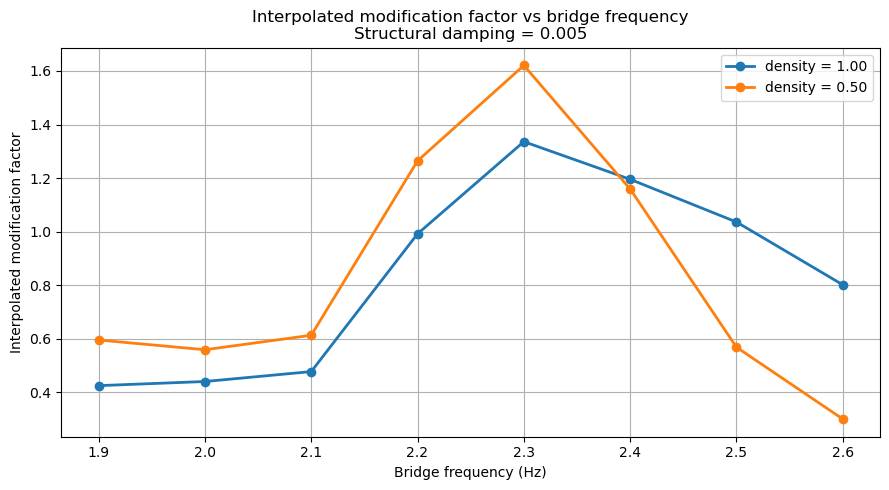

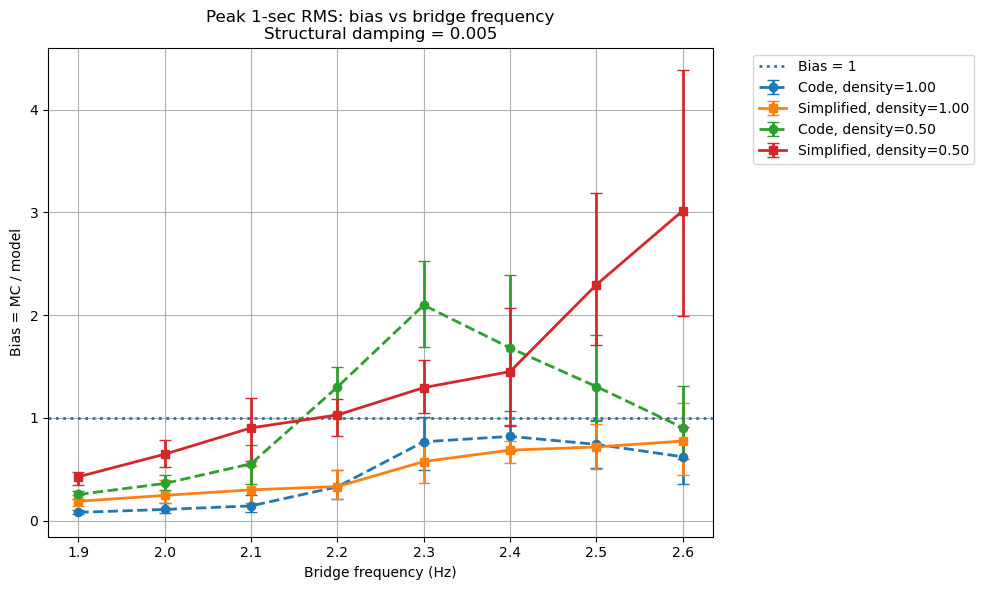

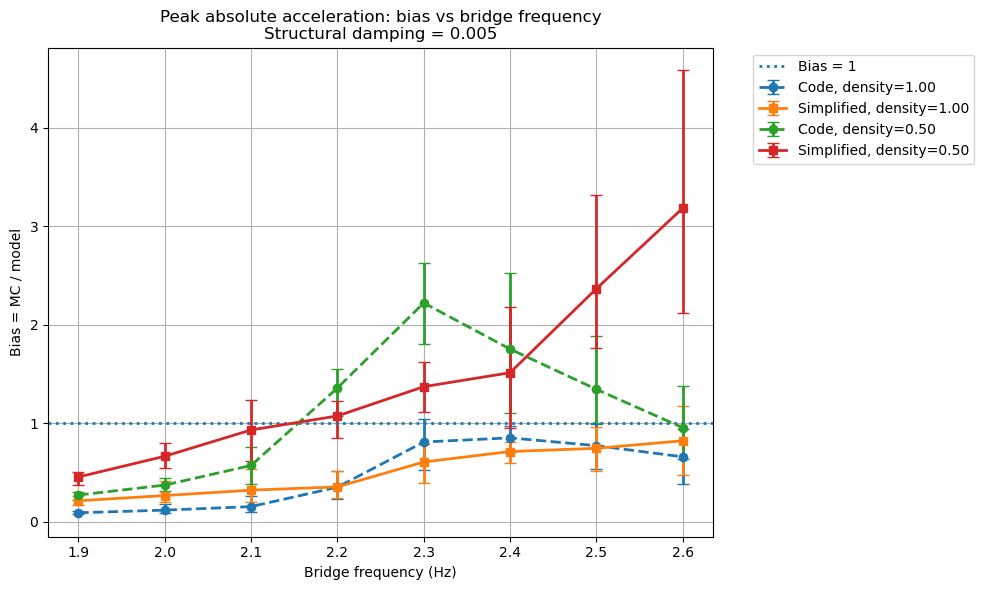

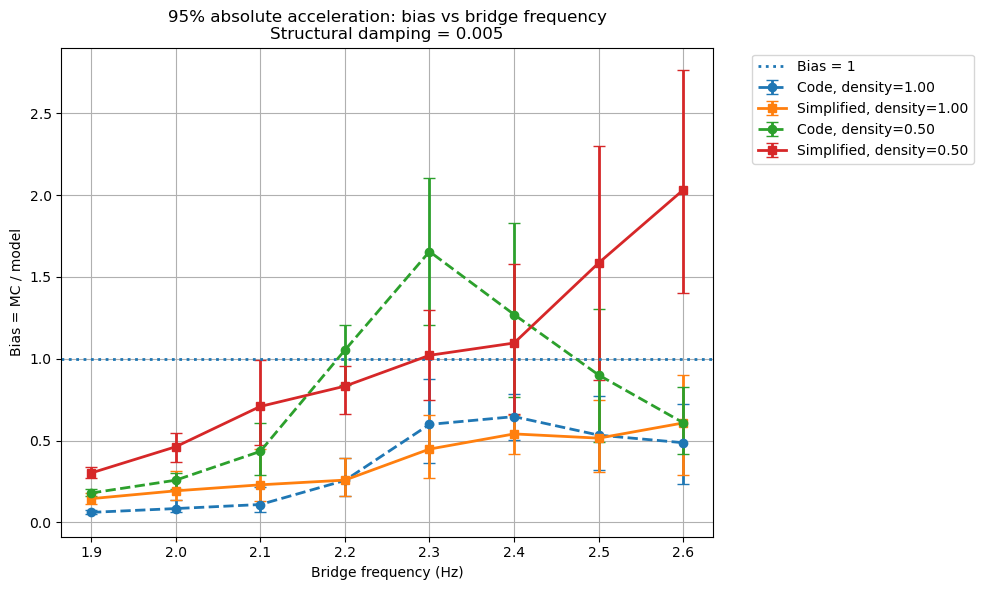

In [41]:
# ==================================================
# MULTI-FREQUENCY MC + CODE + SIMPLIFIED SUMMARY
# Outputs:
#   1. interpolated modification factor vs frequency
#   2. bias error bars for 3 response measures
# No time-history plots
# ==================================================

import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import torch
torch.set_num_threads(1)

import numpy as np
import matplotlib.pyplot as plt
import multiprocessing as mp
import pickle
import pandas as pd

from bias import run_simulation

from biascodefunction import (
    peak_rms_distribution,
    percentile_acc_distribution,
    peak_abs_acc_distribution,
    run_code_response_from_mc_inputs,
    interpolate_modification_factor_banded
)

# --------------------------------------------------
# USER SETTINGS
# --------------------------------------------------
NUM_SIMULATIONS = 24
NUM_PROCESSES = 12

hht = 0.01
steady_start_time = 10.0
linear_mass = 500.0

peddamp = 0.30
pedBodyF = 3.10

Length = 50.0
Width = 2.0

target_beamdamp = 0.005

bridge_frequencies_to_run = [1.9, 2.0, 2.1, 2.2, 2.3, 2.4, 2.5, 2.6]
densities_to_run = [1.0, 0.5]

eps = 1e-12

# New modification-factor database
FORCE_FACTOR_FILE = "new_modification_factor_results_2.pkl"

# Mass-ratio cap for interpolation database
MR_MIN_DATABASE = 0.0089
MR_MIN_USED = 0.0090
MR_MAX_DATABASE = 0.2954
MR_MAX_USED = 0.29


# --------------------------------------------------
# Helper: cap MC mass ratio inside interpolation range
# --------------------------------------------------
def cap_mass_ratio_for_interpolation(mc_mass_ratio):
    mc_mass_ratio = float(mc_mass_ratio)

    if mc_mass_ratio < MR_MIN_DATABASE:
        return MR_MIN_USED
    elif mc_mass_ratio > MR_MAX_DATABASE:
        return MR_MAX_USED
    else:
        return mc_mass_ratio


# --------------------------------------------------
# Load new modification-factor database
# --------------------------------------------------
with open(FORCE_FACTOR_FILE, "rb") as f:
    ff_data = pickle.load(f)

ff_results_all = ff_data["results_all"]
ff_densities = ff_data["densities"]
ff_damping_values = ff_data["damping_values"]
ff_pedBodyF = ff_data["pedBodyF"]

ff_bands_to_combine = list(ff_results_all.keys())

print("Loaded NEW modification-factor database.")
print("Available bands:", ff_bands_to_combine)
print("Available damping values:", ff_damping_values)
print("Available densities:", ff_densities)

# Safety check
test_band = ff_bands_to_combine[0]
test_damp = ff_damping_values[0]
test_bf = sorted(ff_results_all[test_band][test_damp].keys())[0]
test_density = ff_densities[0]
test_keys = ff_results_all[test_band][test_damp][test_bf][test_density].keys()

print("\nDatabase check")
print("--------------")
print("Test band:", test_band)
print("Test damping:", test_damp)
print("Test bridge frequency:", test_bf)
print("Test density:", test_density)
print("Available keys:", test_keys)

if "modification_factor" not in test_keys:
    raise KeyError("The database does not contain 'modification_factor'.")


# --------------------------------------------------
# Response measures
# --------------------------------------------------
measure_specs = {
    "Peak 1-sec RMS": {
        "mc_key": "peak_rms",
        "code_key": "peak_1sec_rms",
    },
    "Peak absolute acceleration": {
        "mc_key": "peak_abs",
        "code_key": "peak_abs_acc",
    },
    "95% absolute acceleration": {
        "mc_key": "p95_abs",
        "code_key": "p95_abs_acc",
    },
}


# ==================================================
# MAIN LOOP
# ==================================================
if __name__ == "__main__":

    try:
        mp.set_start_method("spawn")
    except RuntimeError:
        pass

    ctx = mp.get_context("spawn")
    rng = np.random.default_rng(12345)

    summary_rows = []

    with ctx.Pool(processes=NUM_PROCESSES) as pool:

        for target_bf in bridge_frequencies_to_run:

            print("\n" + "=" * 80)
            print(f"RUNNING BRIDGE FREQUENCY = {target_bf:.3f} Hz")
            print("=" * 80)

            BeamFreq = np.array([target_bf, 4.0 * target_bf])
            Beamdamp = np.array([target_beamdamp])

            for density in densities_to_run:

                print("\n" + "-" * 70)
                print(f"Running density = {density:.4f}")
                print("-" * 70)

                # --------------------------------------------------
                # Convert density to integer pedestrian counts
                # --------------------------------------------------
                total_peds_float = density * Length * Width
                total_peds_int = int(round(total_peds_float))
                total_peds_int = max(1, total_peds_int)

                Tocity = total_peds_int // 2
                Outcity = total_peds_int - Tocity

                actual_density = (Tocity + Outcity) / (Length * Width)

                print(f"Target density   = {density:.4f}")
                print(f"Actual density   = {actual_density:.4f}")
                print(f"Total peds       = {total_peds_int}")
                print(f"Tocity, Outcity  = {Tocity}, {Outcity}")

                # --------------------------------------------------
                # Run MC reference simulations
                # --------------------------------------------------
                seeds = rng.integers(0, 2**31 - 1, size=NUM_SIMULATIONS)

                args_list = [
                    (
                        int(seeds[i]),
                        peddamp,
                        pedBodyF,
                        BeamFreq,
                        Beamdamp,
                        Tocity,
                        Outcity,
                        Length,
                        Width
                    )
                    for i in range(NUM_SIMULATIONS)
                ]

                results = pool.map(run_simulation, args_list)

                # --------------------------------------------------
                # Extract MC acceleration histories and mass ratios
                # --------------------------------------------------
                accelerations = np.array([r[0] for r in results])
                mean_mass_ratios = np.array([r[1] for r in results])

                overall_mean_mass_ratio = np.mean(mean_mass_ratios)

                print(f"MC acceleration shape       = {accelerations.shape}")
                print(f"Mean modal mass ratio       = {overall_mean_mass_ratio:.6f}")

                # --------------------------------------------------
                # Remove initial transient
                # --------------------------------------------------
                steady_start_idx = int(round(steady_start_time / hht))

                if steady_start_idx >= accelerations.shape[1]:
                    raise ValueError("steady_start_time is longer than acceleration time history.")

                accelerations_ss = accelerations[:, steady_start_idx:]

                # --------------------------------------------------
                # MC response distributions
                # --------------------------------------------------
                rms_histories, peak_rms_values = peak_rms_distribution(
                    accelerations_ss,
                    dt=hht,
                    window_sec=1.0
                )

                peak_abs_values = peak_abs_acc_distribution(
                    accelerations_ss
                )

                p95_abs_values = percentile_acc_distribution(
                    accelerations_ss,
                    percentile=95,
                    use_abs=True
                )

                mc_values = {
                    "peak_rms": peak_rms_values,
                    "peak_abs": peak_abs_values,
                    "p95_abs": p95_abs_values,
                }

                # --------------------------------------------------
                # Original deterministic/code model
                # Includes modal mass modification when mass ratio > 5%
                # --------------------------------------------------
                t_end = accelerations.shape[1] * hht

                code_result, code_measures = run_code_response_from_mc_inputs(
                    Tocity=Tocity,
                    Outcity=Outcity,
                    Length=Length,
                    Width=Width,
                    BeamFreq=BeamFreq,
                    Beamdamp=Beamdamp,
                    linear_mass=linear_mass,
                    hht=hht,
                    t_end=t_end,
                    mean_mass_ratio=overall_mean_mass_ratio,
                    mass_ratio_limit=0.05,
                    steady_start_time=steady_start_time,
                    numbers=1,
                    modify_both_modes=False,
                    force_reduction_factor=1.0
                )

                # --------------------------------------------------
                # Interpolate modification factor
                # --------------------------------------------------
                target_mass_ratio_used = cap_mass_ratio_for_interpolation(
                    overall_mean_mass_ratio
                )

                x_factor, interp_details = interpolate_modification_factor_banded(
                    results_all=ff_results_all,
                    target_bf=target_bf,
                    target_beamdamp=0.02,
                    target_mass_ratio=target_mass_ratio_used,
                    damping_values=ff_damping_values,
                    densities=ff_densities,
                    bands_to_combine=ff_bands_to_combine,
                    factor_key="modification_factor"
                )

                force_reduction_factor_used = x_factor

                print("\nModification-factor interpolation")
                print("---------------------------------")
                print(f"Target bf                      = {target_bf:.6f}")
                print(f"Target damping                 = {target_beamdamp:.6f}")
                print(f"MC mean modal mass ratio        = {overall_mean_mass_ratio:.6f}")
                print(f"Mass ratio used in interpolation= {target_mass_ratio_used:.6f}")
                print(f"Interpolated modification factor= {x_factor:.6f}")

                # --------------------------------------------------
                # Simplified deterministic model
                # Includes BOTH:
                #   1. code modal mass modification
                #   2. interpolated force modification factor
                # --------------------------------------------------
                simplified_result, simplified_measures = run_code_response_from_mc_inputs(
                    Tocity=Tocity,
                    Outcity=Outcity,
                    Length=Length,
                    Width=Width,
                    BeamFreq=BeamFreq,
                    Beamdamp=Beamdamp,
                    linear_mass=linear_mass,
                    hht=hht,
                    t_end=t_end,

                    # keep modal mass modification active
                    mean_mass_ratio=overall_mean_mass_ratio,
                    mass_ratio_limit=0.05,

                    steady_start_time=steady_start_time,
                    numbers=1,
                    modify_both_modes=False,
                    force_reduction_factor=force_reduction_factor_used
                )

                # --------------------------------------------------
                # Bias distributions for all 3 measures
                # Bias = MC / deterministic model
                # --------------------------------------------------
                for measure_name, spec in measure_specs.items():

                    Y_ref = np.asarray(mc_values[spec["mc_key"]], dtype=float)
                    Y_ref = Y_ref[np.isfinite(Y_ref)]

                    code_val = code_measures[spec["code_key"]]
                    simp_val = simplified_measures[spec["code_key"]]

                    B_code = Y_ref / max(code_val, eps)
                    B_simp = Y_ref / max(simp_val, eps)

                    summary_rows.append({
                        "bridge_frequency": target_bf,
                        "target_beamdamp": target_beamdamp,
                        "target_density": density,
                        "actual_density": actual_density,
                        "total_peds": total_peds_int,
                        "Tocity": Tocity,
                        "Outcity": Outcity,

                        "mean_modal_mass_ratio": overall_mean_mass_ratio,
                        "mass_ratio_used_for_interpolation": target_mass_ratio_used,
                        "modification_factor": x_factor,

                        "measure": measure_name,

                        "mc_mean": np.mean(Y_ref),
                        "mc_p5": np.percentile(Y_ref, 5),
                        "mc_p50": np.percentile(Y_ref, 50),
                        "mc_p95": np.percentile(Y_ref, 95),

                        "code_prediction": code_val,
                        "simplified_prediction": simp_val,

                        "code_bias_mean": np.mean(B_code),
                        "code_bias_p5": np.percentile(B_code, 5),
                        "code_bias_p95": np.percentile(B_code, 95),

                        "simplified_bias_mean": np.mean(B_simp),
                        "simplified_bias_p5": np.percentile(B_simp, 5),
                        "simplified_bias_p95": np.percentile(B_simp, 95),
                    })

                    print(f"\n{measure_name}")
                    print(f"  MC mean              = {np.mean(Y_ref):.6f}")
                    print(f"  Code prediction      = {code_val:.6f}")
                    print(f"  Simplified prediction= {simp_val:.6f}")
                    print(f"  Code bias mean       = {np.mean(B_code):.6f}")
                    print(f"  Simplified bias mean = {np.mean(B_simp):.6f}")

    # ==================================================
    # SAVE SUMMARY
    # ==================================================
    summary_df = pd.DataFrame(summary_rows)

    summary_pkl = "multi_frequency_density_bias_summary.pkl"
    summary_csv = "multi_frequency_density_bias_summary.csv"

    with open(summary_pkl, "wb") as f:
        pickle.dump(summary_df, f, protocol=pickle.HIGHEST_PROTOCOL)

    summary_df.to_csv(summary_csv, index=False)

    print("\nSaved summary files:")
    print(summary_pkl)
    print(summary_csv)

    # ==================================================
    # PLOT 1: MODIFICATION FACTOR VS BRIDGE FREQUENCY
    # ==================================================
    plt.figure(figsize=(9, 5))

    # one modification factor per frequency-density pair
    factor_df = summary_df.drop_duplicates(
        subset=["bridge_frequency", "target_density"]
    )

    for density in densities_to_run:

        sub = factor_df[factor_df["target_density"] == density].copy()
        sub = sub.sort_values("bridge_frequency")

        plt.plot(
            sub["bridge_frequency"],
            sub["modification_factor"],
            marker="o",
            linewidth=2,
            label=f"density = {density:.2f}"
        )

    plt.xlabel("Bridge frequency (Hz)")
    plt.ylabel("Interpolated modification factor")
    plt.title(
        f"Interpolated modification factor vs bridge frequency\n"
        f"Structural damping = {target_beamdamp}"
    )
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ==================================================
    # PLOTS 2-4: ERROR BARS FOR EACH RESPONSE MEASURE
    # ==================================================
    for measure_name in measure_specs.keys():

        plt.figure(figsize=(10, 6))

        for density in densities_to_run:

            sub = summary_df[
                (summary_df["target_density"] == density) &
                (summary_df["measure"] == measure_name)
            ].copy()

            sub = sub.sort_values("bridge_frequency")

            x = sub["bridge_frequency"].values

            # -----------------------------
            # Original code bias
            # -----------------------------
            y_code = sub["code_bias_mean"].values
            y_code_p5 = sub["code_bias_p5"].values
            y_code_p95 = sub["code_bias_p95"].values

            yerr_code = np.vstack([
                y_code - y_code_p5,
                y_code_p95 - y_code
            ])

            plt.errorbar(
                x,
                y_code,
                yerr=yerr_code,
                marker="o",
                linestyle="--",
                linewidth=2,
                capsize=4,
                label=f"Code, density={density:.2f}"
            )

            # -----------------------------
            # Simplified model bias
            # -----------------------------
            y_simp = sub["simplified_bias_mean"].values
            y_simp_p5 = sub["simplified_bias_p5"].values
            y_simp_p95 = sub["simplified_bias_p95"].values

            yerr_simp = np.vstack([
                y_simp - y_simp_p5,
                y_simp_p95 - y_simp
            ])

            plt.errorbar(
                x,
                y_simp,
                yerr=yerr_simp,
                marker="s",
                linestyle="-",
                linewidth=2,
                capsize=4,
                label=f"Simplified, density={density:.2f}"
            )

        plt.axhline(
            1.0,
            linestyle=":",
            linewidth=2,
            label="Bias = 1"
        )

        plt.xlabel("Bridge frequency (Hz)")
        plt.ylabel("Bias = MC / model")
        plt.title(
            f"{measure_name}: bias vs bridge frequency\n"
            f"Structural damping = {target_beamdamp}"
        )
        plt.grid(True)
        plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.tight_layout()
        plt.show()


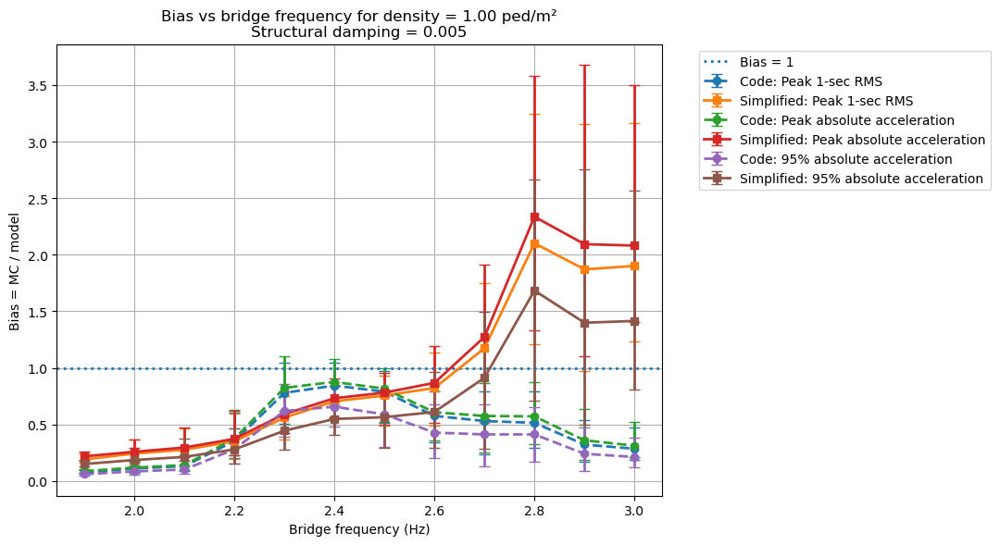

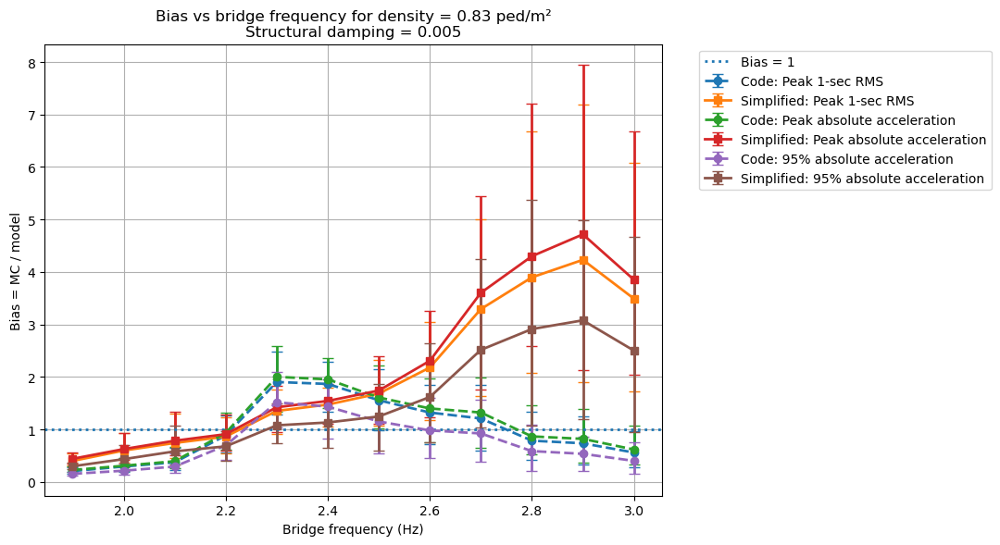

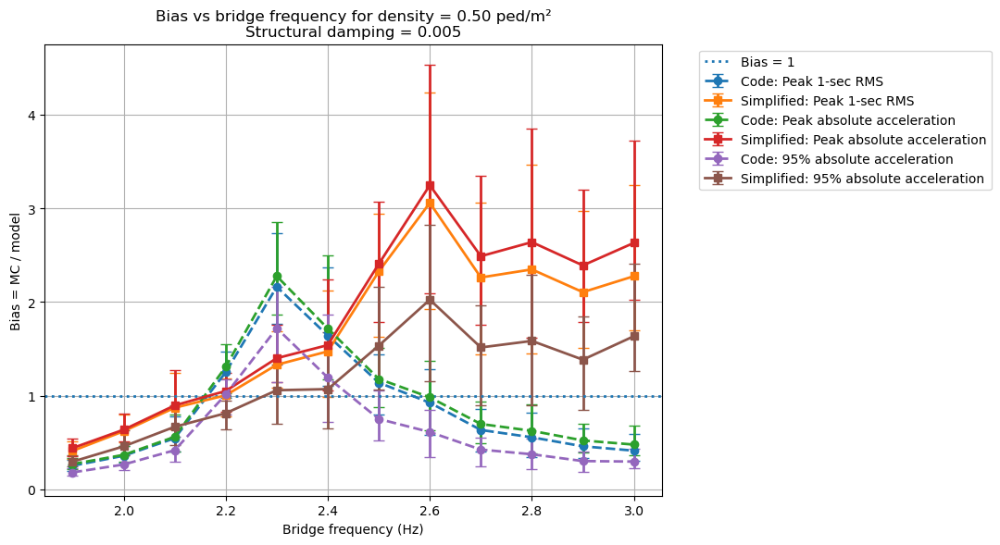

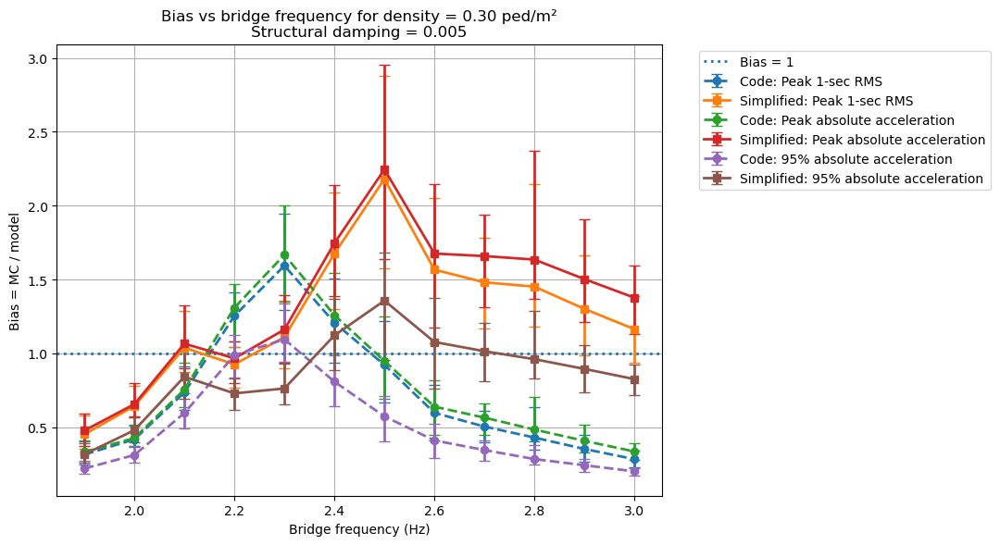

In [34]:
# ==================================================
# PLOTS: ONE BIAS PLOT PER DENSITY
# Each plot contains all response measures
# ==================================================

for density in densities_to_run:

    plt.figure(figsize=(11, 6))

    for measure_name in measure_specs.keys():

        sub = summary_df[
            (summary_df["target_density"] == density) &
            (summary_df["measure"] == measure_name)
        ].copy()

        sub = sub.sort_values("bridge_frequency")

        x = sub["bridge_frequency"].values

        # ==================================================
        # Original code bias
        # ==================================================
        y_code = sub["code_bias_mean"].values
        y_code_p5 = sub["code_bias_p5"].values
        y_code_p95 = sub["code_bias_p95"].values

        yerr_code = np.vstack([
            y_code - y_code_p5,
            y_code_p95 - y_code
        ])

        plt.errorbar(
            x,
            y_code,
            yerr=yerr_code,
            marker="o",
            linestyle="--",
            linewidth=2,
            capsize=4,
            label=f"Code: {measure_name}"
        )

        # ==================================================
        # Simplified model bias
        # ==================================================
        y_simp = sub["simplified_bias_mean"].values
        y_simp_p5 = sub["simplified_bias_p5"].values
        y_simp_p95 = sub["simplified_bias_p95"].values

        yerr_simp = np.vstack([
            y_simp - y_simp_p5,
            y_simp_p95 - y_simp
        ])

        plt.errorbar(
            x,
            y_simp,
            yerr=yerr_simp,
            marker="s",
            linestyle="-",
            linewidth=2,
            capsize=4,
            label=f"Simplified: {measure_name}"
        )

    plt.axhline(
        1.0,
        linestyle=":",
        linewidth=2,
        label="Bias = 1"
    )

    plt.xlabel("Bridge frequency (Hz)")
    plt.ylabel("Bias = MC / model")
    plt.title(
        f"Bias vs bridge frequency for density = {density:.2f} ped/m²\n"
        f"Structural damping = {target_beamdamp}"
    )

    plt.grid(True)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

Loaded NEW modification-factor database.
Available bands: ['1.25_to_4.60']
Available damping values: [0.005, 0.01, 0.015, 0.02, 0.025, 0.03]
Available densities: [0.0333, 0.1667, 0.3333, 0.5, 0.6667, 0.8333, 1.0]

Database check
--------------
Test band: 1.25_to_4.60
Test damping: 0.005
Test bridge frequency: 1.25
Test density: 0.0333
Available keys: dict_keys(['t', 'modalpedmass_i', 'modification_factor', 'frf_ratio', 'psi_ratio_valid', 'f_eff_peak', 'f0_peak'])

RUNNING BRIDGE FREQUENCY = 2.000 Hz

----------------------------------------------------------------------
Running density = 0.8333
----------------------------------------------------------------------
Target density   = 0.8333
Actual density   = 0.8300
Total peds       = 83
Tocity, Outcity  = 41, 42
MC acceleration shape       = (24, 10001)
Mean modal mass ratio       = 0.204927

Modification-factor interpolation
---------------------------------
Target bf                      = 2.000000
Target damping                 = 0.

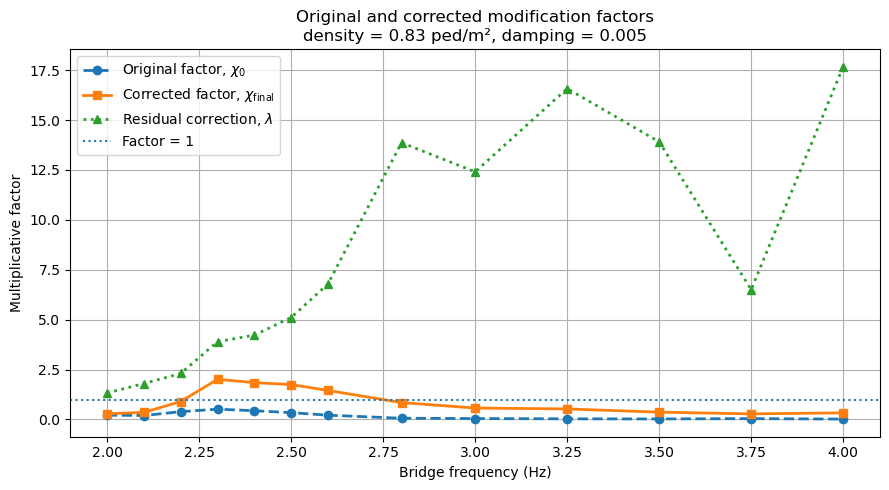

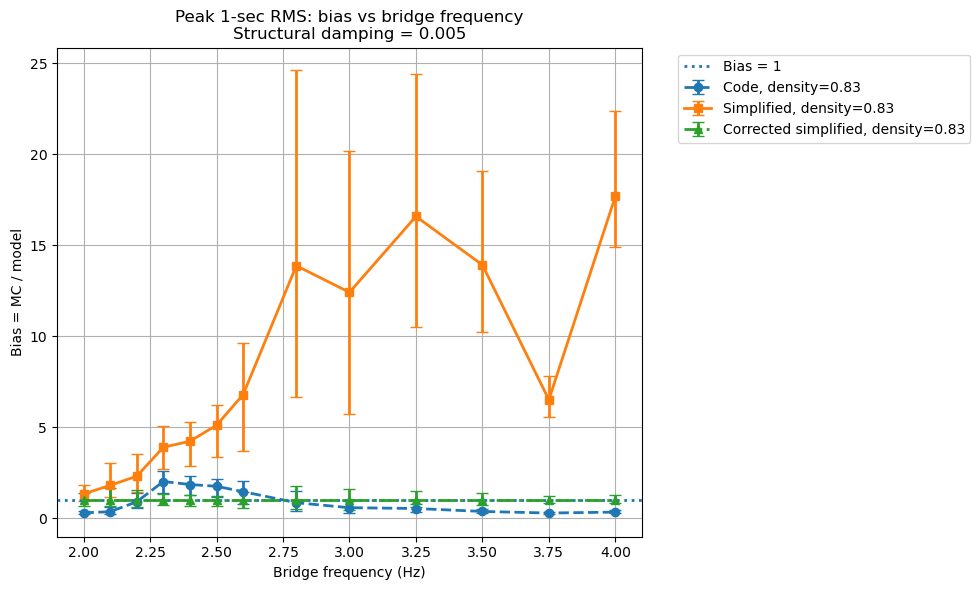

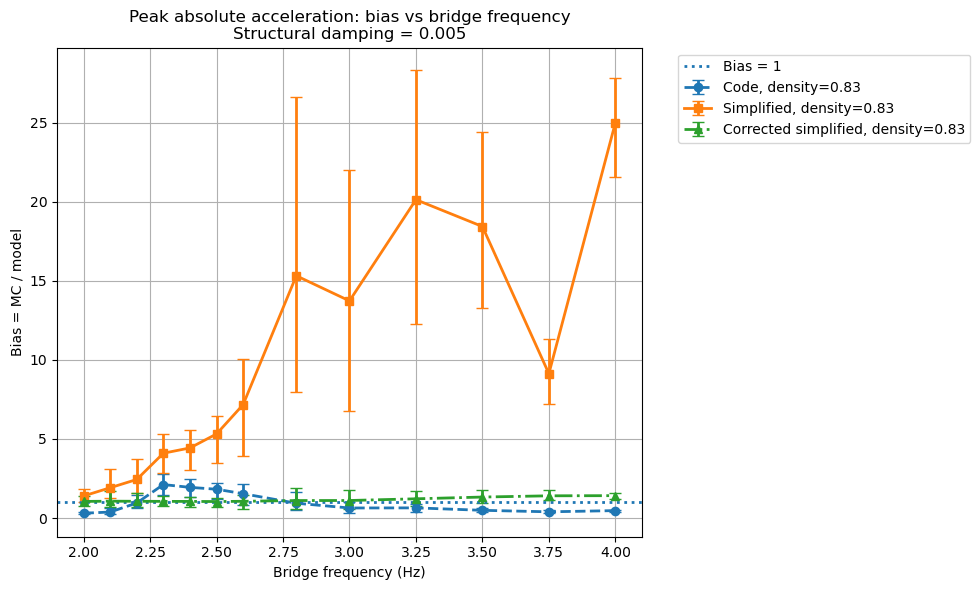

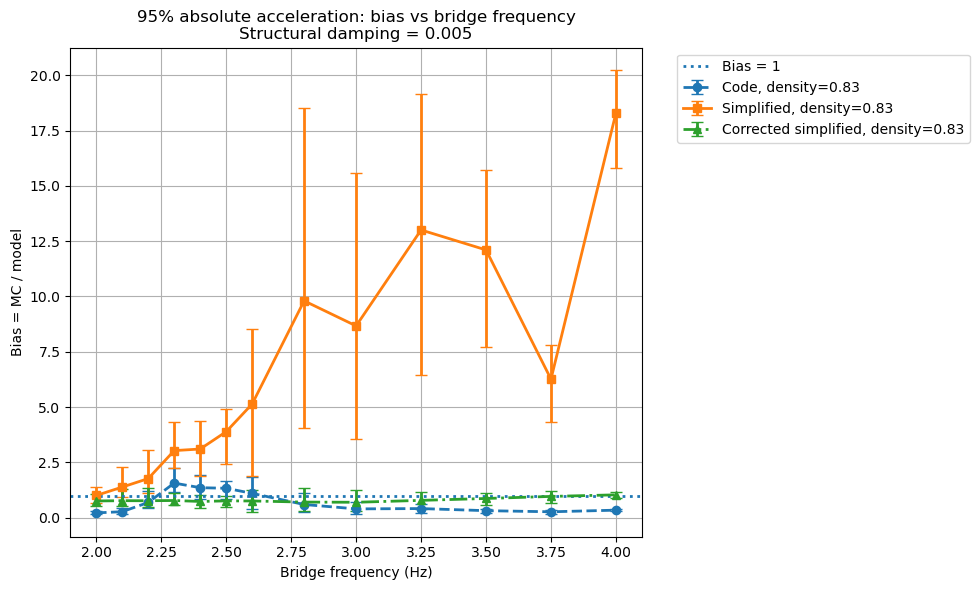

In [47]:
# ==================================================
# MULTI-FREQUENCY MC + CODE + SIMPLIFIED SUMMARY
# Outputs:
#   1. interpolated modification factor vs frequency
#   2. bias error bars for 3 response measures
# No time-history plots
# ==================================================

import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import torch
torch.set_num_threads(1)

import numpy as np
import matplotlib.pyplot as plt
import multiprocessing as mp
import pickle
import pandas as pd

from bias import run_simulation

from biascodefunction import (
    peak_rms_distribution,
    percentile_acc_distribution,
    peak_abs_acc_distribution,
    run_code_response_from_mc_inputs,
    interpolate_modification_factor_banded
)

# --------------------------------------------------
# USER SETTINGS
# --------------------------------------------------
NUM_SIMULATIONS = 24
NUM_PROCESSES = 12

hht = 0.01
steady_start_time = 10.0
linear_mass = 500.0

peddamp = 0.30
pedBodyF = 3.10

Length = 50.0
Width = 2.0

target_beamdamp = 0.005

bridge_frequencies_to_run = [2.0, 2.1, 2.2, 2.3, 2.4, 2.5, 2.6, 2.8, 3.0, 3.25, 3.5, 3.75, 4.0]
densities_to_run = [ 0.8333]

eps = 1e-12
# --------------------------------------------------
# Bias-correction settings
# --------------------------------------------------
CALIBRATION_MEASURE = "Peak 1-sec RMS"
CORRECTION_STAT = "mean"      # options: "mean", "median", "p95"
# New modification-factor database
FORCE_FACTOR_FILE = "new_modification_factor_results_2.pkl"

# Mass-ratio cap for interpolation database
MR_MIN_DATABASE = 0.0089
MR_MIN_USED = 0.0090
MR_MAX_DATABASE = 0.2954
MR_MAX_USED = 0.29


# --------------------------------------------------
# Helper: cap MC mass ratio inside interpolation range
# --------------------------------------------------
def cap_mass_ratio_for_interpolation(mc_mass_ratio):
    mc_mass_ratio = float(mc_mass_ratio)

    if mc_mass_ratio < MR_MIN_DATABASE:
        return MR_MIN_USED
    elif mc_mass_ratio > MR_MAX_DATABASE:
        return MR_MAX_USED
    else:
        return mc_mass_ratio


# --------------------------------------------------
# Load new modification-factor database
# --------------------------------------------------
with open(FORCE_FACTOR_FILE, "rb") as f:
    ff_data = pickle.load(f)

ff_results_all = ff_data["results_all"]
ff_densities = ff_data["densities"]
ff_damping_values = ff_data["damping_values"]
ff_pedBodyF = ff_data["pedBodyF"]

ff_bands_to_combine = list(ff_results_all.keys())

print("Loaded NEW modification-factor database.")
print("Available bands:", ff_bands_to_combine)
print("Available damping values:", ff_damping_values)
print("Available densities:", ff_densities)

# Safety check
test_band = ff_bands_to_combine[0]
test_damp = ff_damping_values[0]
test_bf = sorted(ff_results_all[test_band][test_damp].keys())[0]
test_density = ff_densities[0]
test_keys = ff_results_all[test_band][test_damp][test_bf][test_density].keys()

print("\nDatabase check")
print("--------------")
print("Test band:", test_band)
print("Test damping:", test_damp)
print("Test bridge frequency:", test_bf)
print("Test density:", test_density)
print("Available keys:", test_keys)

if "modification_factor" not in test_keys:
    raise KeyError("The database does not contain 'modification_factor'.")


# --------------------------------------------------
# Response measures
# --------------------------------------------------
measure_specs = {
    "Peak 1-sec RMS": {
        "mc_key": "peak_rms",
        "code_key": "peak_1sec_rms",
    },
    "Peak absolute acceleration": {
        "mc_key": "peak_abs",
        "code_key": "peak_abs_acc",
    },
    "95% absolute acceleration": {
        "mc_key": "p95_abs",
        "code_key": "p95_abs_acc",
    },
}


# ==================================================
# MAIN LOOP
# ==================================================
if __name__ == "__main__":

    try:
        mp.set_start_method("spawn")
    except RuntimeError:
        pass

    ctx = mp.get_context("spawn")
    rng = np.random.default_rng(12345)

    summary_rows = []

    with ctx.Pool(processes=NUM_PROCESSES) as pool:

        for target_bf in bridge_frequencies_to_run:

            print("\n" + "=" * 80)
            print(f"RUNNING BRIDGE FREQUENCY = {target_bf:.3f} Hz")
            print("=" * 80)

            BeamFreq = np.array([target_bf, 4.0 * target_bf])
            Beamdamp = np.array([target_beamdamp])

            for density in densities_to_run:

                print("\n" + "-" * 70)
                print(f"Running density = {density:.4f}")
                print("-" * 70)

                # --------------------------------------------------
                # Convert density to integer pedestrian counts
                # --------------------------------------------------
                total_peds_float = density * Length * Width
                total_peds_int = int(round(total_peds_float))
                total_peds_int = max(1, total_peds_int)

                Tocity = total_peds_int // 2
                Outcity = total_peds_int - Tocity

                actual_density = (Tocity + Outcity) / (Length * Width)

                print(f"Target density   = {density:.4f}")
                print(f"Actual density   = {actual_density:.4f}")
                print(f"Total peds       = {total_peds_int}")
                print(f"Tocity, Outcity  = {Tocity}, {Outcity}")

                # --------------------------------------------------
                # Run MC reference simulations
                # --------------------------------------------------
                seeds = rng.integers(0, 2**31 - 1, size=NUM_SIMULATIONS)

                args_list = [
                    (
                        int(seeds[i]),
                        peddamp,
                        pedBodyF,
                        BeamFreq,
                        Beamdamp,
                        Tocity,
                        Outcity,
                        Length,
                        Width
                    )
                    for i in range(NUM_SIMULATIONS)
                ]

                results = pool.map(run_simulation, args_list)

                # --------------------------------------------------
                # Extract MC acceleration histories and mass ratios
                # --------------------------------------------------
                accelerations = np.array([r[0] for r in results])
                mean_mass_ratios = np.array([r[1] for r in results])

                overall_mean_mass_ratio = np.mean(mean_mass_ratios)

                print(f"MC acceleration shape       = {accelerations.shape}")
                print(f"Mean modal mass ratio       = {overall_mean_mass_ratio:.6f}")

                # --------------------------------------------------
                # Remove initial transient
                # --------------------------------------------------
                steady_start_idx = int(round(steady_start_time / hht))

                if steady_start_idx >= accelerations.shape[1]:
                    raise ValueError("steady_start_time is longer than acceleration time history.")

                accelerations_ss = accelerations[:, steady_start_idx:]

                # --------------------------------------------------
                # MC response distributions
                # --------------------------------------------------
                rms_histories, peak_rms_values = peak_rms_distribution(
                    accelerations_ss,
                    dt=hht,
                    window_sec=1.0
                )

                peak_abs_values = peak_abs_acc_distribution(
                    accelerations_ss
                )

                p95_abs_values = percentile_acc_distribution(
                    accelerations_ss,
                    percentile=95,
                    use_abs=True
                )

                mc_values = {
                    "peak_rms": peak_rms_values,
                    "peak_abs": peak_abs_values,
                    "p95_abs": p95_abs_values,
                }

                # --------------------------------------------------
                # Original deterministic/code model
                # Includes modal mass modification when mass ratio > 5%
                # --------------------------------------------------
                t_end = accelerations.shape[1] * hht

                code_result, code_measures = run_code_response_from_mc_inputs(
                    Tocity=Tocity,
                    Outcity=Outcity,
                    Length=Length,
                    Width=Width,
                    BeamFreq=BeamFreq,
                    Beamdamp=Beamdamp,
                    linear_mass=linear_mass,
                    hht=hht,
                    t_end=t_end,
                    mean_mass_ratio=overall_mean_mass_ratio,
                    mass_ratio_limit=0.05,
                    steady_start_time=steady_start_time,
                    numbers=1,
                    modify_both_modes=False,
                    force_reduction_factor=1.0
                )

                # --------------------------------------------------
                # Interpolate modification factor
                # --------------------------------------------------
                target_mass_ratio_used = cap_mass_ratio_for_interpolation(
                    overall_mean_mass_ratio
                )

                x_factor, interp_details = interpolate_modification_factor_banded(
                    results_all=ff_results_all,
                    target_bf=target_bf,
                    target_beamdamp=target_beamdamp,
                    target_mass_ratio=target_mass_ratio_used,
                    damping_values=ff_damping_values,
                    densities=ff_densities,
                    bands_to_combine=ff_bands_to_combine,
                    factor_key="modification_factor"
                )

                force_reduction_factor_used = x_factor

                print("\nModification-factor interpolation")
                print("---------------------------------")
                print(f"Target bf                      = {target_bf:.6f}")
                print(f"Target damping                 = {target_beamdamp:.6f}")
                print(f"MC mean modal mass ratio        = {overall_mean_mass_ratio:.6f}")
                print(f"Mass ratio used in interpolation= {target_mass_ratio_used:.6f}")
                print(f"Interpolated modification factor= {x_factor:.6f}")

                # --------------------------------------------------
                # Simplified deterministic model using initial factor chi_0
                # --------------------------------------------------
                simplified_result, simplified_measures = run_code_response_from_mc_inputs(
                    Tocity=Tocity,
                    Outcity=Outcity,
                    Length=Length,
                    Width=Width,
                    BeamFreq=BeamFreq,
                    Beamdamp=Beamdamp,
                    linear_mass=linear_mass,
                    hht=hht,
                    t_end=t_end,

                    # keep modal mass modification active
                    mean_mass_ratio=overall_mean_mass_ratio,
                    mass_ratio_limit=0.05,

                    steady_start_time=steady_start_time,
                    numbers=1,
                    modify_both_modes=False,
                    force_reduction_factor=force_reduction_factor_used
                )

                # --------------------------------------------------
                # Residual correction factor
                # This corrects the remaining bias after using chi_0
                # --------------------------------------------------
                cal_spec = measure_specs[CALIBRATION_MEASURE]

                Y_cal = np.asarray(mc_values[cal_spec["mc_key"]], dtype=float)
                Y_cal = Y_cal[np.isfinite(Y_cal)]

                simp_val_cal = simplified_measures[cal_spec["code_key"]]

                B_simp_cal = Y_cal / max(simp_val_cal, eps)

                if CORRECTION_STAT == "mean":
                    residual_correction_factor = np.mean(B_simp_cal)

                elif CORRECTION_STAT == "median":
                    residual_correction_factor = np.percentile(B_simp_cal, 50)

                elif CORRECTION_STAT == "p95":
                    residual_correction_factor = np.percentile(B_simp_cal, 95)

                else:
                    raise ValueError("CORRECTION_STAT must be 'mean', 'median', or 'p95'.")

                final_modification_factor = x_factor * residual_correction_factor

                print("\nResidual bias correction")
                print("------------------------")
                print(f"Calibration measure          = {CALIBRATION_MEASURE}")
                print(f"Correction statistic         = {CORRECTION_STAT}")
                print(f"Initial factor chi_0          = {x_factor:.6f}")
                print(f"Residual correction lambda    = {residual_correction_factor:.6f}")
                print(f"Final factor chi_final        = {final_modification_factor:.6f}")


                # --------------------------------------------------
                # Corrected simplified deterministic model
                # Uses chi_final = chi_0 * lambda
                # --------------------------------------------------
                corrected_result, corrected_measures = run_code_response_from_mc_inputs(
                    Tocity=Tocity,
                    Outcity=Outcity,
                    Length=Length,
                    Width=Width,
                    BeamFreq=BeamFreq,
                    Beamdamp=Beamdamp,
                    linear_mass=linear_mass,
                    hht=hht,
                    t_end=t_end,

                    # keep modal mass modification active
                    mean_mass_ratio=overall_mean_mass_ratio,
                    mass_ratio_limit=0.05,

                    steady_start_time=steady_start_time,
                    numbers=1,
                    modify_both_modes=False,
                    force_reduction_factor=final_modification_factor
                )


                # --------------------------------------------------
                # Bias distributions for all 3 measures
                # Bias = MC / deterministic model
                # --------------------------------------------------
                for measure_name, spec in measure_specs.items():

                    Y_ref = np.asarray(mc_values[spec["mc_key"]], dtype=float)
                    Y_ref = Y_ref[np.isfinite(Y_ref)]

                    code_val = code_measures[spec["code_key"]]
                    simp_val = simplified_measures[spec["code_key"]]
                    corr_val = corrected_measures[spec["code_key"]]

                    B_code = Y_ref / max(code_val, eps)
                    B_simp = Y_ref / max(simp_val, eps)
                    B_corr = Y_ref / max(corr_val, eps)

                    summary_rows.append({
                        "bridge_frequency": target_bf,
                        "target_beamdamp": target_beamdamp,
                        "target_density": density,
                        "actual_density": actual_density,
                        "total_peds": total_peds_int,
                        "Tocity": Tocity,
                        "Outcity": Outcity,

                        "mean_modal_mass_ratio": overall_mean_mass_ratio,
                        "mass_ratio_used_for_interpolation": target_mass_ratio_used,

                        # factors
                        "modification_factor": x_factor,
                        "initial_modification_factor": x_factor,
                        "residual_correction_factor": residual_correction_factor,
                        "final_modification_factor": final_modification_factor,
                        "calibration_measure": CALIBRATION_MEASURE,
                        "correction_stat": CORRECTION_STAT,

                        "measure": measure_name,

                        # MC response statistics
                        "mc_mean": np.mean(Y_ref),
                        "mc_p5": np.percentile(Y_ref, 5),
                        "mc_p50": np.percentile(Y_ref, 50),
                        "mc_p95": np.percentile(Y_ref, 95),

                        # deterministic predictions
                        "code_prediction": code_val,
                        "simplified_prediction": simp_val,
                        "corrected_prediction": corr_val,

                        # original code bias
                        "code_bias_mean": np.mean(B_code),
                        "code_bias_p5": np.percentile(B_code, 5),
                        "code_bias_p50": np.percentile(B_code, 50),
                        "code_bias_p95": np.percentile(B_code, 95),

                        # first simplified bias using chi_0
                        "simplified_bias_mean": np.mean(B_simp),
                        "simplified_bias_p5": np.percentile(B_simp, 5),
                        "simplified_bias_p50": np.percentile(B_simp, 50),
                        "simplified_bias_p95": np.percentile(B_simp, 95),

                        # corrected simplified bias using chi_final
                        "corrected_bias_mean": np.mean(B_corr),
                        "corrected_bias_p5": np.percentile(B_corr, 5),
                        "corrected_bias_p50": np.percentile(B_corr, 50),
                        "corrected_bias_p95": np.percentile(B_corr, 95),
                    })

                    print(f"\n{measure_name}")
                    print(f"  MC mean                    = {np.mean(Y_ref):.6f}")
                    print(f"  Code prediction            = {code_val:.6f}")
                    print(f"  Simplified prediction      = {simp_val:.6f}")
                    print(f"  Corrected prediction       = {corr_val:.6f}")

                    print(f"  Code mean bias             = {np.mean(B_code):.6f}")
                    print(f"  Simplified mean bias       = {np.mean(B_simp):.6f}")
                    print(f"  Corrected simplified bias  = {np.mean(B_corr):.6f}")
    # ==================================================
    # SAVE SUMMARY
    # ==================================================
    summary_df = pd.DataFrame(summary_rows)

    summary_pkl = "multi_frequency_density_bias_summary.pkl"
    summary_csv = "multi_frequency_density_bias_summary.csv"

    with open(summary_pkl, "wb") as f:
        pickle.dump(summary_df, f, protocol=pickle.HIGHEST_PROTOCOL)

    summary_df.to_csv(summary_csv, index=False)

    print("\nSaved summary files:")
    print(summary_pkl)
    print(summary_csv)

    # ==================================================
# PLOT 1: ORIGINAL vs CORRECTED MODIFICATION FACTOR
# ==================================================

factor_df = summary_df.drop_duplicates(
    subset=["bridge_frequency", "target_density"]
).copy()

for density in densities_to_run:

    sub = factor_df[factor_df["target_density"] == density].copy()
    sub = sub.sort_values("bridge_frequency")

    plt.figure(figsize=(9, 5))

    plt.plot(
        sub["bridge_frequency"],
        sub["initial_modification_factor"],
        marker="o",
        linestyle="--",
        linewidth=2,
        label=r"Original factor, $\chi_0$"
    )

    plt.plot(
        sub["bridge_frequency"],
        sub["final_modification_factor"],
        marker="s",
        linestyle="-",
        linewidth=2,
        label=r"Corrected factor, $\chi_{\mathrm{final}}$"
    )

    plt.plot(
        sub["bridge_frequency"],
        sub["residual_correction_factor"],
        marker="^",
        linestyle=":",
        linewidth=2,
        label=r"Residual correction, $\lambda$"
    )

    plt.axhline(
        1.0,
        linestyle=":",
        linewidth=1.5,
        label="Factor = 1"
    )

    plt.xlabel("Bridge frequency (Hz)")
    plt.ylabel("Multiplicative factor")
    plt.title(
        f"Original and corrected modification factors\n"
        f"density = {density:.2f} ped/m², damping = {target_beamdamp}"
    )

    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ==================================================
# PLOTS 2-4: ERROR BARS FOR EACH RESPONSE MEASURE
# One plot per vibration measure
# ==================================================

for measure_name in measure_specs.keys():

    plt.figure(figsize=(10, 6))

    for density in densities_to_run:

        sub = summary_df[
            (summary_df["target_density"] == density) &
            (summary_df["measure"] == measure_name)
        ].copy()

        sub = sub.sort_values("bridge_frequency")

        x = sub["bridge_frequency"].values

        # -----------------------------
        # Original code bias
        # -----------------------------
        y_code = sub["code_bias_mean"].values
        y_code_p5 = sub["code_bias_p5"].values
        y_code_p95 = sub["code_bias_p95"].values

        yerr_code = np.vstack([
            y_code - y_code_p5,
            y_code_p95 - y_code
        ])

        plt.errorbar(
            x,
            y_code,
            yerr=yerr_code,
            marker="o",
            linestyle="--",
            linewidth=2,
            capsize=4,
            label=f"Code, density={density:.2f}"
        )

        # -----------------------------
        # Simplified model bias
        # -----------------------------
        y_simp = sub["simplified_bias_mean"].values
        y_simp_p5 = sub["simplified_bias_p5"].values
        y_simp_p95 = sub["simplified_bias_p95"].values

        yerr_simp = np.vstack([
            y_simp - y_simp_p5,
            y_simp_p95 - y_simp
        ])

        plt.errorbar(
            x,
            y_simp,
            yerr=yerr_simp,
            marker="s",
            linestyle="-",
            linewidth=2,
            capsize=4,
            label=f"Simplified, density={density:.2f}"
        )

        # -----------------------------
        # Corrected simplified model bias
        # -----------------------------
        y_corr = sub["corrected_bias_mean"].values
        y_corr_p5 = sub["corrected_bias_p5"].values
        y_corr_p95 = sub["corrected_bias_p95"].values

        yerr_corr = np.vstack([
            y_corr - y_corr_p5,
            y_corr_p95 - y_corr
        ])

        plt.errorbar(
            x,
            y_corr,
            yerr=yerr_corr,
            marker="^",
            linestyle="-.",
            linewidth=2,
            capsize=4,
            label=f"Corrected simplified, density={density:.2f}"
        )

    plt.axhline(
        1.0,
        linestyle=":",
        linewidth=2,
        label="Bias = 1"
    )

    plt.xlabel("Bridge frequency (Hz)")
    plt.ylabel("Bias = MC / model")
    plt.title(
        f"{measure_name}: bias vs bridge frequency\n"
        f"Structural damping = {target_beamdamp}"
    )

    plt.grid(True)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

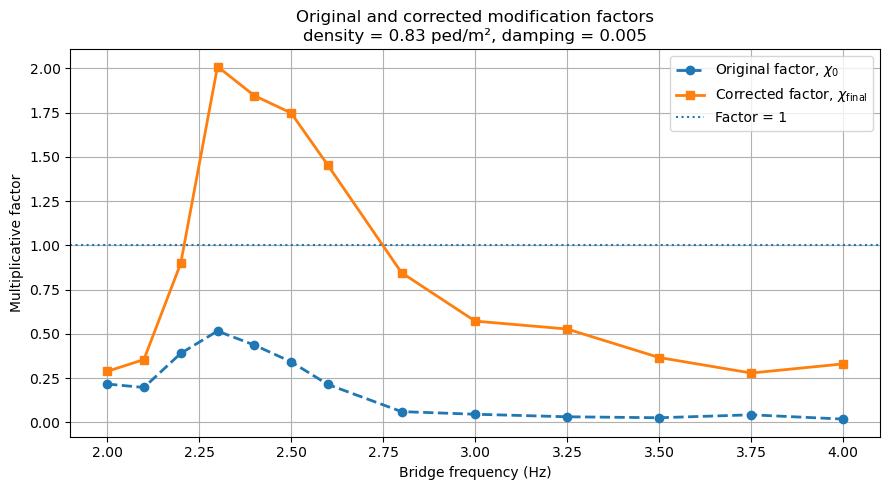

In [49]:
# ==================================================
# PLOT 1: ORIGINAL vs CORRECTED MODIFICATION FACTOR
# ==================================================

factor_df = summary_df.drop_duplicates(
    subset=["bridge_frequency", "target_density"]
).copy()

for density in densities_to_run:

    sub = factor_df[factor_df["target_density"] == density].copy()
    sub = sub.sort_values("bridge_frequency")

    plt.figure(figsize=(9, 5))

    plt.plot(
        sub["bridge_frequency"],
        sub["initial_modification_factor"],
        marker="o",
        linestyle="--",
        linewidth=2,
        label=r"Original factor, $\chi_0$"
    )

    plt.plot(
        sub["bridge_frequency"],
        sub["final_modification_factor"],
        marker="s",
        linestyle="-",
        linewidth=2,
        label=r"Corrected factor, $\chi_{\mathrm{final}}$"
    )

    plt.axhline(
        1.0,
        linestyle=":",
        linewidth=1.5,
        label="Factor = 1"
    )

    plt.xlabel("Bridge frequency (Hz)")
    plt.ylabel("Multiplicative factor")
    plt.title(
        f"Original and corrected modification factors\n"
        f"density = {density:.2f} ped/m², damping = {target_beamdamp}"
    )

    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


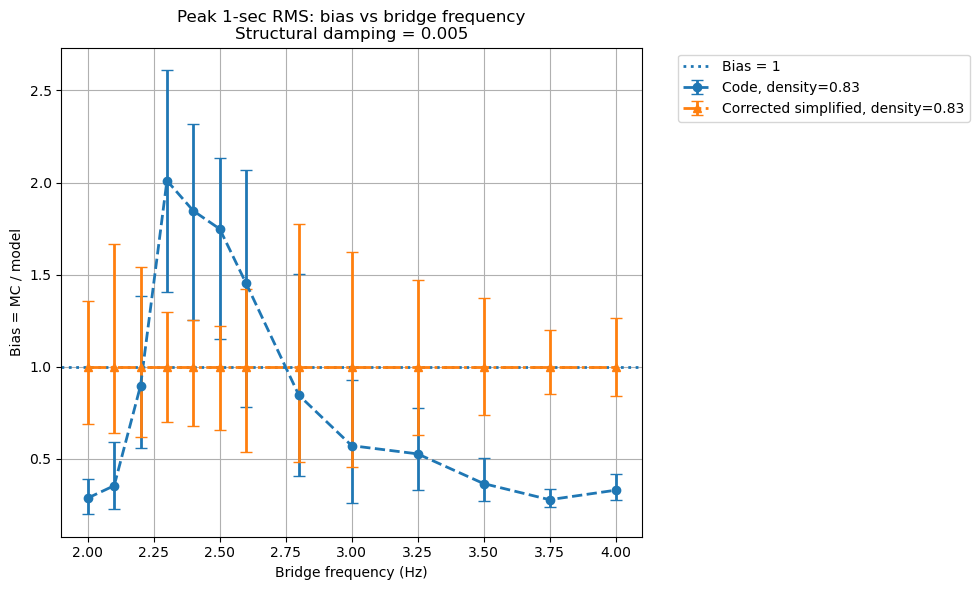

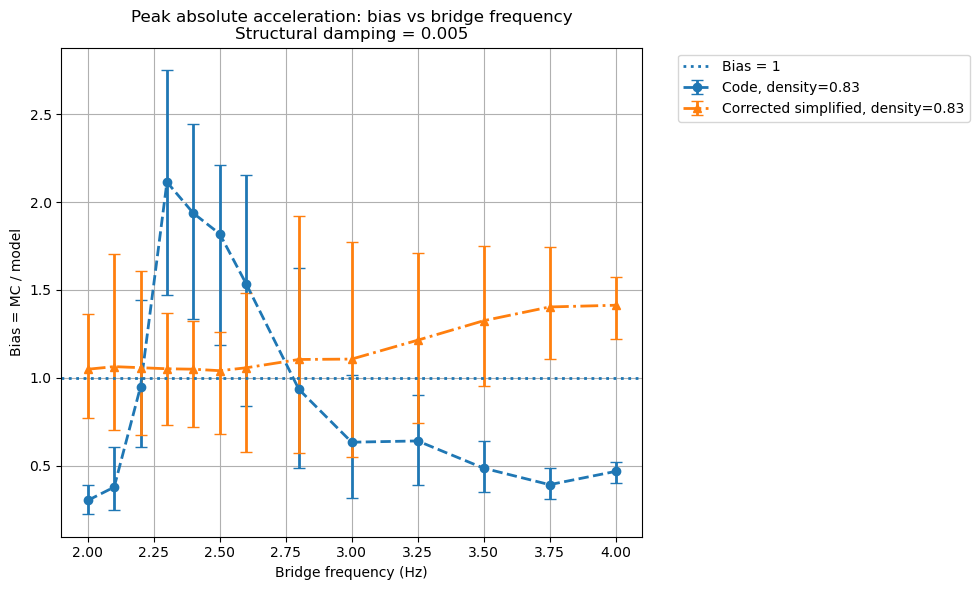

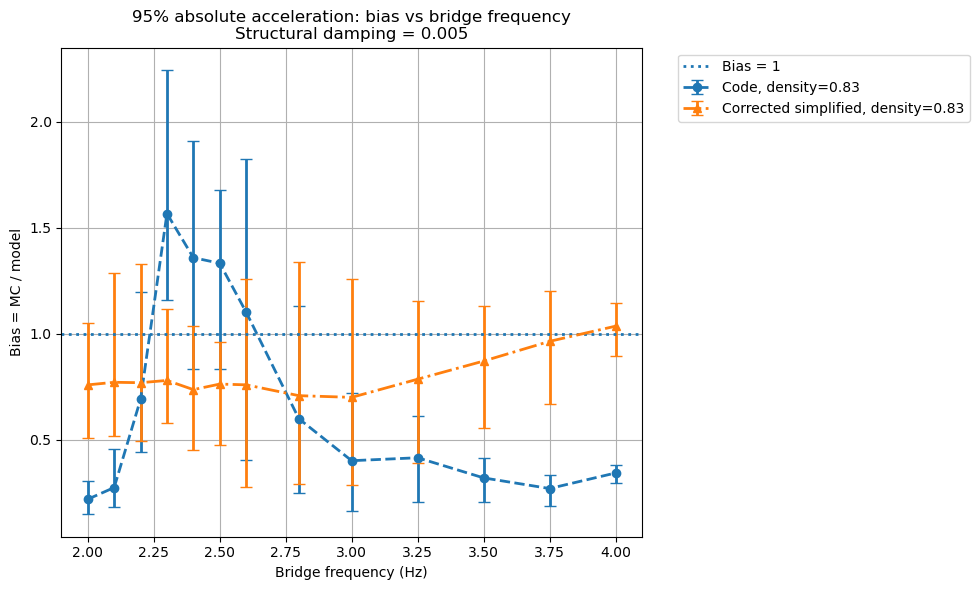

In [50]:
# ==================================================
# PLOTS 2-4: ERROR BARS FOR EACH RESPONSE MEASURE
# One plot per vibration measure
# ==================================================

for measure_name in measure_specs.keys():

    plt.figure(figsize=(10, 6))

    for density in densities_to_run:

        sub = summary_df[
            (summary_df["target_density"] == density) &
            (summary_df["measure"] == measure_name)
        ].copy()

        sub = sub.sort_values("bridge_frequency")

        x = sub["bridge_frequency"].values

        # -----------------------------
        # Original code bias
        # -----------------------------
        y_code = sub["code_bias_mean"].values
        y_code_p5 = sub["code_bias_p5"].values
        y_code_p95 = sub["code_bias_p95"].values

        yerr_code = np.vstack([
            y_code - y_code_p5,
            y_code_p95 - y_code
        ])

        plt.errorbar(
            x,
            y_code,
            yerr=yerr_code,
            marker="o",
            linestyle="--",
            linewidth=2,
            capsize=4,
            label=f"Code, density={density:.2f}"
        )

        # -----------------------------
        # Corrected simplified model bias
        # -----------------------------
        y_corr = sub["corrected_bias_mean"].values
        y_corr_p5 = sub["corrected_bias_p5"].values
        y_corr_p95 = sub["corrected_bias_p95"].values

        yerr_corr = np.vstack([
            y_corr - y_corr_p5,
            y_corr_p95 - y_corr
        ])

        plt.errorbar(
            x,
            y_corr,
            yerr=yerr_corr,
            marker="^",
            linestyle="-.",
            linewidth=2,
            capsize=4,
            label=f"Corrected simplified, density={density:.2f}"
        )

    plt.axhline(
        1.0,
        linestyle=":",
        linewidth=2,
        label="Bias = 1"
    )

    plt.xlabel("Bridge frequency (Hz)")
    plt.ylabel("Bias = MC / model")
    plt.title(
        f"{measure_name}: bias vs bridge frequency\n"
        f"Structural damping = {target_beamdamp}"
    )

    plt.grid(True)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

In [ ]:
# ==================================================
# MULTI-FREQUENCY + MULTI-DAMPING MC + CODE + CORRECTED SIMPLIFIED SUMMARY
# Outputs:
#   1. original vs corrected modification factor plots
#   2. bias error bars for 3 response measures
# ==================================================

import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import torch
torch.set_num_threads(1)

import numpy as np
import matplotlib.pyplot as plt
import multiprocessing as mp
import pickle
import pandas as pd

from bias import run_simulation

from biascodefunction import (
    peak_rms_distribution,
    percentile_acc_distribution,
    peak_abs_acc_distribution,
    run_code_response_from_mc_inputs,
    interpolate_modification_factor_banded
)


# --------------------------------------------------
# USER SETTINGS
# --------------------------------------------------
NUM_SIMULATIONS = 24
NUM_PROCESSES = 12

hht = 0.01
steady_start_time = 10.0
linear_mass = 500.0

peddamp = 0.30
pedBodyF = 3.10

Length = 50.0
Width = 2.0

# Multiple damping ratios
target_beamdamp_values = [0.005]

bridge_frequencies_to_run = [
    2.0, 2.1, 2.2, 2.3, 2.4, 2.5, 2.6, 2.7,
    2.8, 2.9, 3.0, 3.25, 3.5, 3.75, 4.0,
    4.25, 4.5, 4.6
]

densities_to_run = [0.1667]

eps = 1e-12

# --------------------------------------------------
# Bias-correction settings
# --------------------------------------------------
CALIBRATION_MEASURE = "Peak absolute acceleration"
CORRECTION_STAT = "mean"      # options: "mean", "median", "p95"

# --------------------------------------------------
# Modification-factor database
# --------------------------------------------------
FORCE_FACTOR_FILE = "New_modification_factor_results_2.pkl"

# Mass-ratio cap for interpolation database
MR_MIN_DATABASE = 0.0089
MR_MIN_USED = 0.0090
MR_MAX_DATABASE = 0.2954
MR_MAX_USED = 0.29


# --------------------------------------------------
# Helper: cap MC mass ratio inside interpolation range
# --------------------------------------------------
def cap_mass_ratio_for_interpolation(mc_mass_ratio):
    mc_mass_ratio = float(mc_mass_ratio)

    if mc_mass_ratio < MR_MIN_DATABASE:
        return MR_MIN_USED
    elif mc_mass_ratio > MR_MAX_DATABASE:
        return MR_MAX_USED
    else:
        return mc_mass_ratio


# --------------------------------------------------
# Response measures
# --------------------------------------------------
measure_specs = {
    "Peak 1-sec RMS": {
        "mc_key": "peak_rms",
        "code_key": "peak_1sec_rms",
    },
    "Peak absolute acceleration": {
        "mc_key": "peak_abs",
        "code_key": "peak_abs_acc",
    },
    "95% absolute acceleration": {
        "mc_key": "p95_abs",
        "code_key": "p95_abs_acc",
    },
}


# ==================================================
# MAIN LOOP
# ==================================================
if __name__ == "__main__":

    try:
        mp.set_start_method("spawn")
    except RuntimeError:
        pass

    # --------------------------------------------------
    # Load modification-factor database inside main block
    # --------------------------------------------------
    with open(FORCE_FACTOR_FILE, "rb") as f:
        ff_data = pickle.load(f)

    ff_results_all = ff_data["results_all"]
    ff_densities = ff_data["densities"]
    ff_damping_values = ff_data["damping_values"]
    ff_pedBodyF = ff_data["pedBodyF"]

    ff_bands_to_combine = list(ff_results_all.keys())

    print("Loaded NEW modification-factor database.")
    print("Available bands:", ff_bands_to_combine)
    print("Available damping values:", ff_damping_values)
    print("Available densities:", ff_densities)

    # Optional safety check
    test_band = ff_bands_to_combine[0]
    test_damp = ff_damping_values[0]
    test_bf = sorted(ff_results_all[test_band][test_damp].keys())[0]
    test_density = ff_densities[0]
    test_keys = ff_results_all[test_band][test_damp][test_bf][test_density].keys()

    print("\nDatabase check")
    print("--------------")
    print("Test band:", test_band)
    print("Test damping:", test_damp)
    print("Test bridge frequency:", test_bf)
    print("Test density:", test_density)
    print("Available keys:", test_keys)

    if "modification_factor" not in test_keys:
        raise KeyError("The database does not contain 'modification_factor'.")

    ctx = mp.get_context("spawn")
    rng = np.random.default_rng(12345)

    summary_rows = []

    with ctx.Pool(processes=NUM_PROCESSES) as pool:

        for target_beamdamp in target_beamdamp_values:

            print("\n" + "#" * 90)
            print(f"RUNNING STRUCTURAL DAMPING = {target_beamdamp:.4f}")
            print("#" * 90)

            for target_bf in bridge_frequencies_to_run:

                print("\n" + "=" * 80)
                print(f"RUNNING BRIDGE FREQUENCY = {target_bf:.3f} Hz")
                print("=" * 80)

                BeamFreq = np.array([target_bf, 4.0 * target_bf])
                Beamdamp = np.array([target_beamdamp])

                for density in densities_to_run:

                    print("\n" + "-" * 70)
                    print(f"Running density = {density:.4f}")
                    print("-" * 70)

                    # --------------------------------------------------
                    # Convert density to integer pedestrian counts
                    # --------------------------------------------------
                    total_peds_float = density * Length * Width
                    total_peds_int = int(round(total_peds_float))
                    total_peds_int = max(1, total_peds_int)

                    Tocity = total_peds_int // 2
                    Outcity = total_peds_int - Tocity

                    actual_density = (Tocity + Outcity) / (Length * Width)

                    print(f"Target density   = {density:.4f}")
                    print(f"Actual density   = {actual_density:.4f}")
                    print(f"Total peds       = {total_peds_int}")
                    print(f"Tocity, Outcity  = {Tocity}, {Outcity}")

                    # --------------------------------------------------
                    # Run MC reference simulations
                    # --------------------------------------------------
                    seeds = rng.integers(0, 2**31 - 1, size=NUM_SIMULATIONS)

                    args_list = [
                        (
                            int(seeds[i]),
                            peddamp,
                            pedBodyF,
                            BeamFreq,
                            Beamdamp,
                            Tocity,
                            Outcity,
                            Length,
                            Width
                        )
                        for i in range(NUM_SIMULATIONS)
                    ]

                    results = pool.map(run_simulation, args_list)

                    # --------------------------------------------------
                    # Extract MC acceleration histories and mass ratios
                    # --------------------------------------------------
                    accelerations = np.array([r[0] for r in results])
                    mean_mass_ratios = np.array([r[1] for r in results])

                    overall_mean_mass_ratio = np.mean(mean_mass_ratios)

                    print(f"MC acceleration shape       = {accelerations.shape}")
                    print(f"Mean modal mass ratio       = {overall_mean_mass_ratio:.6f}")

                    # --------------------------------------------------
                    # Remove initial transient
                    # --------------------------------------------------
                    steady_start_idx = int(round(steady_start_time / hht))

                    if steady_start_idx >= accelerations.shape[1]:
                        raise ValueError(
                            "steady_start_time is longer than acceleration time history."
                        )

                    accelerations_ss = accelerations[:, steady_start_idx:]

                    # --------------------------------------------------
                    # MC response distributions
                    # --------------------------------------------------
                    rms_histories, peak_rms_values = peak_rms_distribution(
                        accelerations_ss,
                        dt=hht,
                        window_sec=1.0
                    )

                    peak_abs_values = peak_abs_acc_distribution(
                        accelerations_ss
                    )

                    p95_abs_values = percentile_acc_distribution(
                        accelerations_ss,
                        percentile=95,
                        use_abs=True
                    )

                    mc_values = {
                        "peak_rms": peak_rms_values,
                        "peak_abs": peak_abs_values,
                        "p95_abs": p95_abs_values,
                    }

                    # --------------------------------------------------
                    # Original deterministic/code model
                    # --------------------------------------------------
                    t_end = accelerations.shape[1] * hht

                    code_result, code_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=1.0
                    )

                    # --------------------------------------------------
                    # Interpolate original modification factor chi_0
                    # --------------------------------------------------
                    target_mass_ratio_used = cap_mass_ratio_for_interpolation(
                        overall_mean_mass_ratio
                    )

                    x_factor, interp_details = interpolate_modification_factor_banded(
                        results_all=ff_results_all,
                        target_bf=target_bf,
                        target_beamdamp=target_beamdamp,
                        target_mass_ratio=target_mass_ratio_used,
                        damping_values=ff_damping_values,
                        densities=ff_densities,
                        bands_to_combine=ff_bands_to_combine,
                        factor_key="modification_factor"
                    )

                    force_reduction_factor_used = x_factor

                    print("\nModification-factor interpolation")
                    print("---------------------------------")
                    print(f"Target bf                        = {target_bf:.6f}")
                    print(f"Target damping                   = {target_beamdamp:.6f}")
                    print(f"MC mean modal mass ratio          = {overall_mean_mass_ratio:.6f}")
                    print(f"Mass ratio used in interpolation  = {target_mass_ratio_used:.6f}")
                    print(f"Interpolated factor chi_0         = {x_factor:.6f}")

                    # --------------------------------------------------
                    # Simplified deterministic model using chi_0
                    # --------------------------------------------------
                    simplified_result, simplified_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=force_reduction_factor_used
                    )

                    # --------------------------------------------------
                    # Residual correction factor lambda
                    # --------------------------------------------------
                    cal_spec = measure_specs[CALIBRATION_MEASURE]

                    Y_cal = np.asarray(mc_values[cal_spec["mc_key"]], dtype=float)
                    Y_cal = Y_cal[np.isfinite(Y_cal)]

                    simp_val_cal = simplified_measures[cal_spec["code_key"]]

                    B_simp_cal = Y_cal / max(simp_val_cal, eps)

                    if CORRECTION_STAT == "mean":
                        residual_correction_factor = np.mean(B_simp_cal)

                    elif CORRECTION_STAT == "median":
                        residual_correction_factor = np.percentile(B_simp_cal, 50)

                    elif CORRECTION_STAT == "p95":
                        residual_correction_factor = np.percentile(B_simp_cal, 95)

                    else:
                        raise ValueError(
                            "CORRECTION_STAT must be 'mean', 'median', or 'p95'."
                        )

                    final_modification_factor = x_factor * residual_correction_factor

                    print("\nResidual bias correction")
                    print("------------------------")
                    print(f"Calibration measure        = {CALIBRATION_MEASURE}")
                    print(f"Correction statistic       = {CORRECTION_STAT}")
                    print(f"Initial factor chi_0        = {x_factor:.6f}")
                    print(f"Residual correction lambda  = {residual_correction_factor:.6f}")
                    print(f"Final factor chi_final      = {final_modification_factor:.6f}")

                    # --------------------------------------------------
                    # Corrected simplified deterministic model
                    # --------------------------------------------------
                    corrected_result, corrected_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=final_modification_factor
                    )

                    # --------------------------------------------------
                    # Bias distributions for all 3 measures
                    # --------------------------------------------------
                    for measure_name, spec in measure_specs.items():

                        Y_ref = np.asarray(mc_values[spec["mc_key"]], dtype=float)
                        Y_ref = Y_ref[np.isfinite(Y_ref)]

                        code_val = code_measures[spec["code_key"]]
                        simp_val = simplified_measures[spec["code_key"]]
                        corr_val = corrected_measures[spec["code_key"]]

                        B_code = Y_ref / max(code_val, eps)
                        B_simp = Y_ref / max(simp_val, eps)
                        B_corr = Y_ref / max(corr_val, eps)

                        summary_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "actual_density": actual_density,
                            "total_peds": total_peds_int,
                            "Tocity": Tocity,
                            "Outcity": Outcity,

                            "mean_modal_mass_ratio": overall_mean_mass_ratio,
                            "mass_ratio_used_for_interpolation": target_mass_ratio_used,

                            "initial_modification_factor": x_factor,
                            "residual_correction_factor": residual_correction_factor,
                            "final_modification_factor": final_modification_factor,

                            "calibration_measure": CALIBRATION_MEASURE,
                            "correction_stat": CORRECTION_STAT,

                            "measure": measure_name,

                            "mc_mean": np.mean(Y_ref),
                            "mc_p5": np.percentile(Y_ref, 5),
                            "mc_p50": np.percentile(Y_ref, 50),
                            "mc_p95": np.percentile(Y_ref, 95),

                            "code_prediction": code_val,
                            "simplified_prediction": simp_val,
                            "corrected_prediction": corr_val,

                            "code_bias_mean": np.mean(B_code),
                            "code_bias_p5": np.percentile(B_code, 5),
                            "code_bias_p50": np.percentile(B_code, 50),
                            "code_bias_p95": np.percentile(B_code, 95),

                            "simplified_bias_mean": np.mean(B_simp),
                            "simplified_bias_p5": np.percentile(B_simp, 5),
                            "simplified_bias_p50": np.percentile(B_simp, 50),
                            "simplified_bias_p95": np.percentile(B_simp, 95),

                            "corrected_bias_mean": np.mean(B_corr),
                            "corrected_bias_p5": np.percentile(B_corr, 5),
                            "corrected_bias_p50": np.percentile(B_corr, 50),
                            "corrected_bias_p95": np.percentile(B_corr, 95),
                        })

                        print(f"\n{measure_name}")
                        print(f"  MC mean                   = {np.mean(Y_ref):.6f}")
                        print(f"  Code prediction           = {code_val:.6f}")
                        print(f"  Simplified prediction     = {simp_val:.6f}")
                        print(f"  Corrected prediction      = {corr_val:.6f}")
                        print(f"  Code mean bias            = {np.mean(B_code):.6f}")
                        print(f"  Simplified mean bias      = {np.mean(B_simp):.6f}")
                        print(f"  Corrected simplified bias = {np.mean(B_corr):.6f}")

    # ==================================================
    # SAVE SUMMARY
    # ==================================================
    summary_df = pd.DataFrame(summary_rows)

    summary_pkl = "density0.1667_damping0.005_bias_summary.pkl"
    #summary_csv = "density0.1667_damping0.005_bias_summary.csv"

    with open(summary_pkl, "wb") as f:
        pickle.dump(summary_df, f, protocol=pickle.HIGHEST_PROTOCOL)

    #summary_df.to_csv(summary_csv, index=False)

    print("\nSaved summary files:")
    print(summary_pkl)
    #print(summary_csv)

    # ==================================================
    # PLOT 1: ORIGINAL vs CORRECTED MODIFICATION FACTOR
    # One plot per density, all damping ratios included
    # ==================================================
    factor_df = summary_df.drop_duplicates(
        subset=["bridge_frequency", "target_density", "target_beamdamp"]
    ).copy()

    for density in densities_to_run:

        plt.figure(figsize=(10, 6))

        for target_beamdamp in target_beamdamp_values:

            sub = factor_df[
                (factor_df["target_density"] == density) &
                (factor_df["target_beamdamp"] == target_beamdamp)
            ].copy()

            sub = sub.sort_values("bridge_frequency")

            plt.plot(
                sub["bridge_frequency"],
                sub["initial_modification_factor"],
                marker="o",
                linestyle="--",
                linewidth=2,
                label=rf"Original $\chi_0$, $\zeta$={target_beamdamp:.3f}"
            )

            plt.plot(
                sub["bridge_frequency"],
                sub["final_modification_factor"],
                marker="s",
                linestyle="-",
                linewidth=2,
                label=rf"Corrected $\chi_{{final}}$, $\zeta$={target_beamdamp:.3f}"
            )

        plt.axhline(
            1.0,
            linestyle=":",
            linewidth=1.5,
            label="Factor = 1"
        )

        plt.xlabel("Bridge frequency (Hz)")
        plt.ylabel("Modification factor")
        plt.title(
            f"Original and corrected modification factors\n"
            f"density = {density:.4f} ped/m²"
        )

        plt.grid(True)
        plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.tight_layout()
        plt.show()

    # ==================================================
    # PLOTS 2-4: ERROR BARS FOR EACH RESPONSE MEASURE
    # One plot per vibration measure and damping ratio
    # Only Code and Corrected Simplified are plotted
    # ==================================================
    for target_beamdamp in target_beamdamp_values:

        for measure_name in measure_specs.keys():

            plt.figure(figsize=(10, 6))

            for density in densities_to_run:

                sub = summary_df[
                    (summary_df["target_beamdamp"] == target_beamdamp) &
                    (summary_df["target_density"] == density) &
                    (summary_df["measure"] == measure_name)
                ].copy()

                sub = sub.sort_values("bridge_frequency")

                x = sub["bridge_frequency"].values

                # -----------------------------
                # Original code bias
                # -----------------------------
                y_code = sub["code_bias_mean"].values
                y_code_p5 = sub["code_bias_p5"].values
                y_code_p95 = sub["code_bias_p95"].values

                yerr_code = np.vstack([
                    y_code - y_code_p5,
                    y_code_p95 - y_code
                ])

                plt.errorbar(
                    x,
                    y_code,
                    yerr=yerr_code,
                    marker="o",
                    linestyle="--",
                    linewidth=2,
                    capsize=4,
                    label=f"Code, density={density:.4f}"
                )

                # -----------------------------
                # Corrected simplified model bias
                # -----------------------------
                y_corr = sub["corrected_bias_mean"].values
                y_corr_p5 = sub["corrected_bias_p5"].values
                y_corr_p95 = sub["corrected_bias_p95"].values

                yerr_corr = np.vstack([
                    y_corr - y_corr_p5,
                    y_corr_p95 - y_corr
                ])

                plt.errorbar(
                    x,
                    y_corr,
                    yerr=yerr_corr,
                    marker="^",
                    linestyle="-.",
                    linewidth=2,
                    capsize=4,
                    label=f"Corrected simplified, density={density:.4f}"
                )

            plt.axhline(
                1.0,
                linestyle=":",
                linewidth=2,
                label="Bias = 1"
            )

            plt.xlabel("Bridge frequency (Hz)")
            plt.ylabel("Bias = MC / model")
            plt.title(
                f"{measure_name}: bias vs bridge frequency\n"
                f"Structural damping = {target_beamdamp:.3f}"
            )

            plt.grid(True)
            plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
            plt.tight_layout()
            plt.show()

Loaded NEW modification-factor database.
Available bands: ['1.25_to_4.60']
Available damping values: [0.005, 0.01, 0.015, 0.02, 0.025, 0.03]
Available densities: [0.0333, 0.1667, 0.3333, 0.5, 0.6667, 0.8333, 1.0]

Database check
--------------
Test band: 1.25_to_4.60
Test damping: 0.005
Test bridge frequency: 1.25
Test density: 0.0333
Available keys: dict_keys(['t', 'modalpedmass_i', 'modification_factor', 'frf_ratio', 'psi_ratio_valid', 'f_eff_peak', 'f0_peak'])

##########################################################################################
RUNNING STRUCTURAL DAMPING = 0.0050
##########################################################################################

RUNNING BRIDGE FREQUENCY = 2.000 Hz

----------------------------------------------------------------------
Running density = 0.0333
----------------------------------------------------------------------
Target density   = 0.0333
Actual density   = 0.0300
Total peds       = 3
Tocity, Outcity  = 1, 2
MC accelera

ValueError: target_bf = 4.6 is outside available frequency range [1.25, 4.55]

In [1]:
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


# ==================================================
# 1. READ YOUR CONSOLE OUTPUT TEXT FILE
# ==================================================

log_path = Path("simulation_output.txt")  # change this to your txt file name

text = log_path.read_text(encoding="utf-8", errors="ignore")


# ==================================================
# 2. PARSE THE OUTPUT INTO PANDAS ROWS
# ==================================================

measure_names = {
    "Peak 1-sec RMS",
    "Peak absolute acceleration",
    "95% absolute acceleration",
}

value_map = {
    "MC mean": "mc_mean",
    "Code prediction": "code_prediction",
    "Simplified prediction": "simplified_prediction",
    "Corrected prediction": "corrected_prediction",
    "Code mean bias": "code_mean_bias",
    "Simplified mean bias": "simplified_mean_bias",
    "Corrected simplified bias": "corrected_simplified_bias",
}

context_map = {
    "Target density": "target_density_printed",
    "Actual density": "actual_density",
    "Total peds": "total_peds",
    "Mean modal mass ratio": "mean_modal_mass_ratio",
    "Target bf": "target_bf_interp",
    "Target damping": "target_damping_interp",
    "MC mean modal mass ratio": "mc_mean_modal_mass_ratio",
    "Mass ratio used in interpolation": "mass_ratio_used_for_interpolation",
    "Interpolated factor chi_0": "chi_0",
    "Calibration measure": "calibration_measure",
    "Correction statistic": "correction_statistic",
    "Initial factor chi_0": "chi_0_initial",
    "Residual correction lambda": "lambda_residual",
    "Final factor chi_final": "chi_final",
}

rows = []
ctx = {}

current_measure = None
current_measure_data = {}


def to_number_or_text(value):
    value = value.strip()

    try:
        if "." in value or "e" in value.lower():
            return float(value)
        return int(value)
    except ValueError:
        return value


def finish_measure():
    global current_measure, current_measure_data

    if current_measure is not None and current_measure_data:
        row = dict(ctx)
        row["measure"] = current_measure
        row.update(current_measure_data)
        rows.append(row)

    current_measure = None
    current_measure_data = {}


for raw_line in text.splitlines():
    line = raw_line.strip()

    if not line:
        continue

    # --------------------------------------------------
    # Structural damping block
    # --------------------------------------------------
    m = re.search(r"RUNNING STRUCTURAL DAMPING\s*=\s*([0-9.]+)", line)
    if m:
        finish_measure()
        ctx = {
            "target_beamdamp": float(m.group(1))
        }
        continue

    # --------------------------------------------------
    # Bridge frequency block
    # --------------------------------------------------
    m = re.search(r"RUNNING BRIDGE FREQUENCY\s*=\s*([0-9.]+)", line)
    if m:
        finish_measure()
        damping = ctx.get("target_beamdamp")
        ctx = {
            "target_beamdamp": damping,
            "bridge_frequency": float(m.group(1))
        }
        continue

    # --------------------------------------------------
    # Density block
    # --------------------------------------------------
    m = re.search(r"Running density\s*=\s*([0-9.]+)", line)
    if m:
        finish_measure()
        damping = ctx.get("target_beamdamp")
        bf = ctx.get("bridge_frequency")
        ctx = {
            "target_beamdamp": damping,
            "bridge_frequency": bf,
            "target_density": float(m.group(1))
        }
        continue

    # --------------------------------------------------
    # Tocity, Outcity
    # --------------------------------------------------
    m = re.search(r"Tocity,\s*Outcity\s*=\s*([0-9]+)\s*,\s*([0-9]+)", line)
    if m:
        ctx["Tocity"] = int(m.group(1))
        ctx["Outcity"] = int(m.group(2))
        continue

    # --------------------------------------------------
    # MC acceleration shape
    # --------------------------------------------------
    m = re.search(r"MC acceleration shape\s*=\s*\((\d+)\s*,\s*(\d+)\)", line)
    if m:
        ctx["mc_num_histories"] = int(m.group(1))
        ctx["mc_num_time_points"] = int(m.group(2))
        continue

    # --------------------------------------------------
    # New measure section
    # --------------------------------------------------
    if line in measure_names:
        finish_measure()
        current_measure = line
        current_measure_data = {}
        continue

    # --------------------------------------------------
    # General key = value lines
    # --------------------------------------------------
    m = re.search(r"^(.*?)\s*=\s*(.*?)$", line)
    if m:
        key = m.group(1).strip()
        value = m.group(2).strip()

        if current_measure is not None and key in value_map:
            current_measure_data[value_map[key]] = to_number_or_text(value)

        elif key in context_map:
            ctx[context_map[key]] = to_number_or_text(value)

        continue


# Add final measure block
finish_measure()


# ==================================================
# 3. CREATE DATAFRAME
# ==================================================

df = pd.DataFrame(rows)

# Convert numeric-looking columns safely
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="ignore")

print(df.head())
print("\nDataFrame shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())


# ==================================================
# 4. SAVE RESULTS
# ==================================================

df.to_csv("recovered_bias_results.csv", index=False)
df.to_pickle("recovered_bias_results.pkl")

print("\nSaved:")
print("recovered_bias_results.csv")
print("recovered_bias_results.pkl")

   target_beamdamp  bridge_frequency  target_density  target_density_printed  \
0            0.005               2.0          0.0333                  0.0333   
1            0.005               2.0          0.0333                  0.0333   
2            0.005               2.0          0.0333                  0.0333   
3            0.005               2.0          0.1667                  0.1667   
4            0.005               2.0          0.1667                  0.1667   

   actual_density  total_peds  Tocity  Outcity  mc_num_histories  \
0            0.03           3       1        2                48   
1            0.03           3       1        2                48   
2            0.03           3       1        2                48   
3            0.17          17       8        9                48   
4            0.17          17       8        9                48   

   mc_num_time_points  ...  lambda_residual  chi_final  \
0               10001  ...         0.631555   0.4977

C:\Users\slok0019\AppData\Local\Temp\ipykernel_21628\2111145150.py:186: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors="ignore")


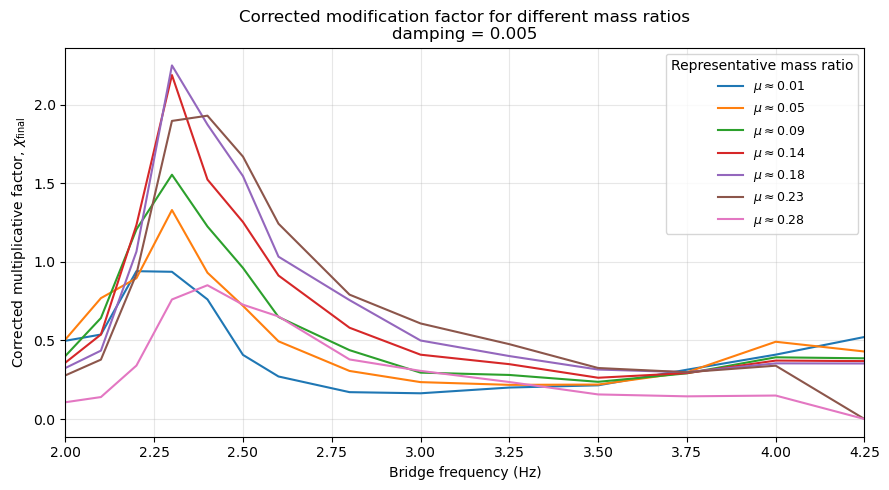

Plots saved in: \\ad.monash.edu\home\User029\slok0019\Documents\BSEN1990 2023\chi_final_plots_by_damping


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================
# LOAD DATA
# ============================================
df = pd.read_pickle("recovered_bias_results.pkl")

# chi_final is repeated for all measures, so keep only one measure
plot_df = df[df["measure"] == "Peak 1-sec RMS"].copy()

# ============================================
# OUTPUT FOLDER
# ============================================
out_dir = Path("chi_final_plots_by_damping")
out_dir.mkdir(exist_ok=True)

# ============================================
# UNIQUE VALUES
# ============================================
damping_values = sorted(plot_df["target_beamdamp"].dropna().unique())
density_values = sorted(plot_df["target_density"].dropna().unique())

# ============================================
# ONE FIGURE PER DAMPING
# ============================================
for damp in damping_values:

    sub_damp = plot_df[plot_df["target_beamdamp"] == damp].copy()

    plt.figure(figsize=(9, 5))

    for density in density_values:

        sub = sub_damp[sub_damp["target_density"] == density].copy()

        if sub.empty:
            continue

        sub = sub.sort_values("bridge_frequency")

        # representative mass ratio for the legend
        mu_rep = sub["mean_modal_mass_ratio"].mean()

        plt.plot(
            sub["bridge_frequency"],
            sub["chi_final"],
           
            linestyle="-",
            label=fr"$\mu \approx {mu_rep:.2f}$"
        )

    

    plt.xlabel("Bridge frequency (Hz)")
    plt.xlim(left=sub_damp["bridge_frequency"].min(), right=4.25)
    plt.ylabel(r"Corrected multiplicative factor, $\chi_{\mathrm{final}}$")
    plt.title(f"Corrected modification factor for different mass ratios\n"
              f"damping = {damp:.3f}")
    plt.grid(True, alpha=0.3)
    plt.legend(title="Representative mass ratio", fontsize=9)
    plt.tight_layout()

    fname = out_dir / f"chi_final_multi_density_damping_{damp:.3f}.png"
    #plt.savefig(fname, dpi=300)
    plt.show()

print(f"Plots saved in: {out_dir.resolve()}")

Remaining rows after filtering: 288


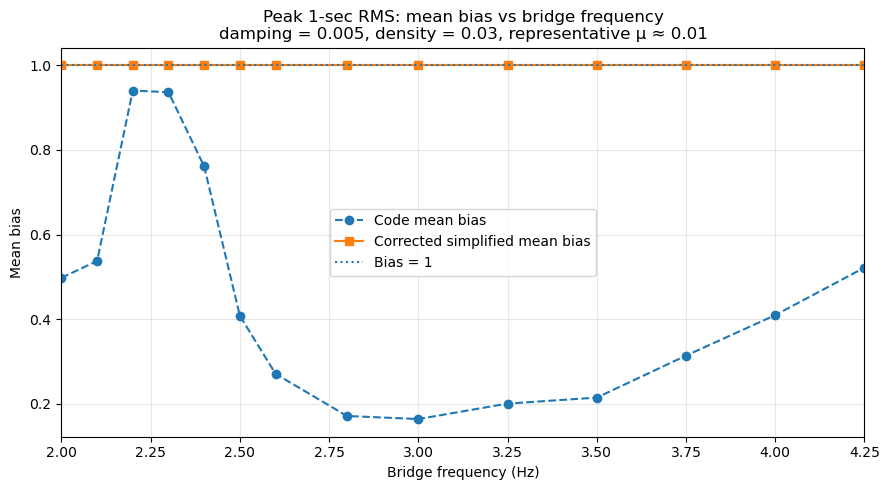

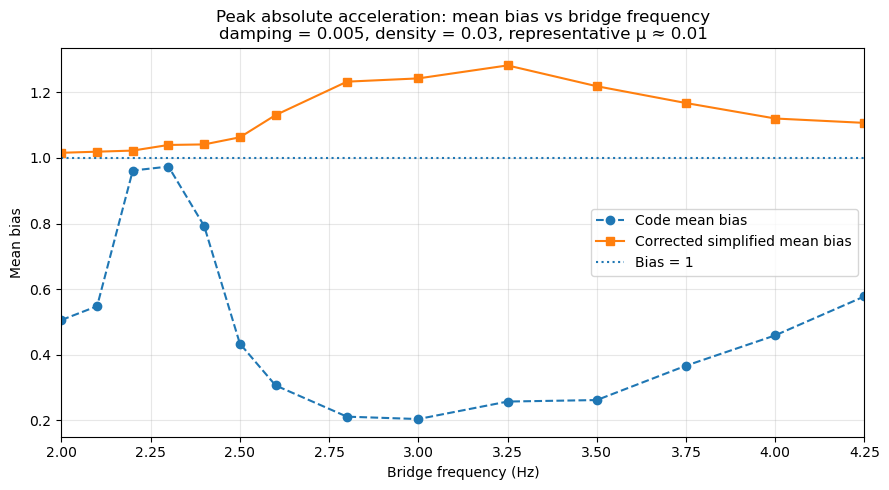

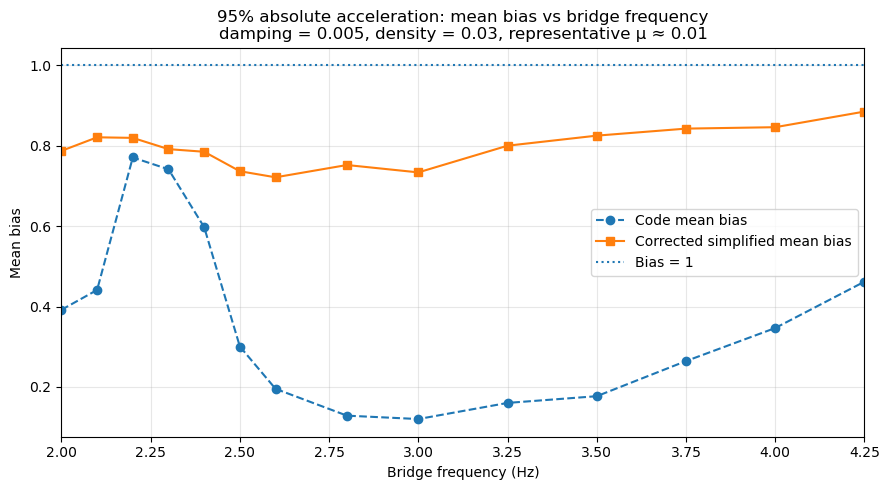

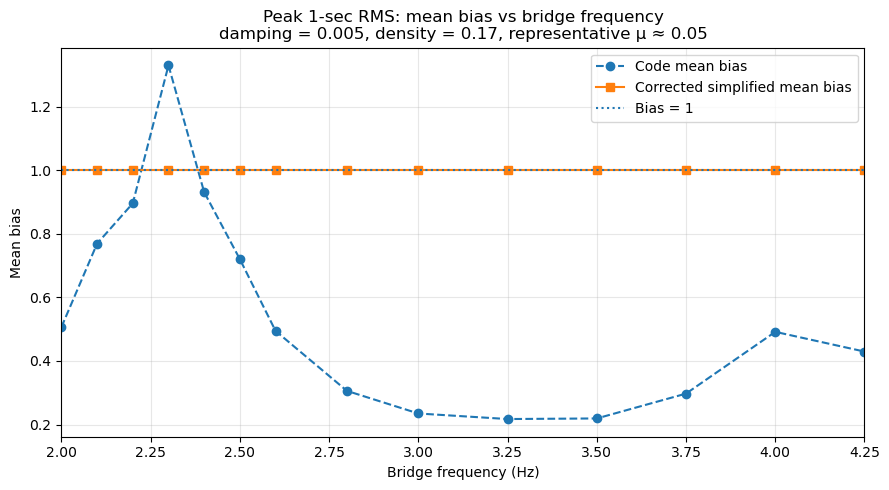

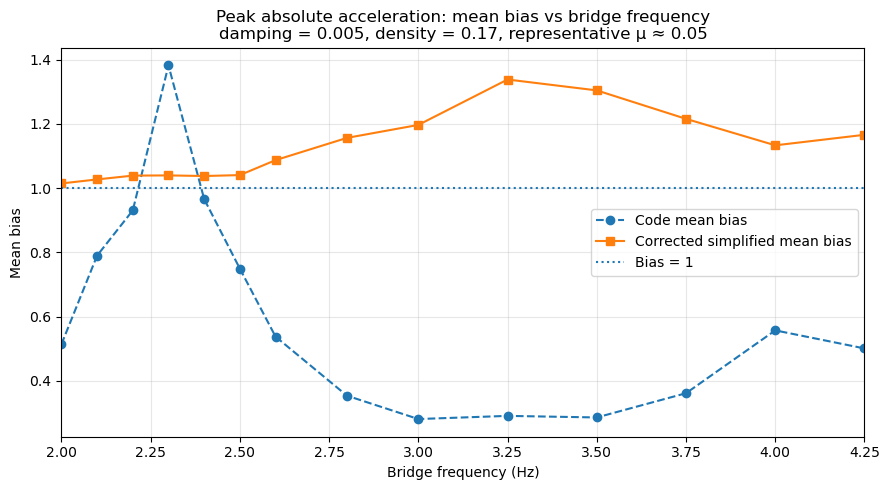

...

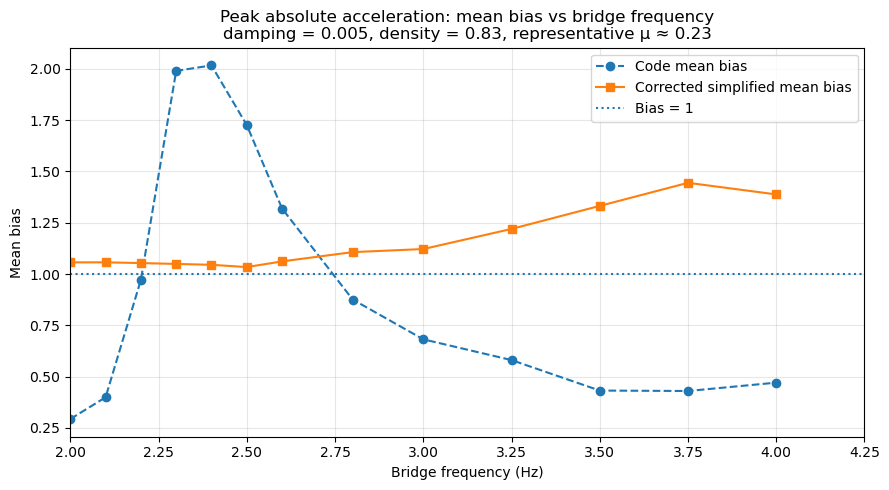

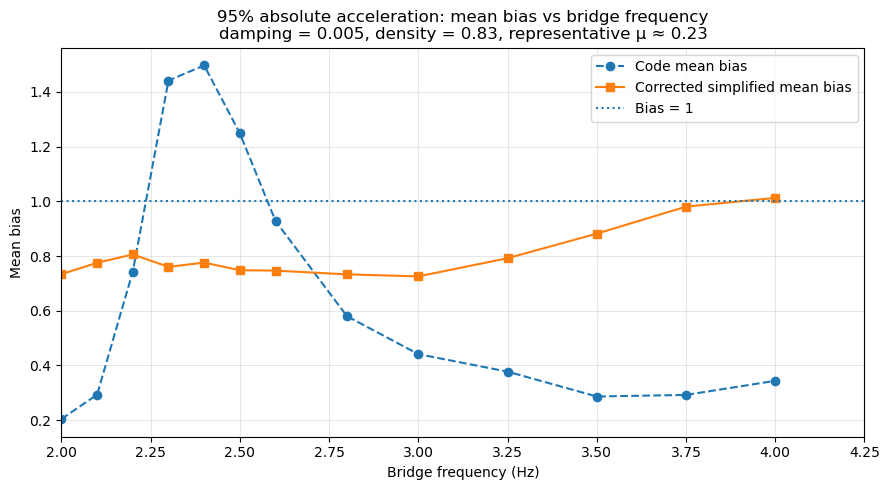

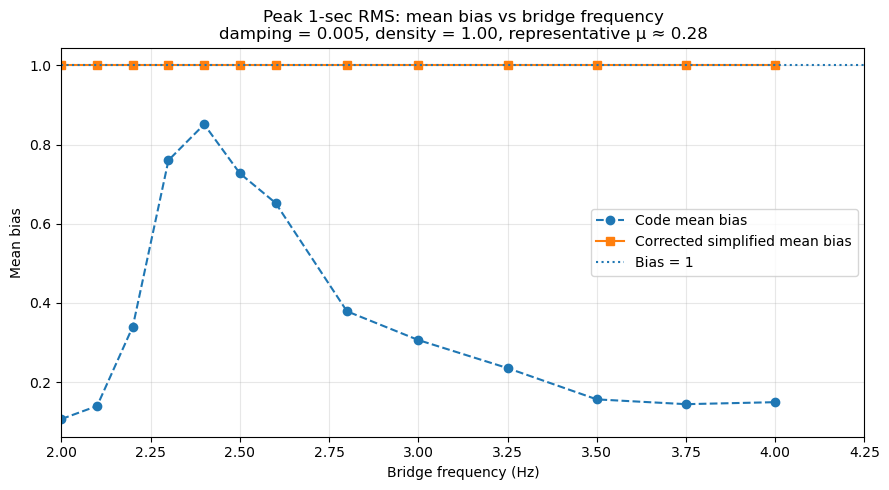

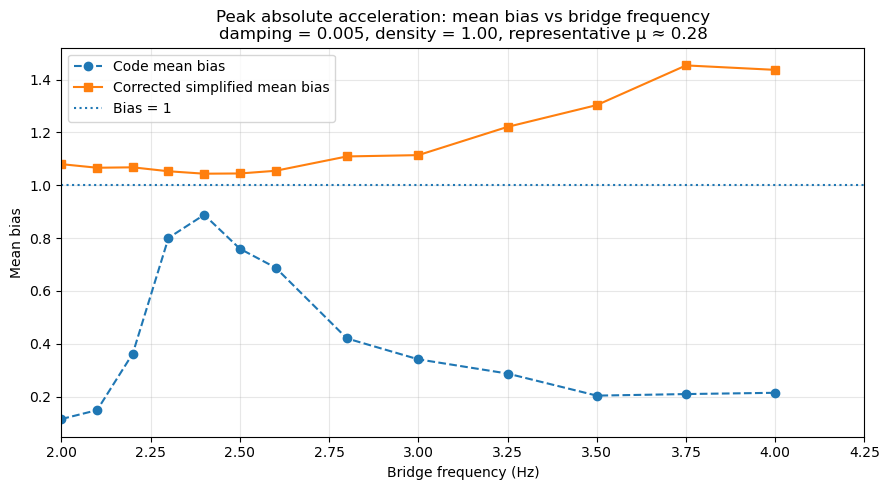

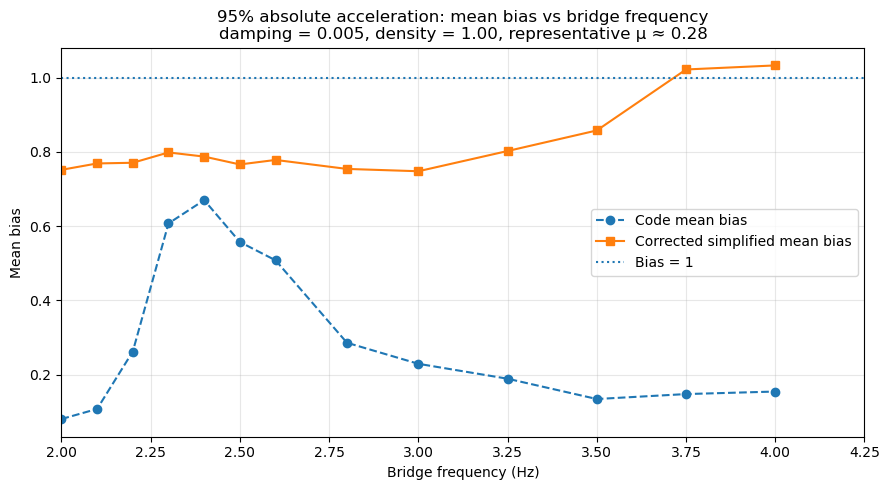

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================
# LOAD DATA
# ============================================
df = pd.read_pickle("recovered_bias_results.pkl")
# or:
# df = pd.read_pickle("recovered_bias_results.pkl")

# ============================================
# SETTINGS
# ============================================
xmax = 4.25

show_bias_1_line = True
save_plots = True
show_plots = True

# remove points with unrealistic huge bias
max_bias_to_keep = 10.0

measure_order = [
    "Peak 1-sec RMS",
    "Peak absolute acceleration",
    "95% absolute acceleration",
]

# ============================================
# CLEAN BASIC INVALID VALUES
# ============================================
df = df.copy()

# keep only frequencies up to xmax BEFORE plotting
df = df[df["bridge_frequency"] <= xmax].copy()

# remove rows where corrected factor/prediction became zero or invalid
df = df[
    (df["chi_final"] > 0.0) &
    (df["corrected_prediction"] > 0.0) &
    np.isfinite(df["code_mean_bias"]) &
    np.isfinite(df["corrected_simplified_bias"])
].copy()

# remove extreme bias values
df = df[
    (df["code_mean_bias"].abs() <= max_bias_to_keep) &
    (df["corrected_simplified_bias"].abs() <= max_bias_to_keep)
].copy()

print("Remaining rows after filtering:", len(df))

# ============================================
# LOOP OVER ALL DAMPING RATIOS
# ============================================
damping_values = sorted(df["target_beamdamp"].dropna().unique())

for damp in damping_values:

    sub_damp = df[df["target_beamdamp"] == damp].copy()

    density_values = sorted(sub_damp["target_density"].dropna().unique())

    # ============================================
    # LOOP OVER ALL DENSITIES / MASS RATIOS
    # ============================================
    for density in density_values:

        sub_density = sub_damp[sub_damp["target_density"] == density].copy()

        if sub_density.empty:
            continue

        # representative mass ratio for this density
        mu_rep = sub_density["mean_modal_mass_ratio"].mean()

        # ============================================
        # THREE PLOTS: ONE FOR EACH RESPONSE MEASURE
        # ============================================
        for measure_name in measure_order:

            sub = sub_density[sub_density["measure"] == measure_name].copy()

            if sub.empty:
                continue

            sub = sub.sort_values("bridge_frequency")

            plt.figure(figsize=(9, 5))

            # Code mean bias
            plt.plot(
                sub["bridge_frequency"],
                sub["code_mean_bias"],
                marker="o",
                linestyle="--",
                label="Code mean bias"
            )

            # Corrected simplified mean bias
            plt.plot(
                sub["bridge_frequency"],
                sub["corrected_simplified_bias"],
                marker="s",
                linestyle="-",
                label="Corrected simplified mean bias"
            )

            if show_bias_1_line:
                plt.axhline(
                    1.0,
                    linestyle=":",
                    linewidth=1.5,
                    label="Bias = 1"
                )

            plt.xlabel("Bridge frequency (Hz)")
            plt.ylabel("Mean bias")
            plt.title(
                f"{measure_name}: mean bias vs bridge frequency\n"
                f"damping = {damp:.3f}, "
                f"density = {density:.2f}, "
                f"representative μ ≈ {mu_rep:.2f}"
            )

            plt.xlim(sub["bridge_frequency"].min(), xmax)
            plt.grid(True, alpha=0.3)
            plt.legend()
            plt.tight_layout()

 
            if show_plots:
                plt.show()
            else:
                plt.close()

Loaded NEW modification-factor database.
Available bands: ['1.25_to_4.60']
Available damping values: [0.005, 0.01, 0.015, 0.02, 0.025, 0.03]
Available densities: [0.0333, 0.1667, 0.3333, 0.5, 0.6667, 0.8333, 1.0]

Database check
--------------
Test band: 1.25_to_4.60
Test damping: 0.005
Test bridge frequency: 1.25
Test density: 0.0333
Available keys: dict_keys(['t', 'modalpedmass_i', 'modification_factor', 'frf_ratio', 'psi_ratio', 'psi_ratio_valid', 'f_eff_peak', 'f0_peak'])

##########################################################################################
RUNNING STRUCTURAL DAMPING = 0.0050
##########################################################################################

RUNNING BRIDGE FREQUENCY = 1.500 Hz

----------------------------------------------------------------------
Running density = 0.1667
----------------------------------------------------------------------
Target density   = 0.1667
Actual density   = 0.1700
Total peds       = 17
Tocity, Outcity  = 8,

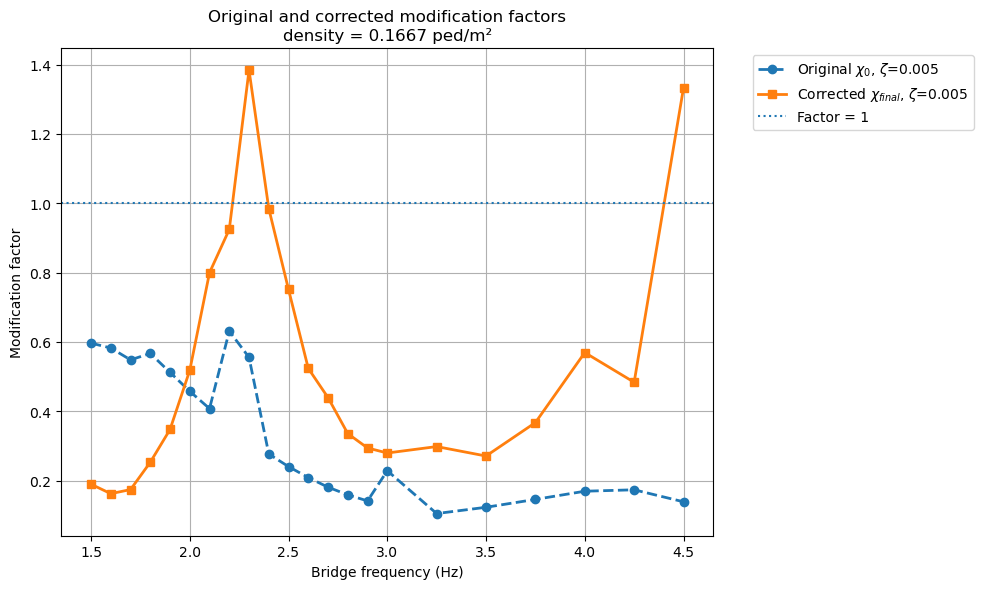

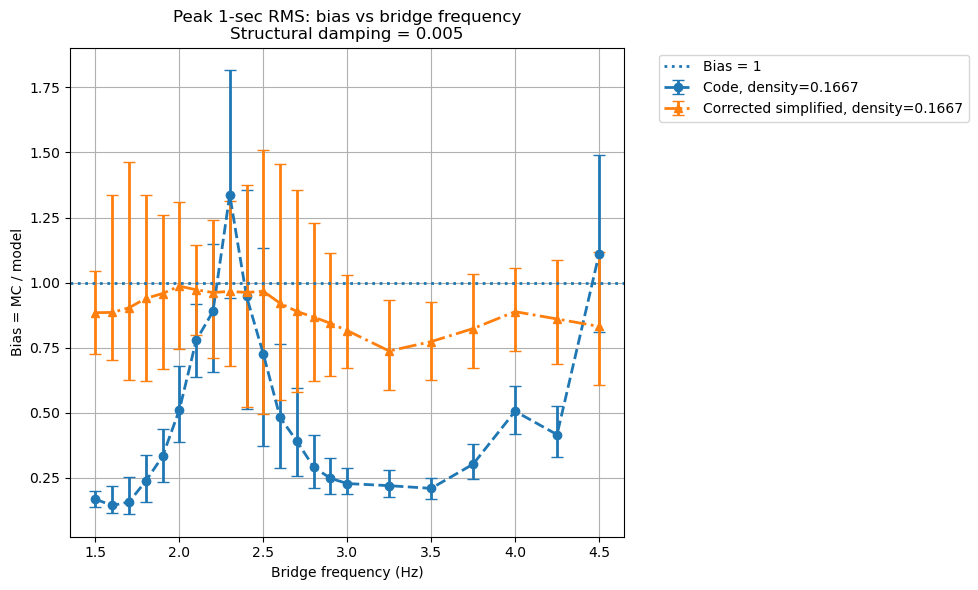

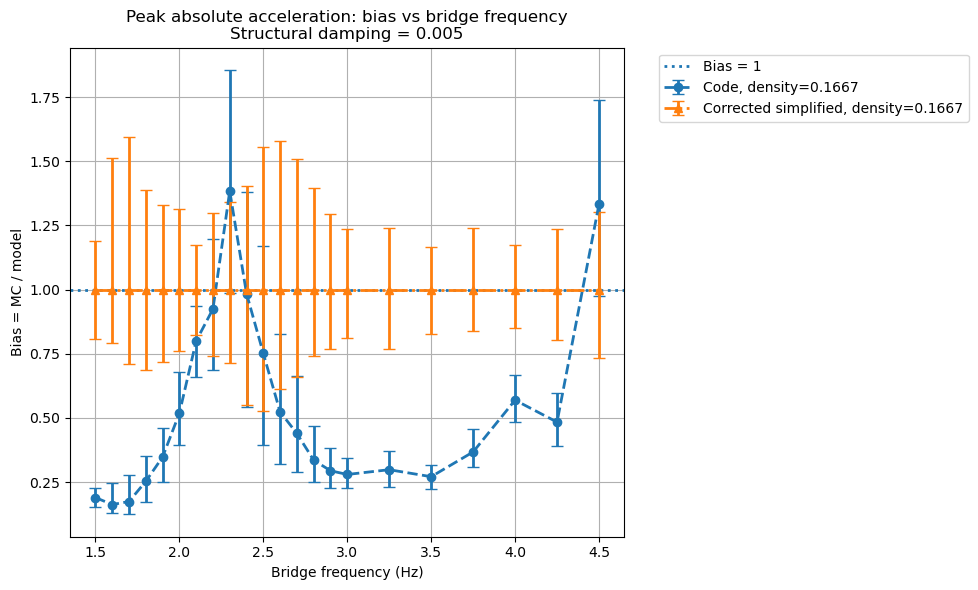

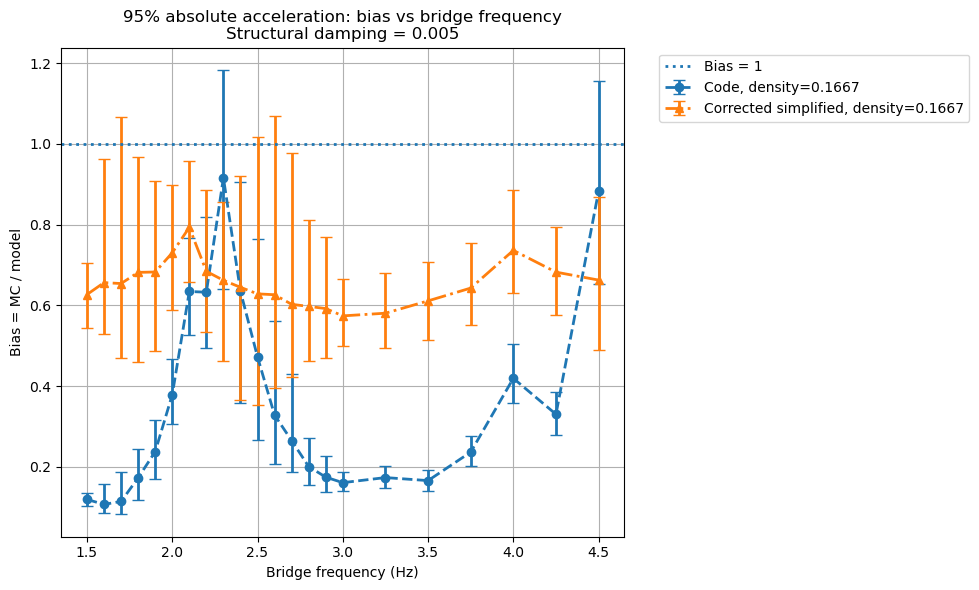

In [30]:
# ==================================================
# MULTI-FREQUENCY + MULTI-DAMPING MC + CODE + CORRECTED SIMPLIFIED SUMMARY
# Outputs:
#   1. original vs corrected modification factor plots
#   2. bias error bars for 3 response measures
# ==================================================

import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import torch
torch.set_num_threads(1)

import numpy as np
import matplotlib.pyplot as plt
import multiprocessing as mp
import pickle
import pandas as pd

from bias import run_simulation

from biascodefunction import (
    peak_rms_distribution,
    percentile_acc_distribution,
    peak_abs_acc_distribution,
    run_code_response_from_mc_inputs,
    interpolate_modification_factor_banded
)


# --------------------------------------------------
# USER SETTINGS
# --------------------------------------------------
NUM_SIMULATIONS = 96
NUM_PROCESSES = 12

hht = 0.01
steady_start_time = 10.0
linear_mass = 500.0

peddamp = 0.30
pedBodyF = 3.10

Length = 50.0
Width = 2.0

# Multiple damping ratios
target_beamdamp_values = [0.005]

bridge_frequencies_to_run = [
    1.5, 1.6, 1.7, 1.8, 1.9,2.0, 2.1, 2.2, 2.3, 2.4, 2.5, 2.6, 2.7,
    2.8, 2.9, 3.0, 3.25, 3.5, 3.75, 4.0,
    4.25, 4.5 
]

densities_to_run = [0.1667]

eps = 1e-12

# --------------------------------------------------
# Bias-correction settings
# --------------------------------------------------
CALIBRATION_MEASURE = "Peak absolute acceleration"
CORRECTION_STAT = "mean"      # options: "mean", "median", "p95"

# --------------------------------------------------
# Modification-factor database
# --------------------------------------------------
FORCE_FACTOR_FILE = "NMFR_2.pkl"

# Mass-ratio cap for interpolation database
MR_MIN_DATABASE = 0.0089
MR_MIN_USED = 0.0090
MR_MAX_DATABASE = 0.2954
MR_MAX_USED = 0.29


# --------------------------------------------------
# Helper: cap MC mass ratio inside interpolation range
# --------------------------------------------------
def cap_mass_ratio_for_interpolation(mc_mass_ratio):
    mc_mass_ratio = float(mc_mass_ratio)

    if mc_mass_ratio < MR_MIN_DATABASE:
        return MR_MIN_USED
    elif mc_mass_ratio > MR_MAX_DATABASE:
        return MR_MAX_USED
    else:
        return mc_mass_ratio


# --------------------------------------------------
# Response measures
# --------------------------------------------------
measure_specs = {
    "Peak 1-sec RMS": {
        "mc_key": "peak_rms",
        "code_key": "peak_1sec_rms",
    },
    "Peak absolute acceleration": {
        "mc_key": "peak_abs",
        "code_key": "peak_abs_acc",
    },
    "95% absolute acceleration": {
        "mc_key": "p95_abs",
        "code_key": "p95_abs_acc",
    },
}


# ==================================================
# MAIN LOOP
# ==================================================
if __name__ == "__main__":

    try:
        mp.set_start_method("spawn")
    except RuntimeError:
        pass

    # --------------------------------------------------
    # Load modification-factor database inside main block
    # --------------------------------------------------
    with open(FORCE_FACTOR_FILE, "rb") as f:
        ff_data = pickle.load(f)

    ff_results_all = ff_data["results_all"]
    ff_densities = ff_data["densities"]
    ff_damping_values = ff_data["damping_values"]
    ff_pedBodyF = ff_data["pedBodyF"]

    ff_bands_to_combine = list(ff_results_all.keys())

    print("Loaded NEW modification-factor database.")
    print("Available bands:", ff_bands_to_combine)
    print("Available damping values:", ff_damping_values)
    print("Available densities:", ff_densities)

    # Optional safety check
    test_band = ff_bands_to_combine[0]
    test_damp = ff_damping_values[0]
    test_bf = sorted(ff_results_all[test_band][test_damp].keys())[0]
    test_density = ff_densities[0]
    test_keys = ff_results_all[test_band][test_damp][test_bf][test_density].keys()

    print("\nDatabase check")
    print("--------------")
    print("Test band:", test_band)
    print("Test damping:", test_damp)
    print("Test bridge frequency:", test_bf)
    print("Test density:", test_density)
    print("Available keys:", test_keys)

    if "modification_factor" not in test_keys:
        raise KeyError("The database does not contain 'modification_factor'.")

    ctx = mp.get_context("spawn")
    rng = np.random.default_rng(12345)

    summary_rows = []

    with ctx.Pool(processes=NUM_PROCESSES) as pool:

        for target_beamdamp in target_beamdamp_values:

            print("\n" + "#" * 90)
            print(f"RUNNING STRUCTURAL DAMPING = {target_beamdamp:.4f}")
            print("#" * 90)

            for target_bf in bridge_frequencies_to_run:

                print("\n" + "=" * 80)
                print(f"RUNNING BRIDGE FREQUENCY = {target_bf:.3f} Hz")
                print("=" * 80)

                BeamFreq = np.array([target_bf, 4.0 * target_bf])
                Beamdamp = np.array([target_beamdamp])

                for density in densities_to_run:

                    print("\n" + "-" * 70)
                    print(f"Running density = {density:.4f}")
                    print("-" * 70)

                    # --------------------------------------------------
                    # Convert density to integer pedestrian counts
                    # --------------------------------------------------
                    total_peds_float = density * Length * Width
                    total_peds_int = int(round(total_peds_float))
                    total_peds_int = max(1, total_peds_int)

                    Tocity = total_peds_int // 2
                    Outcity = total_peds_int - Tocity

                    actual_density = (Tocity + Outcity) / (Length * Width)

                    print(f"Target density   = {density:.4f}")
                    print(f"Actual density   = {actual_density:.4f}")
                    print(f"Total peds       = {total_peds_int}")
                    print(f"Tocity, Outcity  = {Tocity}, {Outcity}")

                    # --------------------------------------------------
                    # Run MC reference simulations
                    # --------------------------------------------------
                    seeds = rng.integers(0, 2**31 - 1, size=NUM_SIMULATIONS)

                    args_list = [
                        (
                            int(seeds[i]),
                            peddamp,
                            pedBodyF,
                            BeamFreq,
                            Beamdamp,
                            Tocity,
                            Outcity,
                            Length,
                            Width
                        )
                        for i in range(NUM_SIMULATIONS)
                    ]

                    results = pool.map(run_simulation, args_list)

                    # --------------------------------------------------
                    # Extract MC acceleration histories and mass ratios
                    # --------------------------------------------------
                    accelerations = np.array([r[0] for r in results])
                    mean_mass_ratios = np.array([r[1] for r in results])

                    overall_mean_mass_ratio = np.mean(mean_mass_ratios)

                    print(f"MC acceleration shape       = {accelerations.shape}")
                    print(f"Mean modal mass ratio       = {overall_mean_mass_ratio:.6f}")

                    # --------------------------------------------------
                    # Remove initial transient
                    # --------------------------------------------------
                    steady_start_idx = int(round(steady_start_time / hht))

                    if steady_start_idx >= accelerations.shape[1]:
                        raise ValueError(
                            "steady_start_time is longer than acceleration time history."
                        )

                    accelerations_ss = accelerations[:, steady_start_idx:]

                    # --------------------------------------------------
                    # MC response distributions
                    # --------------------------------------------------
                    rms_histories, peak_rms_values = peak_rms_distribution(
                        accelerations_ss,
                        dt=hht,
                        window_sec=1.0
                    )

                    peak_abs_values = peak_abs_acc_distribution(
                        accelerations_ss
                    )

                    p95_abs_values = percentile_acc_distribution(
                        accelerations_ss,
                        percentile=95,
                        use_abs=True
                    )

                    mc_values = {
                        "peak_rms": peak_rms_values,
                        "peak_abs": peak_abs_values,
                        "p95_abs": p95_abs_values,
                    }

                    # --------------------------------------------------
                    # Original deterministic/code model
                    # --------------------------------------------------
                    t_end = accelerations.shape[1] * hht

                    code_result, code_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=1.0
                    )

                    # --------------------------------------------------
                    # Interpolate original modification factor chi_0
                    # --------------------------------------------------
                    target_mass_ratio_used = cap_mass_ratio_for_interpolation(
                        overall_mean_mass_ratio
                    )

                    x_factor, interp_details = interpolate_modification_factor_banded(
                        results_all=ff_results_all,
                        target_bf=target_bf,
                        target_beamdamp=target_beamdamp,
                        target_mass_ratio=target_mass_ratio_used,
                        damping_values=ff_damping_values,
                        densities=ff_densities,
                        bands_to_combine=ff_bands_to_combine,
                        factor_key="modification_factor"
                    )

                    force_reduction_factor_used = x_factor

                    print("\nModification-factor interpolation")
                    print("---------------------------------")
                    print(f"Target bf                        = {target_bf:.6f}")
                    print(f"Target damping                   = {target_beamdamp:.6f}")
                    print(f"MC mean modal mass ratio          = {overall_mean_mass_ratio:.6f}")
                    print(f"Mass ratio used in interpolation  = {target_mass_ratio_used:.6f}")
                    print(f"Interpolated factor chi_0         = {x_factor:.6f}")

                    # --------------------------------------------------
                    # Simplified deterministic model using chi_0
                    # --------------------------------------------------
                    simplified_result, simplified_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=force_reduction_factor_used
                    )

                    # --------------------------------------------------
                    # Residual correction factor lambda
                    # --------------------------------------------------
                    cal_spec = measure_specs[CALIBRATION_MEASURE]

                    Y_cal = np.asarray(mc_values[cal_spec["mc_key"]], dtype=float)
                    Y_cal = Y_cal[np.isfinite(Y_cal)]

                    simp_val_cal = simplified_measures[cal_spec["code_key"]]

                    B_simp_cal = Y_cal / max(simp_val_cal, eps)

                    if CORRECTION_STAT == "mean":
                        residual_correction_factor = np.mean(B_simp_cal)

                    elif CORRECTION_STAT == "median":
                        residual_correction_factor = np.percentile(B_simp_cal, 50)

                    elif CORRECTION_STAT == "p95":
                        residual_correction_factor = np.percentile(B_simp_cal, 95)

                    else:
                        raise ValueError(
                            "CORRECTION_STAT must be 'mean', 'median', or 'p95'."
                        )

                    final_modification_factor = x_factor * residual_correction_factor

                    print("\nResidual bias correction")
                    print("------------------------")
                    print(f"Calibration measure        = {CALIBRATION_MEASURE}")
                    print(f"Correction statistic       = {CORRECTION_STAT}")
                    print(f"Initial factor chi_0        = {x_factor:.6f}")
                    print(f"Residual correction lambda  = {residual_correction_factor:.6f}")
                    print(f"Final factor chi_final      = {final_modification_factor:.6f}")

                    # --------------------------------------------------
                    # Corrected simplified deterministic model
                    # --------------------------------------------------
                    corrected_result, corrected_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=final_modification_factor
                    )

                    # --------------------------------------------------
                    # Bias distributions for all 3 measures
                    # --------------------------------------------------
                    for measure_name, spec in measure_specs.items():

                        Y_ref = np.asarray(mc_values[spec["mc_key"]], dtype=float)
                        Y_ref = Y_ref[np.isfinite(Y_ref)]

                        code_val = code_measures[spec["code_key"]]
                        simp_val = simplified_measures[spec["code_key"]]
                        corr_val = corrected_measures[spec["code_key"]]

                        B_code = Y_ref / max(code_val, eps)
                        B_simp = Y_ref / max(simp_val, eps)
                        B_corr = Y_ref / max(corr_val, eps)

                        summary_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "actual_density": actual_density,
                            "total_peds": total_peds_int,
                            "Tocity": Tocity,
                            "Outcity": Outcity,

                            "mean_modal_mass_ratio": overall_mean_mass_ratio,
                            "mass_ratio_used_for_interpolation": target_mass_ratio_used,

                            "initial_modification_factor": x_factor,
                            "residual_correction_factor": residual_correction_factor,
                            "final_modification_factor": final_modification_factor,

                            "calibration_measure": CALIBRATION_MEASURE,
                            "correction_stat": CORRECTION_STAT,

                            "measure": measure_name,

                            "mc_mean": np.mean(Y_ref),
                            "mc_p5": np.percentile(Y_ref, 5),
                            "mc_p50": np.percentile(Y_ref, 50),
                            "mc_p95": np.percentile(Y_ref, 95),

                            "code_prediction": code_val,
                            "simplified_prediction": simp_val,
                            "corrected_prediction": corr_val,

                            "code_bias_mean": np.mean(B_code),
                            "code_bias_p5": np.percentile(B_code, 5),
                            "code_bias_p50": np.percentile(B_code, 50),
                            "code_bias_p95": np.percentile(B_code, 95),

                            "simplified_bias_mean": np.mean(B_simp),
                            "simplified_bias_p5": np.percentile(B_simp, 5),
                            "simplified_bias_p50": np.percentile(B_simp, 50),
                            "simplified_bias_p95": np.percentile(B_simp, 95),

                            "corrected_bias_mean": np.mean(B_corr),
                            "corrected_bias_p5": np.percentile(B_corr, 5),
                            "corrected_bias_p50": np.percentile(B_corr, 50),
                            "corrected_bias_p95": np.percentile(B_corr, 95),
                        })

                        print(f"\n{measure_name}")
                        print(f"  MC mean                   = {np.mean(Y_ref):.6f}")
                        print(f"  Code prediction           = {code_val:.6f}")
                        print(f"  Simplified prediction     = {simp_val:.6f}")
                        print(f"  Corrected prediction      = {corr_val:.6f}")
                        print(f"  Code mean bias            = {np.mean(B_code):.6f}")
                        print(f"  Simplified mean bias      = {np.mean(B_simp):.6f}")
                        print(f"  Corrected simplified bias = {np.mean(B_corr):.6f}")

    # ==================================================
    # SAVE SUMMARY
    # ==================================================
    summary_df = pd.DataFrame(summary_rows)

    summary_pkl = "density0.1667_damping0.005_bias_summary.pkl"
    #summary_csv = "density0.1667_damping0.005_bias_summary.csv"

    with open(summary_pkl, "wb") as f:
        pickle.dump(summary_df, f, protocol=pickle.HIGHEST_PROTOCOL)

    #summary_df.to_csv(summary_csv, index=False)

    print("\nSaved summary files:")
    print(summary_pkl)
    #print(summary_csv)

    # ==================================================
    # PLOT 1: ORIGINAL vs CORRECTED MODIFICATION FACTOR
    # One plot per density, all damping ratios included
    # ==================================================
    factor_df = summary_df.drop_duplicates(
        subset=["bridge_frequency", "target_density", "target_beamdamp"]
    ).copy()

    for density in densities_to_run:

        plt.figure(figsize=(10, 6))

        for target_beamdamp in target_beamdamp_values:

            sub = factor_df[
                (factor_df["target_density"] == density) &
                (factor_df["target_beamdamp"] == target_beamdamp)
            ].copy()

            sub = sub.sort_values("bridge_frequency")

            plt.plot(
                sub["bridge_frequency"],
                sub["initial_modification_factor"],
                marker="o",
                linestyle="--",
                linewidth=2,
                label=rf"Original $\chi_0$, $\zeta$={target_beamdamp:.3f}"
            )

            plt.plot(
                sub["bridge_frequency"],
                sub["final_modification_factor"],
                marker="s",
                linestyle="-",
                linewidth=2,
                label=rf"Corrected $\chi_{{final}}$, $\zeta$={target_beamdamp:.3f}"
            )

        plt.axhline(
            1.0,
            linestyle=":",
            linewidth=1.5,
            label="Factor = 1"
        )

        plt.xlabel("Bridge frequency (Hz)")
        plt.ylabel("Modification factor")
        plt.title(
            f"Original and corrected modification factors\n"
            f"density = {density:.4f} ped/m²"
        )

        plt.grid(True)
        plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.tight_layout()
        plt.show()

    # ==================================================
    # PLOTS 2-4: ERROR BARS FOR EACH RESPONSE MEASURE
    # One plot per vibration measure and damping ratio
    # Only Code and Corrected Simplified are plotted
    # ==================================================
    for target_beamdamp in target_beamdamp_values:

        for measure_name in measure_specs.keys():

            plt.figure(figsize=(10, 6))

            for density in densities_to_run:

                sub = summary_df[
                    (summary_df["target_beamdamp"] == target_beamdamp) &
                    (summary_df["target_density"] == density) &
                    (summary_df["measure"] == measure_name)
                ].copy()

                sub = sub.sort_values("bridge_frequency")

                x = sub["bridge_frequency"].values

                # -----------------------------
                # Original code bias
                # -----------------------------
                y_code = sub["code_bias_mean"].values
                y_code_p5 = sub["code_bias_p5"].values
                y_code_p95 = sub["code_bias_p95"].values

                yerr_code = np.vstack([
                    y_code - y_code_p5,
                    y_code_p95 - y_code
                ])

                plt.errorbar(
                    x,
                    y_code,
                    yerr=yerr_code,
                    marker="o",
                    linestyle="--",
                    linewidth=2,
                    capsize=4,
                    label=f"Code, density={density:.4f}"
                )

                # -----------------------------
                # Corrected simplified model bias
                # -----------------------------
                y_corr = sub["corrected_bias_mean"].values
                y_corr_p5 = sub["corrected_bias_p5"].values
                y_corr_p95 = sub["corrected_bias_p95"].values

                yerr_corr = np.vstack([
                    y_corr - y_corr_p5,
                    y_corr_p95 - y_corr
                ])

                plt.errorbar(
                    x,
                    y_corr,
                    yerr=yerr_corr,
                    marker="^",
                    linestyle="-.",
                    linewidth=2,
                    capsize=4,
                    label=f"Corrected simplified, density={density:.4f}"
                )

            plt.axhline(
                1.0,
                linestyle=":",
                linewidth=2,
                label="Bias = 1"
            )

            plt.xlabel("Bridge frequency (Hz)")
            plt.ylabel("Bias = MC / model")
            plt.title(
                f"{measure_name}: bias vs bridge frequency\n"
                f"Structural damping = {target_beamdamp:.3f}"
            )

            plt.grid(True)
            plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
            plt.tight_layout()
            plt.show()

In [49]:
import importlib
import biascodefunction

# Reload the updated .py file
importlib.reload(biascodefunction)
print("biascodefunction.py reloaded successfully.")

import importlib
import bias

# Reload the newest saved version of bias.py
importlib.reload(bias)

biascodefunction.py reloaded successfully.


<module 'bias' from '\\\\ad.monash.edu\\home\\User029\\slok0019\\Documents\\BSEN1990 2023\\bias.py'>

Loaded NEW modification-factor database.
Available bands: ['1.25_to_4.60']
Available damping values: [0.005, 0.01, 0.015, 0.02, 0.025, 0.03]
Available densities: [0.0333, 0.1667, 0.3333, 0.5, 0.6667, 0.8333, 1.0]

Database check
--------------
Test band: 1.25_to_4.60
Test damping: 0.005
Test bridge frequency: 1.25
Test density: 0.0333
Available keys: dict_keys(['t', 'modalpedmass_i', 'modification_factor', 'frf_ratio', 'psi_ratio', 'psi_ratio_valid', 'f_eff_peak', 'f0_peak'])

##########################################################################################
RUNNING STRUCTURAL DAMPING = 0.0100
##########################################################################################

RUNNING BRIDGE FREQUENCY = 1.400 Hz

----------------------------------------------------------------------
Running density = 0.1667
----------------------------------------------------------------------
Target density   = 0.1667
Actual density   = 0.1700
Total peds       = 17
Tocity, Outcity  = 8,

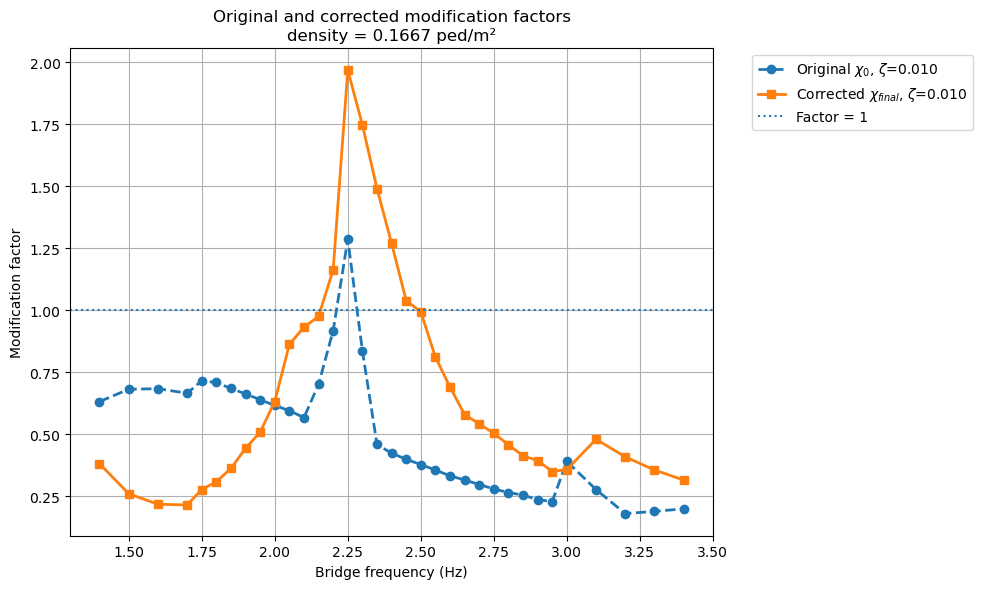

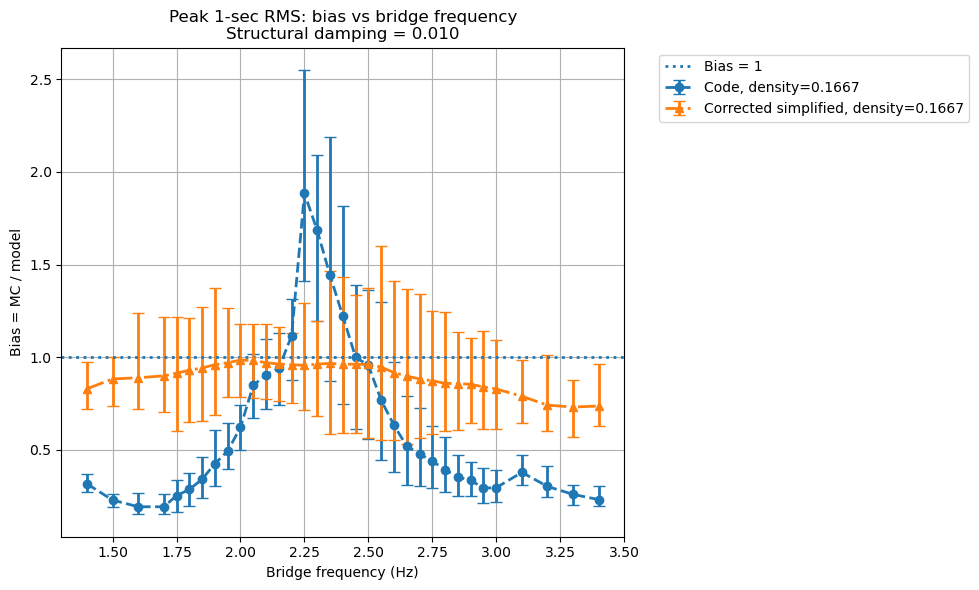

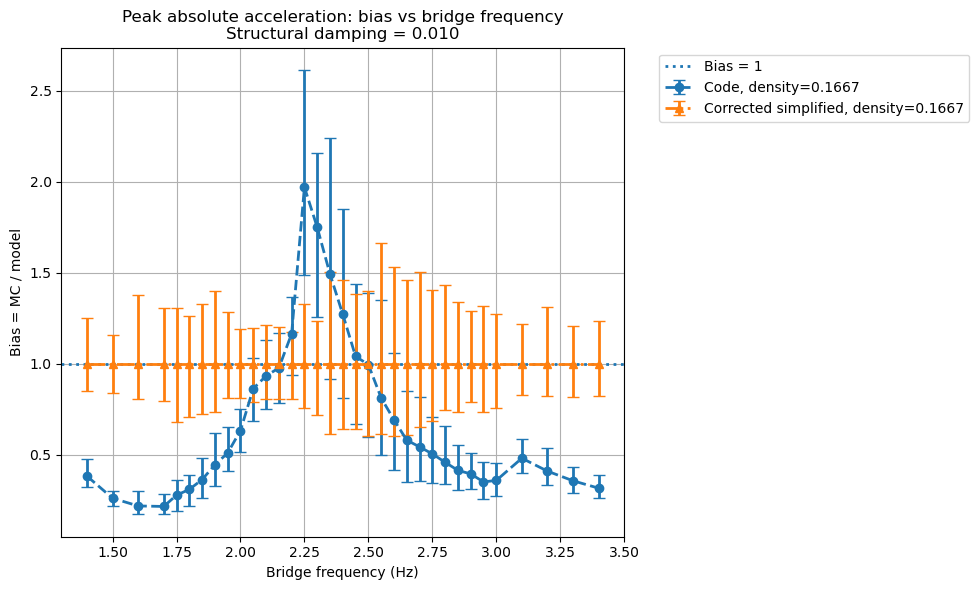

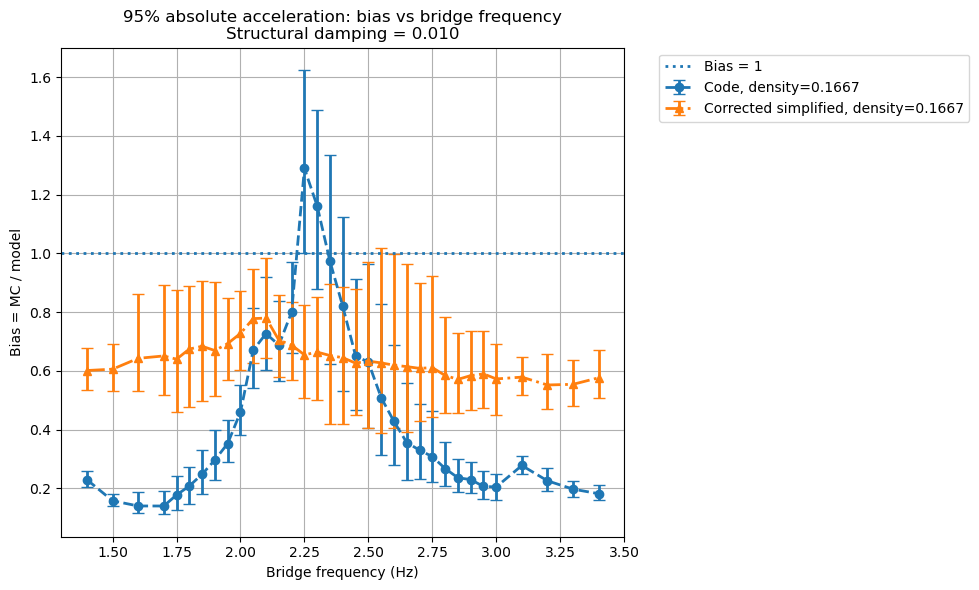

In [43]:
# ==================================================
# MULTI-FREQUENCY + MULTI-DAMPING MC + CODE + CORRECTED SIMPLIFIED SUMMARY
# Outputs:
#   1. original vs corrected modification factor plots
#   2. bias error bars for 3 response measures
# ==================================================

import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import torch
torch.set_num_threads(1)

import numpy as np
import matplotlib.pyplot as plt
import multiprocessing as mp
import pickle
import pandas as pd

from bias import run_simulation

from biascodefunction import (
    peak_rms_distribution,
    percentile_acc_distribution,
    peak_abs_acc_distribution,
    run_code_response_from_mc_inputs,
    interpolate_modification_factor_banded,
    running_mean_sd_1d,
    running_instantaneous_acc_stats
)


# --------------------------------------------------
# USER SETTINGS
# --------------------------------------------------
NUM_SIMULATIONS = 50
NUM_PROCESSES = 12

hht = 0.01
steady_start_time = 10.0
linear_mass = 500.0

peddamp = 0.30
pedBodyF = 3.10

Length = 50.0
Width = 2.0

# Multiple damping ratios
target_beamdamp_values = [0.010]

bridge_frequencies_to_run = [
    1.4, 1.5, 1.6, 1.7, 1.75, 1.8, 1.85, 1.9, 1.95, 2.0, 2.05, 2.1, 2.15, 2.2, 2.25, 2.3, 2.35, 2.4, 2.45, 2.5, 2.55, 2.6, 2.65, 2.7,
    2.75, 2.8, 2.85, 2.9, 2.95, 3.0, 3.1, 3.2, 3.3, 3.4
]

densities_to_run = [0.1667]

eps = 1e-12

# --------------------------------------------------
# Bias-correction settings
# --------------------------------------------------
CALIBRATION_MEASURE = "Peak absolute acceleration"
CORRECTION_STAT = "mean"      # options: "mean", "median", "p95"

# --------------------------------------------------
# Modification-factor database
# --------------------------------------------------
FORCE_FACTOR_FILE = "NMFR_2.pkl"

# Mass-ratio cap for interpolation database
MR_MIN_DATABASE = 0.0089
MR_MIN_USED = 0.0090
MR_MAX_DATABASE = 0.2954
MR_MAX_USED = 0.29


# --------------------------------------------------
# Helper: cap MC mass ratio inside interpolation range
# --------------------------------------------------
def cap_mass_ratio_for_interpolation(mc_mass_ratio):
    mc_mass_ratio = float(mc_mass_ratio)

    if mc_mass_ratio < MR_MIN_DATABASE:
        return MR_MIN_USED
    elif mc_mass_ratio > MR_MAX_DATABASE:
        return MR_MAX_USED
    else:
        return mc_mass_ratio


# --------------------------------------------------
# Response measures
# --------------------------------------------------
measure_specs = {
    "Peak 1-sec RMS": {
        "mc_key": "peak_rms",
        "code_key": "peak_1sec_rms",
    },
    "Peak absolute acceleration": {
        "mc_key": "peak_abs",
        "code_key": "peak_abs_acc",
    },
    "95% absolute acceleration": {
        "mc_key": "p95_abs",
        "code_key": "p95_abs_acc",
    },
}


# ==================================================
# MAIN LOOP
# ==================================================
if __name__ == "__main__":

    try:
        mp.set_start_method("spawn")
    except RuntimeError:
        pass

    # --------------------------------------------------
    # Load modification-factor database inside main block
    # --------------------------------------------------
    with open(FORCE_FACTOR_FILE, "rb") as f:
        ff_data = pickle.load(f)

    ff_results_all = ff_data["results_all"]
    ff_densities = ff_data["densities"]
    ff_damping_values = ff_data["damping_values"]
    ff_pedBodyF = ff_data["pedBodyF"]

    ff_bands_to_combine = list(ff_results_all.keys())

    print("Loaded NEW modification-factor database.")
    print("Available bands:", ff_bands_to_combine)
    print("Available damping values:", ff_damping_values)
    print("Available densities:", ff_densities)

    # Optional safety check
    test_band = ff_bands_to_combine[0]
    test_damp = ff_damping_values[0]
    test_bf = sorted(ff_results_all[test_band][test_damp].keys())[0]
    test_density = ff_densities[0]
    test_keys = ff_results_all[test_band][test_damp][test_bf][test_density].keys()

    print("\nDatabase check")
    print("--------------")
    print("Test band:", test_band)
    print("Test damping:", test_damp)
    print("Test bridge frequency:", test_bf)
    print("Test density:", test_density)
    print("Available keys:", test_keys)

    if "modification_factor" not in test_keys:
        raise KeyError("The database does not contain 'modification_factor'.")

    ctx = mp.get_context("spawn")
    rng = np.random.default_rng(12345)

    summary_rows = []
    convergence_rows = []

    with ctx.Pool(processes=NUM_PROCESSES) as pool:

        for target_beamdamp in target_beamdamp_values:

            print("\n" + "#" * 90)
            print(f"RUNNING STRUCTURAL DAMPING = {target_beamdamp:.4f}")
            print("#" * 90)

            for target_bf in bridge_frequencies_to_run:

                print("\n" + "=" * 80)
                print(f"RUNNING BRIDGE FREQUENCY = {target_bf:.3f} Hz")
                print("=" * 80)

                BeamFreq = np.array([target_bf, 4.0 * target_bf])
                Beamdamp = np.array([target_beamdamp])

                for density in densities_to_run:

                    print("\n" + "-" * 70)
                    print(f"Running density = {density:.4f}")
                    print("-" * 70)

                    # --------------------------------------------------
                    # Convert density to integer pedestrian counts
                    # --------------------------------------------------
                    total_peds_float = density * Length * Width
                    total_peds_int = int(round(total_peds_float))
                    total_peds_int = max(1, total_peds_int)

                    Tocity = total_peds_int // 2
                    Outcity = total_peds_int - Tocity

                    actual_density = (Tocity + Outcity) / (Length * Width)

                    print(f"Target density   = {density:.4f}")
                    print(f"Actual density   = {actual_density:.4f}")
                    print(f"Total peds       = {total_peds_int}")
                    print(f"Tocity, Outcity  = {Tocity}, {Outcity}")

                    # --------------------------------------------------
                    # Run MC reference simulations
                    # --------------------------------------------------
                    seeds = rng.integers(0, 2**31 - 1, size=NUM_SIMULATIONS)

                    args_list = [
                        (
                            int(seeds[i]),
                            peddamp,
                            pedBodyF,
                            BeamFreq,
                            Beamdamp,
                            Tocity,
                            Outcity,
                            Length,
                            Width
                        )
                        for i in range(NUM_SIMULATIONS)
                    ]

                    results = pool.map(run_simulation, args_list)

                    # --------------------------------------------------
                    # Extract MC acceleration histories and mass ratios
                    # --------------------------------------------------
                    accelerations = np.array([r[0] for r in results])
                    mean_mass_ratios = np.array([r[1] for r in results])

                    overall_mean_mass_ratio = np.mean(mean_mass_ratios)

                    print(f"MC acceleration shape       = {accelerations.shape}")
                    print(f"Mean modal mass ratio       = {overall_mean_mass_ratio:.6f}")

                    # --------------------------------------------------
                    # Remove initial transient
                    # --------------------------------------------------
                    steady_start_idx = int(round(steady_start_time / hht))

                    if steady_start_idx >= accelerations.shape[1]:
                        raise ValueError(
                            "steady_start_time is longer than acceleration time history."
                        )

                    accelerations_ss = accelerations[:, steady_start_idx:]

                    # --------------------------------------------------
                    # MC response distributions
                    # --------------------------------------------------
                    rms_histories, peak_rms_values = peak_rms_distribution(
                        accelerations_ss,
                        dt=hht,
                        window_sec=1.0
                    )

                    peak_abs_values = peak_abs_acc_distribution(
                        accelerations_ss
                    )

                    p95_abs_values = percentile_acc_distribution(
                        accelerations_ss,
                        percentile=95,
                        use_abs=True
                    )

                    mc_values = {
                        "peak_rms": peak_rms_values,
                        "peak_abs": peak_abs_values,
                        "p95_abs": p95_abs_values,
                    }

                    # ==================================================
                    # CONVERGENCE STATISTICS
                    # Instantaneous acceleration + response measures
                    # ==================================================

                    # --------------------------------------------------
                    # A) Instantaneous acceleration convergence
                    # --------------------------------------------------
                    sim_numbers_inst, inst_running_mean, inst_running_sd = (
                        running_instantaneous_acc_stats(accelerations_ss)
                    )

                    all_acc_values = accelerations_ss.reshape(-1)

                    inst_final_mean = np.mean(all_acc_values)
                    inst_final_sd = np.std(all_acc_values, ddof=1)

                    for i, n_sim in enumerate(sim_numbers_inst):

                        convergence_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "quantity": "Instantaneous acceleration",
                            "sim_number": int(n_sim),

                            "running_mean": inst_running_mean[i],
                            "running_sd": inst_running_sd[i],
                            "mean_abs_error": abs(inst_running_mean[i] - inst_final_mean),
                            "sd_abs_error": abs(inst_running_sd[i] - inst_final_sd),
                        })


                    # --------------------------------------------------
                    # B) Response-measure convergence
                    # --------------------------------------------------
                    for measure_name, spec in measure_specs.items():

                        measure_values = np.asarray(mc_values[spec["mc_key"]], dtype=float)
                        measure_values = measure_values[np.isfinite(measure_values)]

                        sim_numbers_m, measure_running_mean, measure_running_sd = (
                            running_mean_sd_1d(measure_values)
                        )

                        measure_final_mean = np.mean(measure_values)
                        measure_final_sd = np.std(measure_values, ddof=1)

                        for i, n_sim in enumerate(sim_numbers_m):

                            convergence_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "mean_modal_mass_ratio": overall_mean_mass_ratio,

                            "quantity": measure_name,
                            "sim_number": int(n_sim),

                            "running_mean": measure_running_mean[i],
                            "running_sd": measure_running_sd[i],

                            "mean_abs_error": abs(measure_running_mean[i] - measure_final_mean),
                            "sd_abs_error": abs(measure_running_sd[i] - measure_final_sd),
                        })

                    print("Convergence statistics stored for this case.")
                    # --------------------------------------------------
                    # Original deterministic/code model
                    # --------------------------------------------------
                    t_end = accelerations.shape[1] * hht

                    code_result, code_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=1.0
                    )

                    # --------------------------------------------------
                    # Interpolate original modification factor chi_0
                    # --------------------------------------------------
                    target_mass_ratio_used = cap_mass_ratio_for_interpolation(
                        overall_mean_mass_ratio
                    )

                    x_factor, interp_details = interpolate_modification_factor_banded(
                        results_all=ff_results_all,
                        target_bf=target_bf,
                        target_beamdamp=target_beamdamp,
                        target_mass_ratio=target_mass_ratio_used,
                        damping_values=ff_damping_values,
                        densities=ff_densities,
                        bands_to_combine=ff_bands_to_combine,
                        factor_key="modification_factor"
                    )

                    force_reduction_factor_used = x_factor

                    print("\nModification-factor interpolation")
                    print("---------------------------------")
                    print(f"Target bf                        = {target_bf:.6f}")
                    print(f"Target damping                   = {target_beamdamp:.6f}")
                    print(f"MC mean modal mass ratio          = {overall_mean_mass_ratio:.6f}")
                    print(f"Mass ratio used in interpolation  = {target_mass_ratio_used:.6f}")
                    print(f"Interpolated factor chi_0         = {x_factor:.6f}")

                    # --------------------------------------------------
                    # Simplified deterministic model using chi_0
                    # --------------------------------------------------
                    simplified_result, simplified_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=force_reduction_factor_used
                    )

                    # --------------------------------------------------
                    # Residual correction factor lambda
                    # --------------------------------------------------
                    cal_spec = measure_specs[CALIBRATION_MEASURE]

                    Y_cal = np.asarray(mc_values[cal_spec["mc_key"]], dtype=float)
                    Y_cal = Y_cal[np.isfinite(Y_cal)]

                    simp_val_cal = simplified_measures[cal_spec["code_key"]]

                    B_simp_cal = Y_cal / max(simp_val_cal, eps)

                    if CORRECTION_STAT == "mean":
                        residual_correction_factor = np.mean(B_simp_cal)

                    elif CORRECTION_STAT == "median":
                        residual_correction_factor = np.percentile(B_simp_cal, 50)

                    elif CORRECTION_STAT == "p95":
                        residual_correction_factor = np.percentile(B_simp_cal, 95)

                    else:
                        raise ValueError(
                            "CORRECTION_STAT must be 'mean', 'median', or 'p95'."
                        )

                    final_modification_factor = x_factor * residual_correction_factor

                    print("\nResidual bias correction")
                    print("------------------------")
                    print(f"Calibration measure        = {CALIBRATION_MEASURE}")
                    print(f"Correction statistic       = {CORRECTION_STAT}")
                    print(f"Initial factor chi_0        = {x_factor:.6f}")
                    print(f"Residual correction lambda  = {residual_correction_factor:.6f}")
                    print(f"Final factor chi_final      = {final_modification_factor:.6f}")

                    # --------------------------------------------------
                    # Corrected simplified deterministic model
                    # --------------------------------------------------
                    corrected_result, corrected_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=final_modification_factor
                    )

                    # --------------------------------------------------
                    # Bias distributions for all 3 measures
                    # --------------------------------------------------
                    for measure_name, spec in measure_specs.items():

                        Y_ref = np.asarray(mc_values[spec["mc_key"]], dtype=float)
                        Y_ref = Y_ref[np.isfinite(Y_ref)]

                        code_val = code_measures[spec["code_key"]]
                        simp_val = simplified_measures[spec["code_key"]]
                        corr_val = corrected_measures[spec["code_key"]]

                        B_code = Y_ref / max(code_val, eps)
                        B_simp = Y_ref / max(simp_val, eps)
                        B_corr = Y_ref / max(corr_val, eps)

                        summary_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "actual_density": actual_density,
                            "total_peds": total_peds_int,
                            "Tocity": Tocity,
                            "Outcity": Outcity,

                            "mean_modal_mass_ratio": overall_mean_mass_ratio,
                            "mass_ratio_used_for_interpolation": target_mass_ratio_used,

                            "initial_modification_factor": x_factor,
                            "residual_correction_factor": residual_correction_factor,
                            "final_modification_factor": final_modification_factor,

                            "calibration_measure": CALIBRATION_MEASURE,
                            "correction_stat": CORRECTION_STAT,

                            "measure": measure_name,

                            "mc_mean": np.mean(Y_ref),
                            "mc_p5": np.percentile(Y_ref, 5),
                            "mc_p50": np.percentile(Y_ref, 50),
                            "mc_p95": np.percentile(Y_ref, 95),

                            "code_prediction": code_val,
                            "simplified_prediction": simp_val,
                            "corrected_prediction": corr_val,

                            "code_bias_mean": np.mean(B_code),
                            "code_bias_p5": np.percentile(B_code, 5),
                            "code_bias_p50": np.percentile(B_code, 50),
                            "code_bias_p95": np.percentile(B_code, 95),

                            "simplified_bias_mean": np.mean(B_simp),
                            "simplified_bias_p5": np.percentile(B_simp, 5),
                            "simplified_bias_p50": np.percentile(B_simp, 50),
                            "simplified_bias_p95": np.percentile(B_simp, 95),

                            "corrected_bias_mean": np.mean(B_corr),
                            "corrected_bias_p5": np.percentile(B_corr, 5),
                            "corrected_bias_p50": np.percentile(B_corr, 50),
                            "corrected_bias_p95": np.percentile(B_corr, 95),
                        })

                        print(f"\n{measure_name}")
                        print(f"  MC mean                   = {np.mean(Y_ref):.6f}")
                        print(f"  Code prediction           = {code_val:.6f}")
                        print(f"  Simplified prediction     = {simp_val:.6f}")
                        print(f"  Corrected prediction      = {corr_val:.6f}")
                        print(f"  Code mean bias            = {np.mean(B_code):.6f}")
                        print(f"  Simplified mean bias      = {np.mean(B_simp):.6f}")
                        print(f"  Corrected simplified bias = {np.mean(B_corr):.6f}")

    # ==================================================
    # SAVE SUMMARY
    # ==================================================
    summary_df = pd.DataFrame(summary_rows)
    convergence_df = pd.DataFrame(convergence_rows)

    summary_pkl = "density0.1667_damping0.010_bias_summary.pkl"
    #convergence_pkl = "density0.1667_damping0.010_convergence_summary.pkl"

    with open(summary_pkl, "wb") as f:
        pickle.dump(summary_df, f, protocol=pickle.HIGHEST_PROTOCOL)

    #with open(convergence_pkl, "wb") as f:
        #pickle.dump(convergence_df, f, protocol=pickle.HIGHEST_PROTOCOL)

    print("\nSaved summary files:")
    print(summary_pkl)
    #print(convergence_pkl)

    # ==================================================
    # PLOT 1: ORIGINAL vs CORRECTED MODIFICATION FACTOR
    # One plot per density, all damping ratios included
    # ==================================================
    factor_df = summary_df.drop_duplicates(
        subset=["bridge_frequency", "target_density", "target_beamdamp"]
    ).copy()

    for density in densities_to_run:

        plt.figure(figsize=(10, 6))

        for target_beamdamp in target_beamdamp_values:

            sub = factor_df[
                (factor_df["target_density"] == density) &
                (factor_df["target_beamdamp"] == target_beamdamp)
            ].copy()

            sub = sub.sort_values("bridge_frequency")

            plt.plot(
                sub["bridge_frequency"],
                sub["initial_modification_factor"],
                marker="o",
                linestyle="--",
                linewidth=2,
                label=rf"Original $\chi_0$, $\zeta$={target_beamdamp:.3f}"
            )

            plt.plot(
                sub["bridge_frequency"],
                sub["final_modification_factor"],
                marker="s",
                linestyle="-",
                linewidth=2,
                label=rf"Corrected $\chi_{{final}}$, $\zeta$={target_beamdamp:.3f}"
            )

        plt.axhline(
            1.0,
            linestyle=":",
            linewidth=1.5,
            label="Factor = 1"
        )

        plt.xlabel("Bridge frequency (Hz)")
        plt.ylabel("Modification factor")
        plt.title(
            f"Original and corrected modification factors\n"
            f"density = {density:.4f} ped/m²"
        )

        plt.grid(True)
        plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.tight_layout()
        plt.show()

    # ==================================================
    # PLOTS 2-4: ERROR BARS FOR EACH RESPONSE MEASURE
    # One plot per vibration measure and damping ratio
    # Only Code and Corrected Simplified are plotted
    # ==================================================
    for target_beamdamp in target_beamdamp_values:

        for measure_name in measure_specs.keys():

            plt.figure(figsize=(10, 6))

            for density in densities_to_run:

                sub = summary_df[
                    (summary_df["target_beamdamp"] == target_beamdamp) &
                    (summary_df["target_density"] == density) &
                    (summary_df["measure"] == measure_name)
                ].copy()

                sub = sub.sort_values("bridge_frequency")

                x = sub["bridge_frequency"].values

                # -----------------------------
                # Original code bias
                # -----------------------------
                y_code = sub["code_bias_mean"].values
                y_code_p5 = sub["code_bias_p5"].values
                y_code_p95 = sub["code_bias_p95"].values

                yerr_code = np.vstack([
                    y_code - y_code_p5,
                    y_code_p95 - y_code
                ])

                plt.errorbar(
                    x,
                    y_code,
                    yerr=yerr_code,
                    marker="o",
                    linestyle="--",
                    linewidth=2,
                    capsize=4,
                    label=f"Code, density={density:.4f}"
                )

                # -----------------------------
                # Corrected simplified model bias
                # -----------------------------
                y_corr = sub["corrected_bias_mean"].values
                y_corr_p5 = sub["corrected_bias_p5"].values
                y_corr_p95 = sub["corrected_bias_p95"].values

                yerr_corr = np.vstack([
                    y_corr - y_corr_p5,
                    y_corr_p95 - y_corr
                ])

                plt.errorbar(
                    x,
                    y_corr,
                    yerr=yerr_corr,
                    marker="^",
                    linestyle="-.",
                    linewidth=2,
                    capsize=4,
                    label=f"Corrected simplified, density={density:.4f}"
                )

            plt.axhline(
                1.0,
                linestyle=":",
                linewidth=2,
                label="Bias = 1"
            )

            plt.xlabel("Bridge frequency (Hz)")
            plt.ylabel("Bias = MC / model")
            plt.title(
                f"{measure_name}: bias vs bridge frequency\n"
                f"Structural damping = {target_beamdamp:.3f}"
            )

            plt.grid(True)
            plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
            plt.tight_layout()
            plt.show()



In [ ]:
# ==================================================
# SAVE SUMMARY
# ==================================================
summary_df = pd.DataFrame(summary_rows)
convergence_df = pd.DataFrame(convergence_rows)

summary_pkl = "density0.1667_damping0.010_bias_summary.pkl"
#convergence_pkl = "density0.1667_damping0.010_convergence_summary.pkl"

with open(summary_pkl, "wb") as f:
    pickle.dump(summary_df, f, protocol=pickle.HIGHEST_PROTOCOL)

#with open(convergence_pkl, "wb") as f:
    #pickle.dump(convergence_df, f, protocol=pickle.HIGHEST_PROTOCOL)

print("\nSaved summary files:")
print(summary_pkl)
#print(convergence_pkl)


Saved summary files:
density0.1667_damping0.005_bias_summary.pkl


Loaded NEW modification-factor database.
Available bands: ['1.25_to_4.60']
Available damping values: [0.005, 0.01, 0.015, 0.02, 0.025, 0.03]
Available densities: [0.0333, 0.1667, 0.3333, 0.5, 0.6667, 0.8333, 1.0]

Database check
--------------
Test band: 1.25_to_4.60
Test damping: 0.005
Test bridge frequency: 1.25
Test density: 0.0333
Available keys: dict_keys(['t', 'modalpedmass_i', 'modification_factor', 'frf_ratio', 'psi_ratio', 'psi_ratio_valid', 'f_eff_peak', 'f0_peak'])

##########################################################################################
RUNNING STRUCTURAL DAMPING = 0.0100
##########################################################################################

RUNNING BRIDGE FREQUENCY = 1.400 Hz

----------------------------------------------------------------------
Running density = 0.3333
----------------------------------------------------------------------
Target density   = 0.3333
Actual density   = 0.3300
Total peds       = 33
Tocity, Outcity  = 16

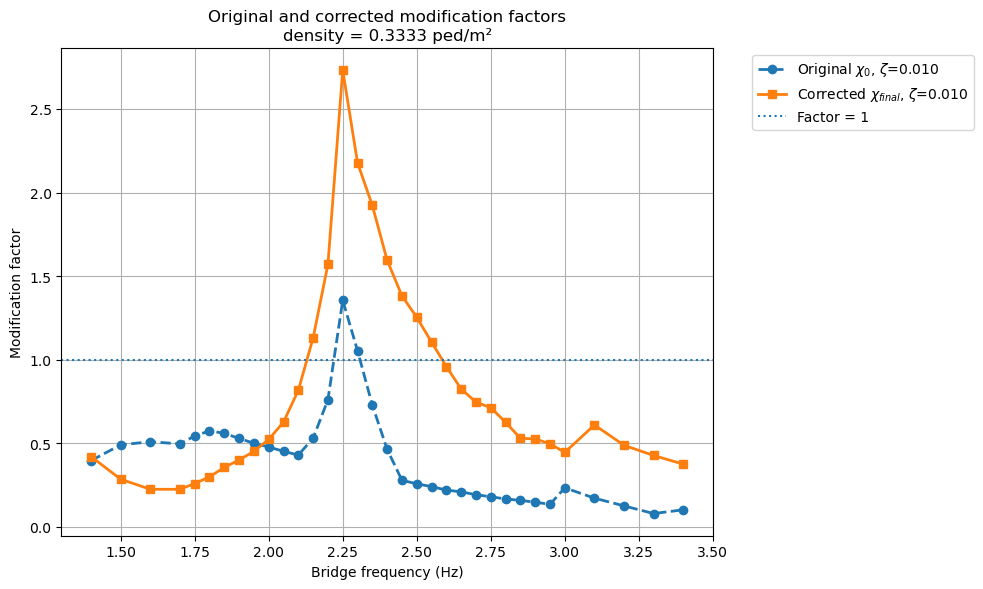

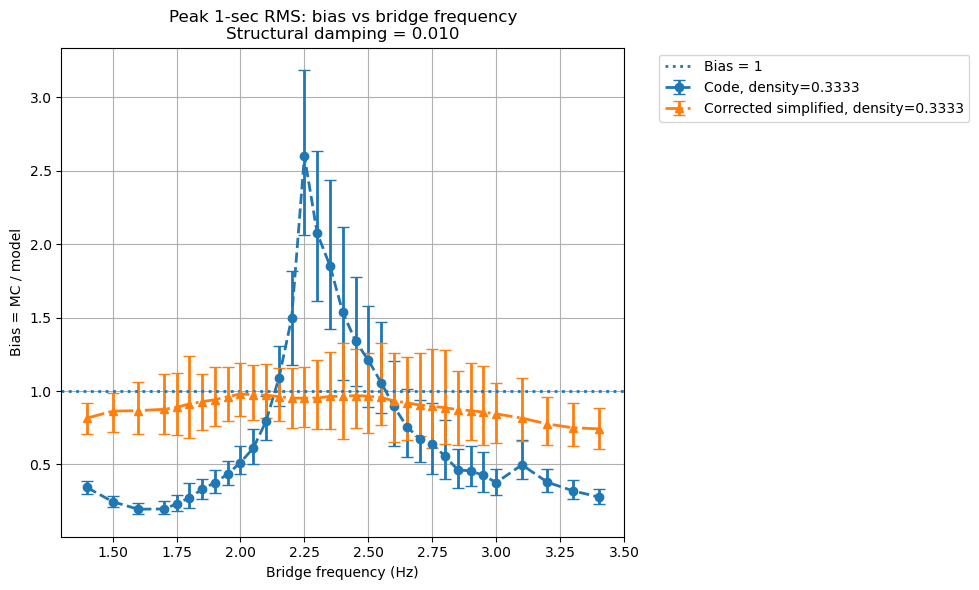

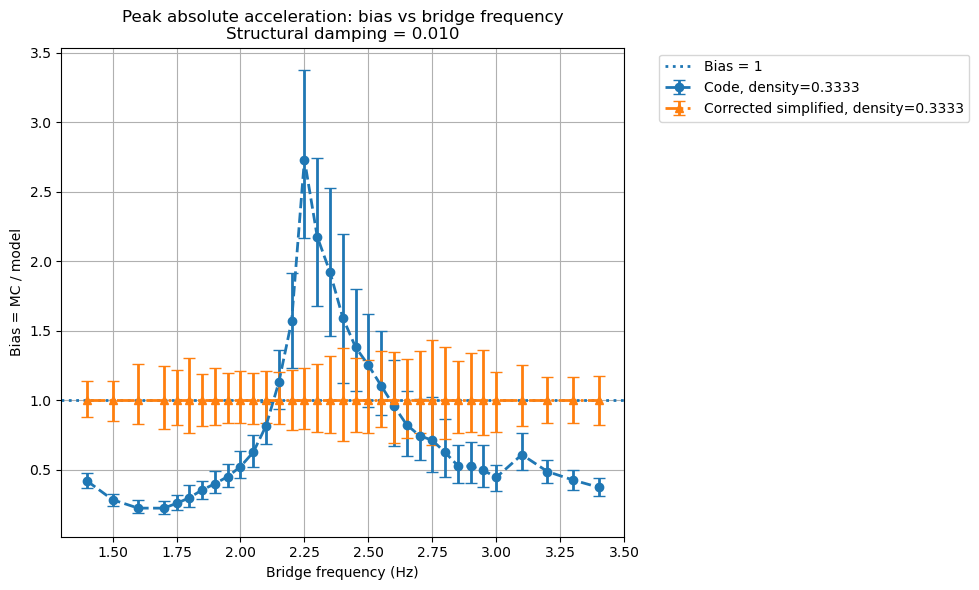

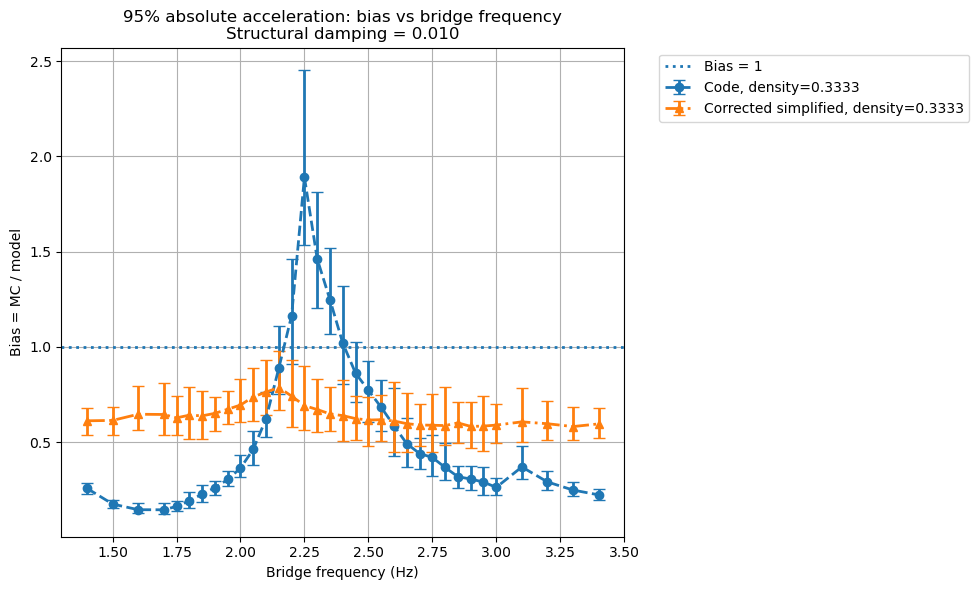

In [44]:
# ==================================================
# MULTI-FREQUENCY + MULTI-DAMPING MC + CODE + CORRECTED SIMPLIFIED SUMMARY
# Outputs:
#   1. original vs corrected modification factor plots
#   2. bias error bars for 3 response measures
# ==================================================

import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import torch
torch.set_num_threads(1)

import numpy as np
import matplotlib.pyplot as plt
import multiprocessing as mp
import pickle
import pandas as pd

from bias import run_simulation

from biascodefunction import (
    peak_rms_distribution,
    percentile_acc_distribution,
    peak_abs_acc_distribution,
    run_code_response_from_mc_inputs,
    interpolate_modification_factor_banded,
    running_mean_sd_1d,
    running_instantaneous_acc_stats
)


# --------------------------------------------------
# USER SETTINGS
# --------------------------------------------------
NUM_SIMULATIONS = 50
NUM_PROCESSES = 12

hht = 0.01
steady_start_time = 10.0
linear_mass = 500.0

peddamp = 0.30
pedBodyF = 3.10

Length = 50.0
Width = 2.0

# Multiple damping ratios
target_beamdamp_values = [0.010]

bridge_frequencies_to_run = [
    1.4, 1.5, 1.6, 1.7, 1.75, 1.8, 1.85, 1.9, 1.95, 2.0, 2.05, 2.1, 2.15, 2.2, 2.25, 2.3, 2.35, 2.4, 2.45, 2.5, 2.55, 2.6, 2.65, 2.7,
    2.75, 2.8, 2.85, 2.9, 2.95, 3.0, 3.1, 3.2, 3.3, 3.4
]

densities_to_run = [0.3333]

eps = 1e-12

# --------------------------------------------------
# Bias-correction settings
# --------------------------------------------------
CALIBRATION_MEASURE = "Peak absolute acceleration"
CORRECTION_STAT = "mean"      # options: "mean", "median", "p95"

# --------------------------------------------------
# Modification-factor database
# --------------------------------------------------
FORCE_FACTOR_FILE = "NMFR_2.pkl"

# Mass-ratio cap for interpolation database
MR_MIN_DATABASE = 0.0089
MR_MIN_USED = 0.0090
MR_MAX_DATABASE = 0.2954
MR_MAX_USED = 0.29


# --------------------------------------------------
# Helper: cap MC mass ratio inside interpolation range
# --------------------------------------------------
def cap_mass_ratio_for_interpolation(mc_mass_ratio):
    mc_mass_ratio = float(mc_mass_ratio)

    if mc_mass_ratio < MR_MIN_DATABASE:
        return MR_MIN_USED
    elif mc_mass_ratio > MR_MAX_DATABASE:
        return MR_MAX_USED
    else:
        return mc_mass_ratio


# --------------------------------------------------
# Response measures
# --------------------------------------------------
measure_specs = {
    "Peak 1-sec RMS": {
        "mc_key": "peak_rms",
        "code_key": "peak_1sec_rms",
    },
    "Peak absolute acceleration": {
        "mc_key": "peak_abs",
        "code_key": "peak_abs_acc",
    },
    "95% absolute acceleration": {
        "mc_key": "p95_abs",
        "code_key": "p95_abs_acc",
    },
}


# ==================================================
# MAIN LOOP
# ==================================================
if __name__ == "__main__":

    try:
        mp.set_start_method("spawn")
    except RuntimeError:
        pass

    # --------------------------------------------------
    # Load modification-factor database inside main block
    # --------------------------------------------------
    with open(FORCE_FACTOR_FILE, "rb") as f:
        ff_data = pickle.load(f)

    ff_results_all = ff_data["results_all"]
    ff_densities = ff_data["densities"]
    ff_damping_values = ff_data["damping_values"]
    ff_pedBodyF = ff_data["pedBodyF"]

    ff_bands_to_combine = list(ff_results_all.keys())

    print("Loaded NEW modification-factor database.")
    print("Available bands:", ff_bands_to_combine)
    print("Available damping values:", ff_damping_values)
    print("Available densities:", ff_densities)

    # Optional safety check
    test_band = ff_bands_to_combine[0]
    test_damp = ff_damping_values[0]
    test_bf = sorted(ff_results_all[test_band][test_damp].keys())[0]
    test_density = ff_densities[0]
    test_keys = ff_results_all[test_band][test_damp][test_bf][test_density].keys()

    print("\nDatabase check")
    print("--------------")
    print("Test band:", test_band)
    print("Test damping:", test_damp)
    print("Test bridge frequency:", test_bf)
    print("Test density:", test_density)
    print("Available keys:", test_keys)

    if "modification_factor" not in test_keys:
        raise KeyError("The database does not contain 'modification_factor'.")

    ctx = mp.get_context("spawn")
    rng = np.random.default_rng(12345)

    summary_rows = []
    convergence_rows = []

    with ctx.Pool(processes=NUM_PROCESSES) as pool:

        for target_beamdamp in target_beamdamp_values:

            print("\n" + "#" * 90)
            print(f"RUNNING STRUCTURAL DAMPING = {target_beamdamp:.4f}")
            print("#" * 90)

            for target_bf in bridge_frequencies_to_run:

                print("\n" + "=" * 80)
                print(f"RUNNING BRIDGE FREQUENCY = {target_bf:.3f} Hz")
                print("=" * 80)

                BeamFreq = np.array([target_bf, 4.0 * target_bf])
                Beamdamp = np.array([target_beamdamp])

                for density in densities_to_run:

                    print("\n" + "-" * 70)
                    print(f"Running density = {density:.4f}")
                    print("-" * 70)

                    # --------------------------------------------------
                    # Convert density to integer pedestrian counts
                    # --------------------------------------------------
                    total_peds_float = density * Length * Width
                    total_peds_int = int(round(total_peds_float))
                    total_peds_int = max(1, total_peds_int)

                    Tocity = total_peds_int // 2
                    Outcity = total_peds_int - Tocity

                    actual_density = (Tocity + Outcity) / (Length * Width)

                    print(f"Target density   = {density:.4f}")
                    print(f"Actual density   = {actual_density:.4f}")
                    print(f"Total peds       = {total_peds_int}")
                    print(f"Tocity, Outcity  = {Tocity}, {Outcity}")

                    # --------------------------------------------------
                    # Run MC reference simulations
                    # --------------------------------------------------
                    seeds = rng.integers(0, 2**31 - 1, size=NUM_SIMULATIONS)

                    args_list = [
                        (
                            int(seeds[i]),
                            peddamp,
                            pedBodyF,
                            BeamFreq,
                            Beamdamp,
                            Tocity,
                            Outcity,
                            Length,
                            Width
                        )
                        for i in range(NUM_SIMULATIONS)
                    ]

                    results = pool.map(run_simulation, args_list)

                    # --------------------------------------------------
                    # Extract MC acceleration histories and mass ratios
                    # --------------------------------------------------
                    accelerations = np.array([r[0] for r in results])
                    mean_mass_ratios = np.array([r[1] for r in results])

                    overall_mean_mass_ratio = np.mean(mean_mass_ratios)

                    print(f"MC acceleration shape       = {accelerations.shape}")
                    print(f"Mean modal mass ratio       = {overall_mean_mass_ratio:.6f}")

                    # --------------------------------------------------
                    # Remove initial transient
                    # --------------------------------------------------
                    steady_start_idx = int(round(steady_start_time / hht))

                    if steady_start_idx >= accelerations.shape[1]:
                        raise ValueError(
                            "steady_start_time is longer than acceleration time history."
                        )

                    accelerations_ss = accelerations[:, steady_start_idx:]

                    # --------------------------------------------------
                    # MC response distributions
                    # --------------------------------------------------
                    rms_histories, peak_rms_values = peak_rms_distribution(
                        accelerations_ss,
                        dt=hht,
                        window_sec=1.0
                    )

                    peak_abs_values = peak_abs_acc_distribution(
                        accelerations_ss
                    )

                    p95_abs_values = percentile_acc_distribution(
                        accelerations_ss,
                        percentile=95,
                        use_abs=True
                    )

                    mc_values = {
                        "peak_rms": peak_rms_values,
                        "peak_abs": peak_abs_values,
                        "p95_abs": p95_abs_values,
                    }

                    # ==================================================
                    # CONVERGENCE STATISTICS
                    # Instantaneous acceleration + response measures
                    # ==================================================

                    # --------------------------------------------------
                    # A) Instantaneous acceleration convergence
                    # --------------------------------------------------
                    sim_numbers_inst, inst_running_mean, inst_running_sd = (
                        running_instantaneous_acc_stats(accelerations_ss)
                    )

                    all_acc_values = accelerations_ss.reshape(-1)

                    inst_final_mean = np.mean(all_acc_values)
                    inst_final_sd = np.std(all_acc_values, ddof=1)

                    for i, n_sim in enumerate(sim_numbers_inst):

                        convergence_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "quantity": "Instantaneous acceleration",
                            "sim_number": int(n_sim),

                            "running_mean": inst_running_mean[i],
                            "running_sd": inst_running_sd[i],
                            "mean_abs_error": abs(inst_running_mean[i] - inst_final_mean),
                            "sd_abs_error": abs(inst_running_sd[i] - inst_final_sd),
                        })


                    # --------------------------------------------------
                    # B) Response-measure convergence
                    # --------------------------------------------------
                    for measure_name, spec in measure_specs.items():

                        measure_values = np.asarray(mc_values[spec["mc_key"]], dtype=float)
                        measure_values = measure_values[np.isfinite(measure_values)]

                        sim_numbers_m, measure_running_mean, measure_running_sd = (
                            running_mean_sd_1d(measure_values)
                        )

                        measure_final_mean = np.mean(measure_values)
                        measure_final_sd = np.std(measure_values, ddof=1)

                        for i, n_sim in enumerate(sim_numbers_m):

                            convergence_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "mean_modal_mass_ratio": overall_mean_mass_ratio,

                            "quantity": measure_name,
                            "sim_number": int(n_sim),

                            "running_mean": measure_running_mean[i],
                            "running_sd": measure_running_sd[i],

                            "mean_abs_error": abs(measure_running_mean[i] - measure_final_mean),
                            "sd_abs_error": abs(measure_running_sd[i] - measure_final_sd),
                        })

                    print("Convergence statistics stored for this case.")
                    # --------------------------------------------------
                    # Original deterministic/code model
                    # --------------------------------------------------
                    t_end = accelerations.shape[1] * hht

                    code_result, code_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=1.0
                    )

                    # --------------------------------------------------
                    # Interpolate original modification factor chi_0
                    # --------------------------------------------------
                    target_mass_ratio_used = cap_mass_ratio_for_interpolation(
                        overall_mean_mass_ratio
                    )

                    x_factor, interp_details = interpolate_modification_factor_banded(
                        results_all=ff_results_all,
                        target_bf=target_bf,
                        target_beamdamp=target_beamdamp,
                        target_mass_ratio=target_mass_ratio_used,
                        damping_values=ff_damping_values,
                        densities=ff_densities,
                        bands_to_combine=ff_bands_to_combine,
                        factor_key="modification_factor"
                    )

                    force_reduction_factor_used = x_factor

                    print("\nModification-factor interpolation")
                    print("---------------------------------")
                    print(f"Target bf                        = {target_bf:.6f}")
                    print(f"Target damping                   = {target_beamdamp:.6f}")
                    print(f"MC mean modal mass ratio          = {overall_mean_mass_ratio:.6f}")
                    print(f"Mass ratio used in interpolation  = {target_mass_ratio_used:.6f}")
                    print(f"Interpolated factor chi_0         = {x_factor:.6f}")

                    # --------------------------------------------------
                    # Simplified deterministic model using chi_0
                    # --------------------------------------------------
                    simplified_result, simplified_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=force_reduction_factor_used
                    )

                    # --------------------------------------------------
                    # Residual correction factor lambda
                    # --------------------------------------------------
                    cal_spec = measure_specs[CALIBRATION_MEASURE]

                    Y_cal = np.asarray(mc_values[cal_spec["mc_key"]], dtype=float)
                    Y_cal = Y_cal[np.isfinite(Y_cal)]

                    simp_val_cal = simplified_measures[cal_spec["code_key"]]

                    B_simp_cal = Y_cal / max(simp_val_cal, eps)

                    if CORRECTION_STAT == "mean":
                        residual_correction_factor = np.mean(B_simp_cal)

                    elif CORRECTION_STAT == "median":
                        residual_correction_factor = np.percentile(B_simp_cal, 50)

                    elif CORRECTION_STAT == "p95":
                        residual_correction_factor = np.percentile(B_simp_cal, 95)

                    else:
                        raise ValueError(
                            "CORRECTION_STAT must be 'mean', 'median', or 'p95'."
                        )

                    final_modification_factor = x_factor * residual_correction_factor

                    print("\nResidual bias correction")
                    print("------------------------")
                    print(f"Calibration measure        = {CALIBRATION_MEASURE}")
                    print(f"Correction statistic       = {CORRECTION_STAT}")
                    print(f"Initial factor chi_0        = {x_factor:.6f}")
                    print(f"Residual correction lambda  = {residual_correction_factor:.6f}")
                    print(f"Final factor chi_final      = {final_modification_factor:.6f}")

                    # --------------------------------------------------
                    # Corrected simplified deterministic model
                    # --------------------------------------------------
                    corrected_result, corrected_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=final_modification_factor
                    )

                    # --------------------------------------------------
                    # Bias distributions for all 3 measures
                    # --------------------------------------------------
                    for measure_name, spec in measure_specs.items():

                        Y_ref = np.asarray(mc_values[spec["mc_key"]], dtype=float)
                        Y_ref = Y_ref[np.isfinite(Y_ref)]

                        code_val = code_measures[spec["code_key"]]
                        simp_val = simplified_measures[spec["code_key"]]
                        corr_val = corrected_measures[spec["code_key"]]

                        B_code = Y_ref / max(code_val, eps)
                        B_simp = Y_ref / max(simp_val, eps)
                        B_corr = Y_ref / max(corr_val, eps)

                        summary_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "actual_density": actual_density,
                            "total_peds": total_peds_int,
                            "Tocity": Tocity,
                            "Outcity": Outcity,

                            "mean_modal_mass_ratio": overall_mean_mass_ratio,
                            "mass_ratio_used_for_interpolation": target_mass_ratio_used,

                            "initial_modification_factor": x_factor,
                            "residual_correction_factor": residual_correction_factor,
                            "final_modification_factor": final_modification_factor,

                            "calibration_measure": CALIBRATION_MEASURE,
                            "correction_stat": CORRECTION_STAT,

                            "measure": measure_name,

                            "mc_mean": np.mean(Y_ref),
                            "mc_p5": np.percentile(Y_ref, 5),
                            "mc_p50": np.percentile(Y_ref, 50),
                            "mc_p95": np.percentile(Y_ref, 95),

                            "code_prediction": code_val,
                            "simplified_prediction": simp_val,
                            "corrected_prediction": corr_val,

                            "code_bias_mean": np.mean(B_code),
                            "code_bias_p5": np.percentile(B_code, 5),
                            "code_bias_p50": np.percentile(B_code, 50),
                            "code_bias_p95": np.percentile(B_code, 95),

                            "simplified_bias_mean": np.mean(B_simp),
                            "simplified_bias_p5": np.percentile(B_simp, 5),
                            "simplified_bias_p50": np.percentile(B_simp, 50),
                            "simplified_bias_p95": np.percentile(B_simp, 95),

                            "corrected_bias_mean": np.mean(B_corr),
                            "corrected_bias_p5": np.percentile(B_corr, 5),
                            "corrected_bias_p50": np.percentile(B_corr, 50),
                            "corrected_bias_p95": np.percentile(B_corr, 95),
                        })

                        print(f"\n{measure_name}")
                        print(f"  MC mean                   = {np.mean(Y_ref):.6f}")
                        print(f"  Code prediction           = {code_val:.6f}")
                        print(f"  Simplified prediction     = {simp_val:.6f}")
                        print(f"  Corrected prediction      = {corr_val:.6f}")
                        print(f"  Code mean bias            = {np.mean(B_code):.6f}")
                        print(f"  Simplified mean bias      = {np.mean(B_simp):.6f}")
                        print(f"  Corrected simplified bias = {np.mean(B_corr):.6f}")

    # ==================================================
    # SAVE SUMMARY
    # ==================================================
    summary_df = pd.DataFrame(summary_rows)
    convergence_df = pd.DataFrame(convergence_rows)

    summary_pkl = "density0.3333_damping0.010_bias_summary.pkl"
    #convergence_pkl = "density0.3333_damping0.010_convergence_summary.pkl"

    with open(summary_pkl, "wb") as f:
        pickle.dump(summary_df, f, protocol=pickle.HIGHEST_PROTOCOL)

    #with open(convergence_pkl, "wb") as f:
        #pickle.dump(convergence_df, f, protocol=pickle.HIGHEST_PROTOCOL)

    print("\nSaved summary files:")
    print(summary_pkl)
    #print(convergence_pkl)

    # ==================================================
    # PLOT 1: ORIGINAL vs CORRECTED MODIFICATION FACTOR
    # One plot per density, all damping ratios included
    # ==================================================
    factor_df = summary_df.drop_duplicates(
        subset=["bridge_frequency", "target_density", "target_beamdamp"]
    ).copy()

    for density in densities_to_run:

        plt.figure(figsize=(10, 6))

        for target_beamdamp in target_beamdamp_values:

            sub = factor_df[
                (factor_df["target_density"] == density) &
                (factor_df["target_beamdamp"] == target_beamdamp)
            ].copy()

            sub = sub.sort_values("bridge_frequency")

            plt.plot(
                sub["bridge_frequency"],
                sub["initial_modification_factor"],
                marker="o",
                linestyle="--",
                linewidth=2,
                label=rf"Original $\chi_0$, $\zeta$={target_beamdamp:.3f}"
            )

            plt.plot(
                sub["bridge_frequency"],
                sub["final_modification_factor"],
                marker="s",
                linestyle="-",
                linewidth=2,
                label=rf"Corrected $\chi_{{final}}$, $\zeta$={target_beamdamp:.3f}"
            )

        plt.axhline(
            1.0,
            linestyle=":",
            linewidth=1.5,
            label="Factor = 1"
        )

        plt.xlabel("Bridge frequency (Hz)")
        plt.ylabel("Modification factor")
        plt.title(
            f"Original and corrected modification factors\n"
            f"density = {density:.4f} ped/m²"
        )

        plt.grid(True)
        plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.tight_layout()
        plt.show()

    # ==================================================
    # PLOTS 2-4: ERROR BARS FOR EACH RESPONSE MEASURE
    # One plot per vibration measure and damping ratio
    # Only Code and Corrected Simplified are plotted
    # ==================================================
    for target_beamdamp in target_beamdamp_values:

        for measure_name in measure_specs.keys():

            plt.figure(figsize=(10, 6))

            for density in densities_to_run:

                sub = summary_df[
                    (summary_df["target_beamdamp"] == target_beamdamp) &
                    (summary_df["target_density"] == density) &
                    (summary_df["measure"] == measure_name)
                ].copy()

                sub = sub.sort_values("bridge_frequency")

                x = sub["bridge_frequency"].values

                # -----------------------------
                # Original code bias
                # -----------------------------
                y_code = sub["code_bias_mean"].values
                y_code_p5 = sub["code_bias_p5"].values
                y_code_p95 = sub["code_bias_p95"].values

                yerr_code = np.vstack([
                    y_code - y_code_p5,
                    y_code_p95 - y_code
                ])

                plt.errorbar(
                    x,
                    y_code,
                    yerr=yerr_code,
                    marker="o",
                    linestyle="--",
                    linewidth=2,
                    capsize=4,
                    label=f"Code, density={density:.4f}"
                )

                # -----------------------------
                # Corrected simplified model bias
                # -----------------------------
                y_corr = sub["corrected_bias_mean"].values
                y_corr_p5 = sub["corrected_bias_p5"].values
                y_corr_p95 = sub["corrected_bias_p95"].values

                yerr_corr = np.vstack([
                    y_corr - y_corr_p5,
                    y_corr_p95 - y_corr
                ])

                plt.errorbar(
                    x,
                    y_corr,
                    yerr=yerr_corr,
                    marker="^",
                    linestyle="-.",
                    linewidth=2,
                    capsize=4,
                    label=f"Corrected simplified, density={density:.4f}"
                )

            plt.axhline(
                1.0,
                linestyle=":",
                linewidth=2,
                label="Bias = 1"
            )

            plt.xlabel("Bridge frequency (Hz)")
            plt.ylabel("Bias = MC / model")
            plt.title(
                f"{measure_name}: bias vs bridge frequency\n"
                f"Structural damping = {target_beamdamp:.3f}"
            )

            plt.grid(True)
            plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
            plt.tight_layout()
            plt.show()



Loaded NEW modification-factor database.
Available bands: ['1.25_to_4.60']
Available damping values: [0.005, 0.01, 0.015, 0.02, 0.025, 0.03]
Available densities: [0.0333, 0.1667, 0.3333, 0.5, 0.6667, 0.8333, 1.0]

Database check
--------------
Test band: 1.25_to_4.60
Test damping: 0.005
Test bridge frequency: 1.25
Test density: 0.0333
Available keys: dict_keys(['t', 'modalpedmass_i', 'modification_factor', 'frf_ratio', 'psi_ratio', 'psi_ratio_valid', 'f_eff_peak', 'f0_peak'])

##########################################################################################
RUNNING STRUCTURAL DAMPING = 0.0100
##########################################################################################

RUNNING BRIDGE FREQUENCY = 1.400 Hz

----------------------------------------------------------------------
Running density = 0.5000
----------------------------------------------------------------------
Target density   = 0.5000
Actual density   = 0.5000
Total peds       = 50
Tocity, Outcity  = 25

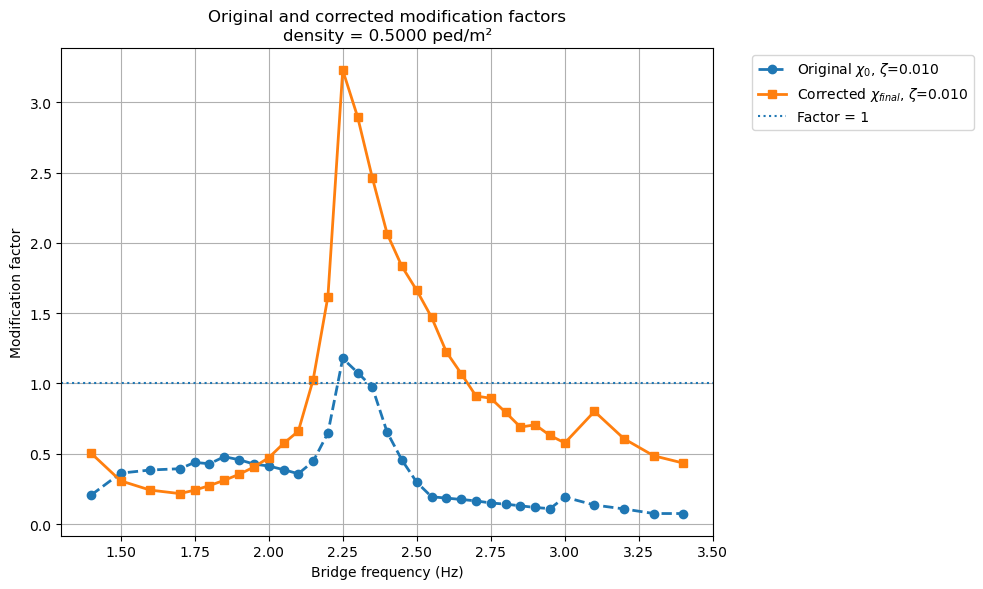

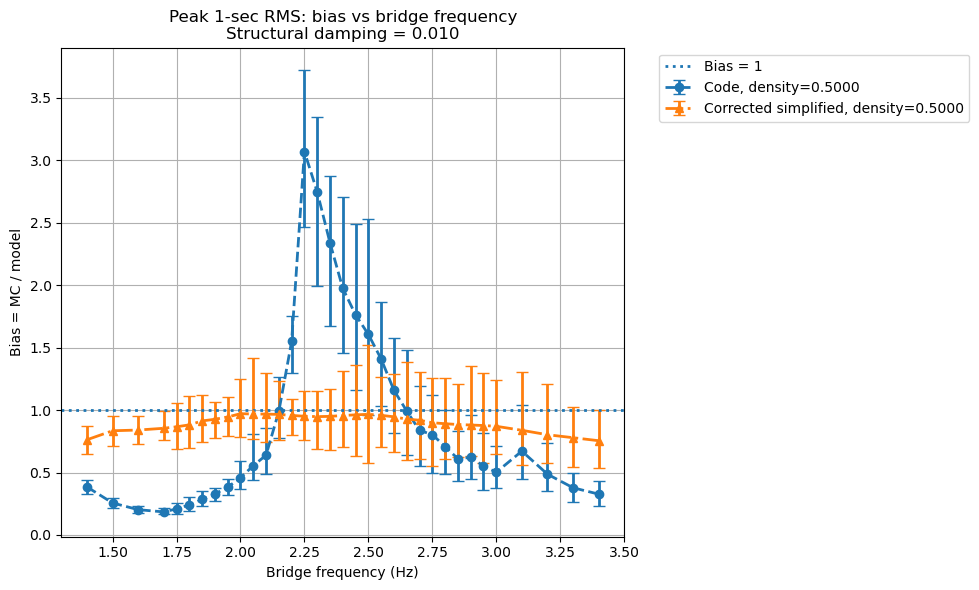

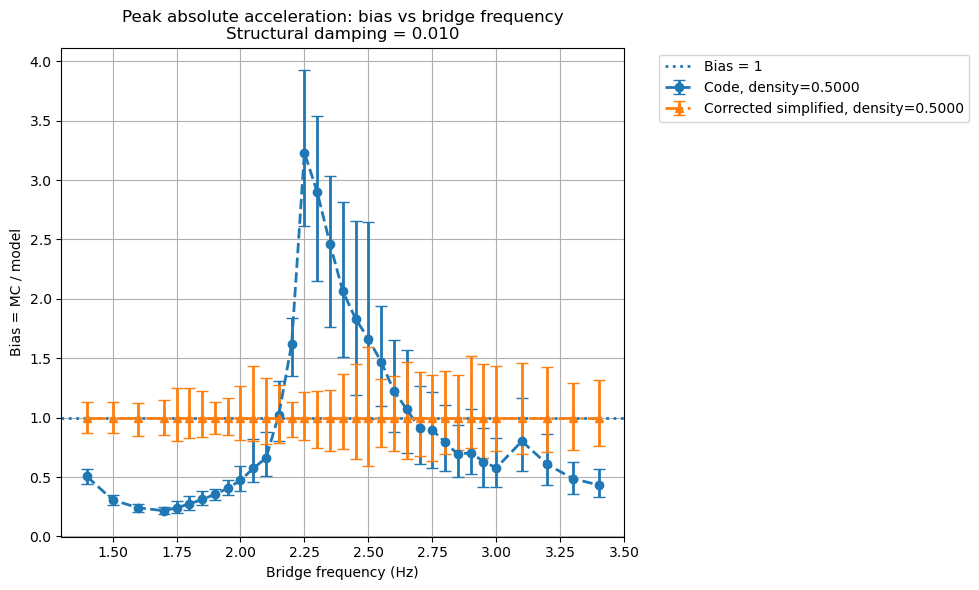

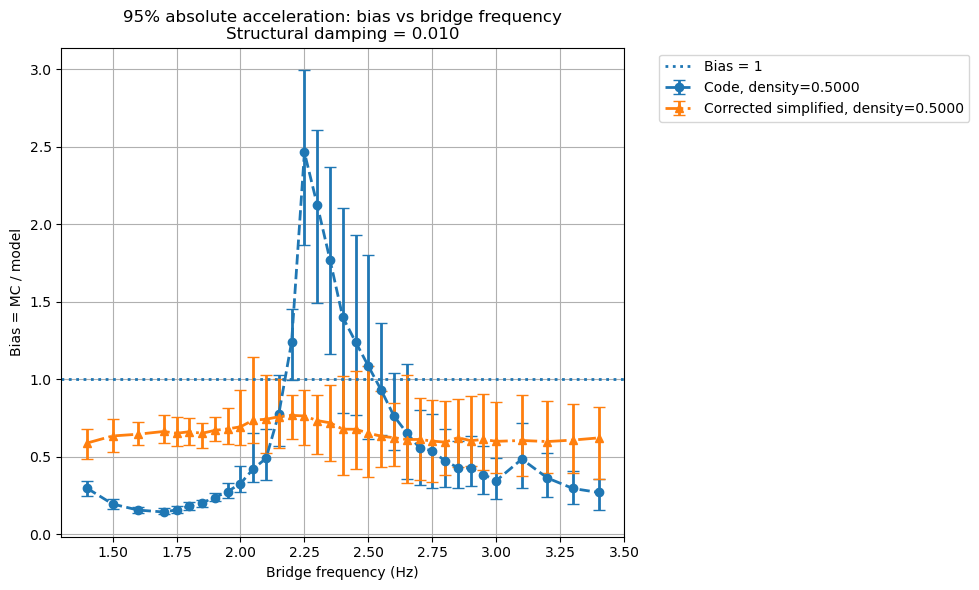

In [45]:
# ==================================================
# MULTI-FREQUENCY + MULTI-DAMPING MC + CODE + CORRECTED SIMPLIFIED SUMMARY
# Outputs:
#   1. original vs corrected modification factor plots
#   2. bias error bars for 3 response measures
# ==================================================

import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import torch
torch.set_num_threads(1)

import numpy as np
import matplotlib.pyplot as plt
import multiprocessing as mp
import pickle
import pandas as pd

from bias import run_simulation

from biascodefunction import (
    peak_rms_distribution,
    percentile_acc_distribution,
    peak_abs_acc_distribution,
    run_code_response_from_mc_inputs,
    interpolate_modification_factor_banded,
    running_mean_sd_1d,
    running_instantaneous_acc_stats
)


# --------------------------------------------------
# USER SETTINGS
# --------------------------------------------------
NUM_SIMULATIONS = 50
NUM_PROCESSES = 12

hht = 0.01
steady_start_time = 10.0
linear_mass = 500.0

peddamp = 0.30
pedBodyF = 3.10

Length = 50.0
Width = 2.0

# Multiple damping ratios
target_beamdamp_values = [0.010]

bridge_frequencies_to_run = [
    1.4, 1.5, 1.6, 1.7, 1.75, 1.8, 1.85, 1.9, 1.95, 2.0, 2.05, 2.1, 2.15, 2.2, 2.25, 2.3, 2.35, 2.4, 2.45, 2.5, 2.55, 2.6, 2.65, 2.7,
    2.75, 2.8, 2.85, 2.9, 2.95, 3.0, 3.1, 3.2, 3.3, 3.4
]

densities_to_run = [0.5000]

eps = 1e-12

# --------------------------------------------------
# Bias-correction settings
# --------------------------------------------------
CALIBRATION_MEASURE = "Peak absolute acceleration"
CORRECTION_STAT = "mean"      # options: "mean", "median", "p95"

# --------------------------------------------------
# Modification-factor database
# --------------------------------------------------
FORCE_FACTOR_FILE = "NMFR_2.pkl"

# Mass-ratio cap for interpolation database
MR_MIN_DATABASE = 0.0089
MR_MIN_USED = 0.0090
MR_MAX_DATABASE = 0.2954
MR_MAX_USED = 0.29


# --------------------------------------------------
# Helper: cap MC mass ratio inside interpolation range
# --------------------------------------------------
def cap_mass_ratio_for_interpolation(mc_mass_ratio):
    mc_mass_ratio = float(mc_mass_ratio)

    if mc_mass_ratio < MR_MIN_DATABASE:
        return MR_MIN_USED
    elif mc_mass_ratio > MR_MAX_DATABASE:
        return MR_MAX_USED
    else:
        return mc_mass_ratio


# --------------------------------------------------
# Response measures
# --------------------------------------------------
measure_specs = {
    "Peak 1-sec RMS": {
        "mc_key": "peak_rms",
        "code_key": "peak_1sec_rms",
    },
    "Peak absolute acceleration": {
        "mc_key": "peak_abs",
        "code_key": "peak_abs_acc",
    },
    "95% absolute acceleration": {
        "mc_key": "p95_abs",
        "code_key": "p95_abs_acc",
    },
}


# ==================================================
# MAIN LOOP
# ==================================================
if __name__ == "__main__":

    try:
        mp.set_start_method("spawn")
    except RuntimeError:
        pass

    # --------------------------------------------------
    # Load modification-factor database inside main block
    # --------------------------------------------------
    with open(FORCE_FACTOR_FILE, "rb") as f:
        ff_data = pickle.load(f)

    ff_results_all = ff_data["results_all"]
    ff_densities = ff_data["densities"]
    ff_damping_values = ff_data["damping_values"]
    ff_pedBodyF = ff_data["pedBodyF"]

    ff_bands_to_combine = list(ff_results_all.keys())

    print("Loaded NEW modification-factor database.")
    print("Available bands:", ff_bands_to_combine)
    print("Available damping values:", ff_damping_values)
    print("Available densities:", ff_densities)

    # Optional safety check
    test_band = ff_bands_to_combine[0]
    test_damp = ff_damping_values[0]
    test_bf = sorted(ff_results_all[test_band][test_damp].keys())[0]
    test_density = ff_densities[0]
    test_keys = ff_results_all[test_band][test_damp][test_bf][test_density].keys()

    print("\nDatabase check")
    print("--------------")
    print("Test band:", test_band)
    print("Test damping:", test_damp)
    print("Test bridge frequency:", test_bf)
    print("Test density:", test_density)
    print("Available keys:", test_keys)

    if "modification_factor" not in test_keys:
        raise KeyError("The database does not contain 'modification_factor'.")

    ctx = mp.get_context("spawn")
    rng = np.random.default_rng(12345)

    summary_rows = []
    convergence_rows = []

    with ctx.Pool(processes=NUM_PROCESSES) as pool:

        for target_beamdamp in target_beamdamp_values:

            print("\n" + "#" * 90)
            print(f"RUNNING STRUCTURAL DAMPING = {target_beamdamp:.4f}")
            print("#" * 90)

            for target_bf in bridge_frequencies_to_run:

                print("\n" + "=" * 80)
                print(f"RUNNING BRIDGE FREQUENCY = {target_bf:.3f} Hz")
                print("=" * 80)

                BeamFreq = np.array([target_bf, 4.0 * target_bf])
                Beamdamp = np.array([target_beamdamp])

                for density in densities_to_run:

                    print("\n" + "-" * 70)
                    print(f"Running density = {density:.4f}")
                    print("-" * 70)

                    # --------------------------------------------------
                    # Convert density to integer pedestrian counts
                    # --------------------------------------------------
                    total_peds_float = density * Length * Width
                    total_peds_int = int(round(total_peds_float))
                    total_peds_int = max(1, total_peds_int)

                    Tocity = total_peds_int // 2
                    Outcity = total_peds_int - Tocity

                    actual_density = (Tocity + Outcity) / (Length * Width)

                    print(f"Target density   = {density:.4f}")
                    print(f"Actual density   = {actual_density:.4f}")
                    print(f"Total peds       = {total_peds_int}")
                    print(f"Tocity, Outcity  = {Tocity}, {Outcity}")

                    # --------------------------------------------------
                    # Run MC reference simulations
                    # --------------------------------------------------
                    seeds = rng.integers(0, 2**31 - 1, size=NUM_SIMULATIONS)

                    args_list = [
                        (
                            int(seeds[i]),
                            peddamp,
                            pedBodyF,
                            BeamFreq,
                            Beamdamp,
                            Tocity,
                            Outcity,
                            Length,
                            Width
                        )
                        for i in range(NUM_SIMULATIONS)
                    ]

                    results = pool.map(run_simulation, args_list)

                    # --------------------------------------------------
                    # Extract MC acceleration histories and mass ratios
                    # --------------------------------------------------
                    accelerations = np.array([r[0] for r in results])
                    mean_mass_ratios = np.array([r[1] for r in results])

                    overall_mean_mass_ratio = np.mean(mean_mass_ratios)

                    print(f"MC acceleration shape       = {accelerations.shape}")
                    print(f"Mean modal mass ratio       = {overall_mean_mass_ratio:.6f}")

                    # --------------------------------------------------
                    # Remove initial transient
                    # --------------------------------------------------
                    steady_start_idx = int(round(steady_start_time / hht))

                    if steady_start_idx >= accelerations.shape[1]:
                        raise ValueError(
                            "steady_start_time is longer than acceleration time history."
                        )

                    accelerations_ss = accelerations[:, steady_start_idx:]

                    # --------------------------------------------------
                    # MC response distributions
                    # --------------------------------------------------
                    rms_histories, peak_rms_values = peak_rms_distribution(
                        accelerations_ss,
                        dt=hht,
                        window_sec=1.0
                    )

                    peak_abs_values = peak_abs_acc_distribution(
                        accelerations_ss
                    )

                    p95_abs_values = percentile_acc_distribution(
                        accelerations_ss,
                        percentile=95,
                        use_abs=True
                    )

                    mc_values = {
                        "peak_rms": peak_rms_values,
                        "peak_abs": peak_abs_values,
                        "p95_abs": p95_abs_values,
                    }

                    # ==================================================
                    # CONVERGENCE STATISTICS
                    # Instantaneous acceleration + response measures
                    # ==================================================

                    # --------------------------------------------------
                    # A) Instantaneous acceleration convergence
                    # --------------------------------------------------
                    sim_numbers_inst, inst_running_mean, inst_running_sd = (
                        running_instantaneous_acc_stats(accelerations_ss)
                    )

                    all_acc_values = accelerations_ss.reshape(-1)

                    inst_final_mean = np.mean(all_acc_values)
                    inst_final_sd = np.std(all_acc_values, ddof=1)

                    for i, n_sim in enumerate(sim_numbers_inst):

                        convergence_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "quantity": "Instantaneous acceleration",
                            "sim_number": int(n_sim),

                            "running_mean": inst_running_mean[i],
                            "running_sd": inst_running_sd[i],
                            "mean_abs_error": abs(inst_running_mean[i] - inst_final_mean),
                            "sd_abs_error": abs(inst_running_sd[i] - inst_final_sd),
                        })


                    # --------------------------------------------------
                    # B) Response-measure convergence
                    # --------------------------------------------------
                    for measure_name, spec in measure_specs.items():

                        measure_values = np.asarray(mc_values[spec["mc_key"]], dtype=float)
                        measure_values = measure_values[np.isfinite(measure_values)]

                        sim_numbers_m, measure_running_mean, measure_running_sd = (
                            running_mean_sd_1d(measure_values)
                        )

                        measure_final_mean = np.mean(measure_values)
                        measure_final_sd = np.std(measure_values, ddof=1)

                        for i, n_sim in enumerate(sim_numbers_m):

                            convergence_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "mean_modal_mass_ratio": overall_mean_mass_ratio,

                            "quantity": measure_name,
                            "sim_number": int(n_sim),

                            "running_mean": measure_running_mean[i],
                            "running_sd": measure_running_sd[i],

                            "mean_abs_error": abs(measure_running_mean[i] - measure_final_mean),
                            "sd_abs_error": abs(measure_running_sd[i] - measure_final_sd),
                        })

                    print("Convergence statistics stored for this case.")
                    # --------------------------------------------------
                    # Original deterministic/code model
                    # --------------------------------------------------
                    t_end = accelerations.shape[1] * hht

                    code_result, code_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=1.0
                    )

                    # --------------------------------------------------
                    # Interpolate original modification factor chi_0
                    # --------------------------------------------------
                    target_mass_ratio_used = cap_mass_ratio_for_interpolation(
                        overall_mean_mass_ratio
                    )

                    x_factor, interp_details = interpolate_modification_factor_banded(
                        results_all=ff_results_all,
                        target_bf=target_bf,
                        target_beamdamp=target_beamdamp,
                        target_mass_ratio=target_mass_ratio_used,
                        damping_values=ff_damping_values,
                        densities=ff_densities,
                        bands_to_combine=ff_bands_to_combine,
                        factor_key="modification_factor"
                    )

                    force_reduction_factor_used = x_factor

                    print("\nModification-factor interpolation")
                    print("---------------------------------")
                    print(f"Target bf                        = {target_bf:.6f}")
                    print(f"Target damping                   = {target_beamdamp:.6f}")
                    print(f"MC mean modal mass ratio          = {overall_mean_mass_ratio:.6f}")
                    print(f"Mass ratio used in interpolation  = {target_mass_ratio_used:.6f}")
                    print(f"Interpolated factor chi_0         = {x_factor:.6f}")

                    # --------------------------------------------------
                    # Simplified deterministic model using chi_0
                    # --------------------------------------------------
                    simplified_result, simplified_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=force_reduction_factor_used
                    )

                    # --------------------------------------------------
                    # Residual correction factor lambda
                    # --------------------------------------------------
                    cal_spec = measure_specs[CALIBRATION_MEASURE]

                    Y_cal = np.asarray(mc_values[cal_spec["mc_key"]], dtype=float)
                    Y_cal = Y_cal[np.isfinite(Y_cal)]

                    simp_val_cal = simplified_measures[cal_spec["code_key"]]

                    B_simp_cal = Y_cal / max(simp_val_cal, eps)

                    if CORRECTION_STAT == "mean":
                        residual_correction_factor = np.mean(B_simp_cal)

                    elif CORRECTION_STAT == "median":
                        residual_correction_factor = np.percentile(B_simp_cal, 50)

                    elif CORRECTION_STAT == "p95":
                        residual_correction_factor = np.percentile(B_simp_cal, 95)

                    else:
                        raise ValueError(
                            "CORRECTION_STAT must be 'mean', 'median', or 'p95'."
                        )

                    final_modification_factor = x_factor * residual_correction_factor

                    print("\nResidual bias correction")
                    print("------------------------")
                    print(f"Calibration measure        = {CALIBRATION_MEASURE}")
                    print(f"Correction statistic       = {CORRECTION_STAT}")
                    print(f"Initial factor chi_0        = {x_factor:.6f}")
                    print(f"Residual correction lambda  = {residual_correction_factor:.6f}")
                    print(f"Final factor chi_final      = {final_modification_factor:.6f}")

                    # --------------------------------------------------
                    # Corrected simplified deterministic model
                    # --------------------------------------------------
                    corrected_result, corrected_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=final_modification_factor
                    )

                    # --------------------------------------------------
                    # Bias distributions for all 3 measures
                    # --------------------------------------------------
                    for measure_name, spec in measure_specs.items():

                        Y_ref = np.asarray(mc_values[spec["mc_key"]], dtype=float)
                        Y_ref = Y_ref[np.isfinite(Y_ref)]

                        code_val = code_measures[spec["code_key"]]
                        simp_val = simplified_measures[spec["code_key"]]
                        corr_val = corrected_measures[spec["code_key"]]

                        B_code = Y_ref / max(code_val, eps)
                        B_simp = Y_ref / max(simp_val, eps)
                        B_corr = Y_ref / max(corr_val, eps)

                        summary_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "actual_density": actual_density,
                            "total_peds": total_peds_int,
                            "Tocity": Tocity,
                            "Outcity": Outcity,

                            "mean_modal_mass_ratio": overall_mean_mass_ratio,
                            "mass_ratio_used_for_interpolation": target_mass_ratio_used,

                            "initial_modification_factor": x_factor,
                            "residual_correction_factor": residual_correction_factor,
                            "final_modification_factor": final_modification_factor,

                            "calibration_measure": CALIBRATION_MEASURE,
                            "correction_stat": CORRECTION_STAT,

                            "measure": measure_name,

                            "mc_mean": np.mean(Y_ref),
                            "mc_p5": np.percentile(Y_ref, 5),
                            "mc_p50": np.percentile(Y_ref, 50),
                            "mc_p95": np.percentile(Y_ref, 95),

                            "code_prediction": code_val,
                            "simplified_prediction": simp_val,
                            "corrected_prediction": corr_val,

                            "code_bias_mean": np.mean(B_code),
                            "code_bias_p5": np.percentile(B_code, 5),
                            "code_bias_p50": np.percentile(B_code, 50),
                            "code_bias_p95": np.percentile(B_code, 95),

                            "simplified_bias_mean": np.mean(B_simp),
                            "simplified_bias_p5": np.percentile(B_simp, 5),
                            "simplified_bias_p50": np.percentile(B_simp, 50),
                            "simplified_bias_p95": np.percentile(B_simp, 95),

                            "corrected_bias_mean": np.mean(B_corr),
                            "corrected_bias_p5": np.percentile(B_corr, 5),
                            "corrected_bias_p50": np.percentile(B_corr, 50),
                            "corrected_bias_p95": np.percentile(B_corr, 95),
                        })

                        print(f"\n{measure_name}")
                        print(f"  MC mean                   = {np.mean(Y_ref):.6f}")
                        print(f"  Code prediction           = {code_val:.6f}")
                        print(f"  Simplified prediction     = {simp_val:.6f}")
                        print(f"  Corrected prediction      = {corr_val:.6f}")
                        print(f"  Code mean bias            = {np.mean(B_code):.6f}")
                        print(f"  Simplified mean bias      = {np.mean(B_simp):.6f}")
                        print(f"  Corrected simplified bias = {np.mean(B_corr):.6f}")

    # ==================================================
    # SAVE SUMMARY
    # ==================================================
    summary_df = pd.DataFrame(summary_rows)
    convergence_df = pd.DataFrame(convergence_rows)

    summary_pkl = "density0.5000_damping0.010_bias_summary.pkl"
    #convergence_pkl = "density0.5000_damping0.010_convergence_summary.pkl"

    with open(summary_pkl, "wb") as f:
        pickle.dump(summary_df, f, protocol=pickle.HIGHEST_PROTOCOL)

    #with open(convergence_pkl, "wb") as f:
        #pickle.dump(convergence_df, f, protocol=pickle.HIGHEST_PROTOCOL)

    print("\nSaved summary files:")
    print(summary_pkl)
    #print(convergence_pkl)

    # ==================================================
    # PLOT 1: ORIGINAL vs CORRECTED MODIFICATION FACTOR
    # One plot per density, all damping ratios included
    # ==================================================
    factor_df = summary_df.drop_duplicates(
        subset=["bridge_frequency", "target_density", "target_beamdamp"]
    ).copy()

    for density in densities_to_run:

        plt.figure(figsize=(10, 6))

        for target_beamdamp in target_beamdamp_values:

            sub = factor_df[
                (factor_df["target_density"] == density) &
                (factor_df["target_beamdamp"] == target_beamdamp)
            ].copy()

            sub = sub.sort_values("bridge_frequency")

            plt.plot(
                sub["bridge_frequency"],
                sub["initial_modification_factor"],
                marker="o",
                linestyle="--",
                linewidth=2,
                label=rf"Original $\chi_0$, $\zeta$={target_beamdamp:.3f}"
            )

            plt.plot(
                sub["bridge_frequency"],
                sub["final_modification_factor"],
                marker="s",
                linestyle="-",
                linewidth=2,
                label=rf"Corrected $\chi_{{final}}$, $\zeta$={target_beamdamp:.3f}"
            )

        plt.axhline(
            1.0,
            linestyle=":",
            linewidth=1.5,
            label="Factor = 1"
        )

        plt.xlabel("Bridge frequency (Hz)")
        plt.ylabel("Modification factor")
        plt.title(
            f"Original and corrected modification factors\n"
            f"density = {density:.4f} ped/m²"
        )

        plt.grid(True)
        plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.tight_layout()
        plt.show()

    # ==================================================
    # PLOTS 2-4: ERROR BARS FOR EACH RESPONSE MEASURE
    # One plot per vibration measure and damping ratio
    # Only Code and Corrected Simplified are plotted
    # ==================================================
    for target_beamdamp in target_beamdamp_values:

        for measure_name in measure_specs.keys():

            plt.figure(figsize=(10, 6))

            for density in densities_to_run:

                sub = summary_df[
                    (summary_df["target_beamdamp"] == target_beamdamp) &
                    (summary_df["target_density"] == density) &
                    (summary_df["measure"] == measure_name)
                ].copy()

                sub = sub.sort_values("bridge_frequency")

                x = sub["bridge_frequency"].values

                # -----------------------------
                # Original code bias
                # -----------------------------
                y_code = sub["code_bias_mean"].values
                y_code_p5 = sub["code_bias_p5"].values
                y_code_p95 = sub["code_bias_p95"].values

                yerr_code = np.vstack([
                    y_code - y_code_p5,
                    y_code_p95 - y_code
                ])

                plt.errorbar(
                    x,
                    y_code,
                    yerr=yerr_code,
                    marker="o",
                    linestyle="--",
                    linewidth=2,
                    capsize=4,
                    label=f"Code, density={density:.4f}"
                )

                # -----------------------------
                # Corrected simplified model bias
                # -----------------------------
                y_corr = sub["corrected_bias_mean"].values
                y_corr_p5 = sub["corrected_bias_p5"].values
                y_corr_p95 = sub["corrected_bias_p95"].values

                yerr_corr = np.vstack([
                    y_corr - y_corr_p5,
                    y_corr_p95 - y_corr
                ])

                plt.errorbar(
                    x,
                    y_corr,
                    yerr=yerr_corr,
                    marker="^",
                    linestyle="-.",
                    linewidth=2,
                    capsize=4,
                    label=f"Corrected simplified, density={density:.4f}"
                )

            plt.axhline(
                1.0,
                linestyle=":",
                linewidth=2,
                label="Bias = 1"
            )

            plt.xlabel("Bridge frequency (Hz)")
            plt.ylabel("Bias = MC / model")
            plt.title(
                f"{measure_name}: bias vs bridge frequency\n"
                f"Structural damping = {target_beamdamp:.3f}"
            )

            plt.grid(True)
            plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
            plt.tight_layout()
            plt.show()



Loaded NEW modification-factor database.
Available bands: ['1.25_to_4.60']
Available damping values: [0.005, 0.01, 0.015, 0.02, 0.025, 0.03]
Available densities: [0.0333, 0.1667, 0.3333, 0.5, 0.6667, 0.8333, 1.0]

Database check
--------------
Test band: 1.25_to_4.60
Test damping: 0.005
Test bridge frequency: 1.25
Test density: 0.0333
Available keys: dict_keys(['t', 'modalpedmass_i', 'modification_factor', 'frf_ratio', 'psi_ratio', 'psi_ratio_valid', 'f_eff_peak', 'f0_peak'])

##########################################################################################
RUNNING STRUCTURAL DAMPING = 0.0100
##########################################################################################

RUNNING BRIDGE FREQUENCY = 1.400 Hz

----------------------------------------------------------------------
Running density = 0.6667
----------------------------------------------------------------------
Target density   = 0.6667
Actual density   = 0.6700
Total peds       = 67
Tocity, Outcity  = 33

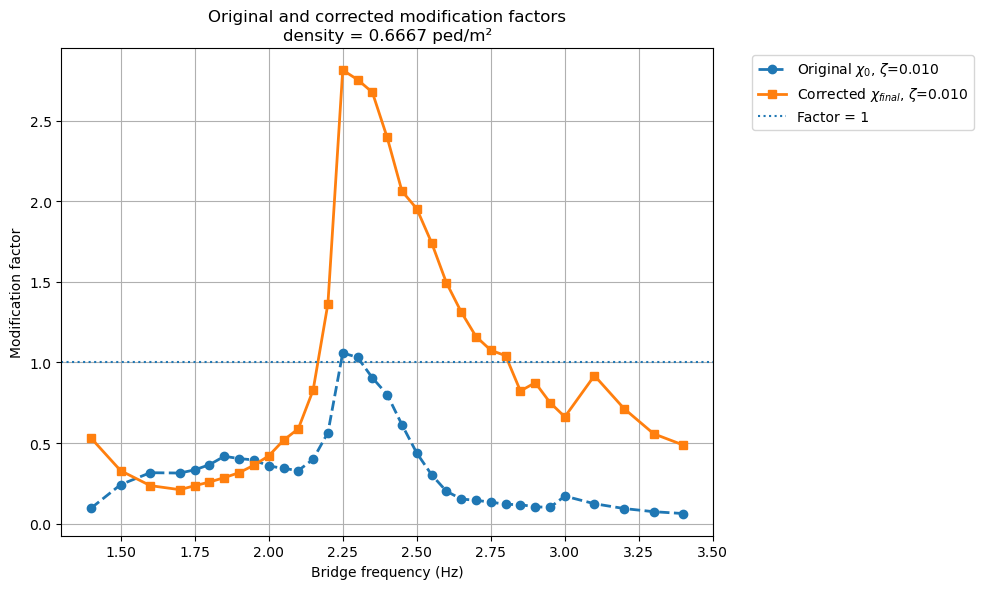

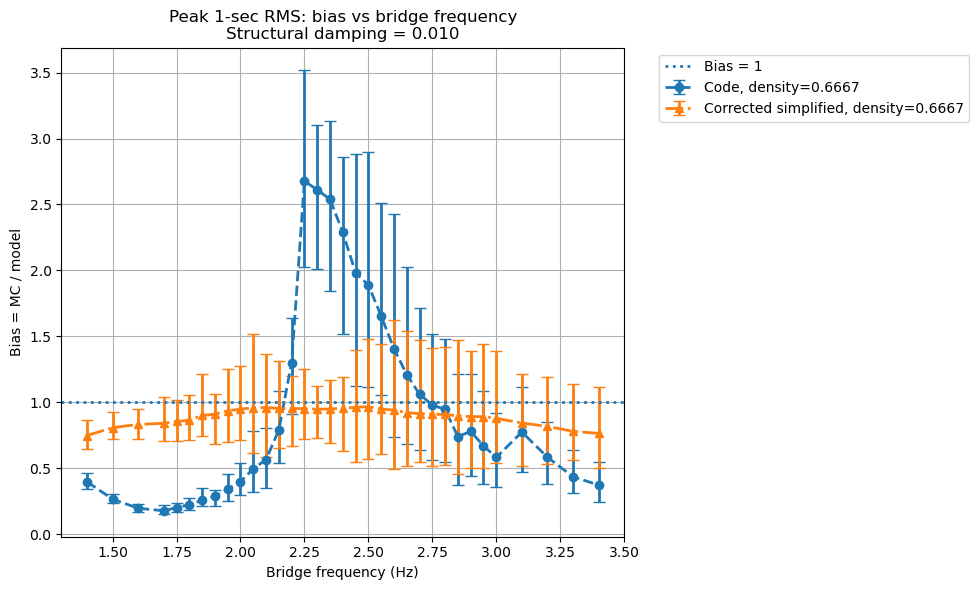

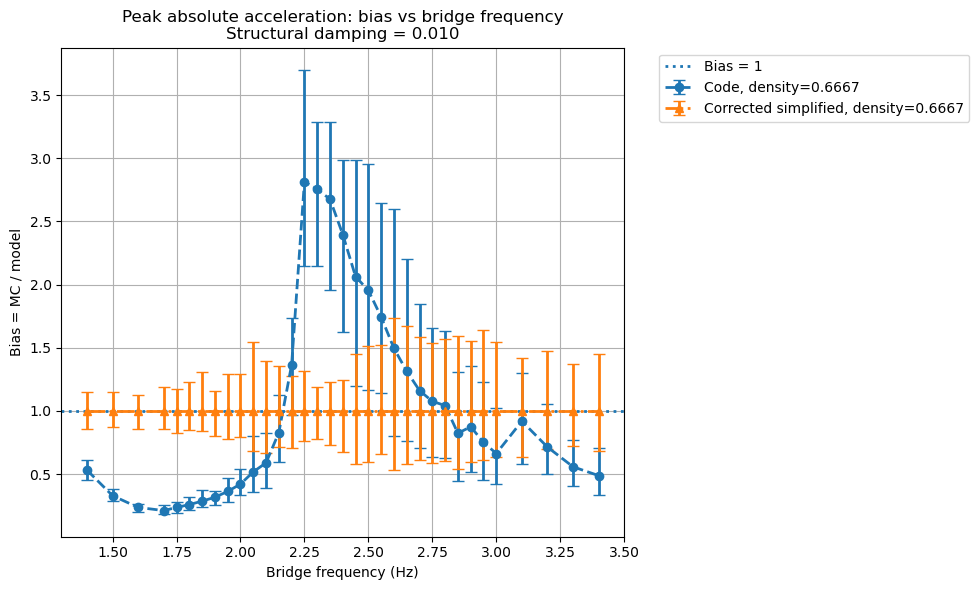

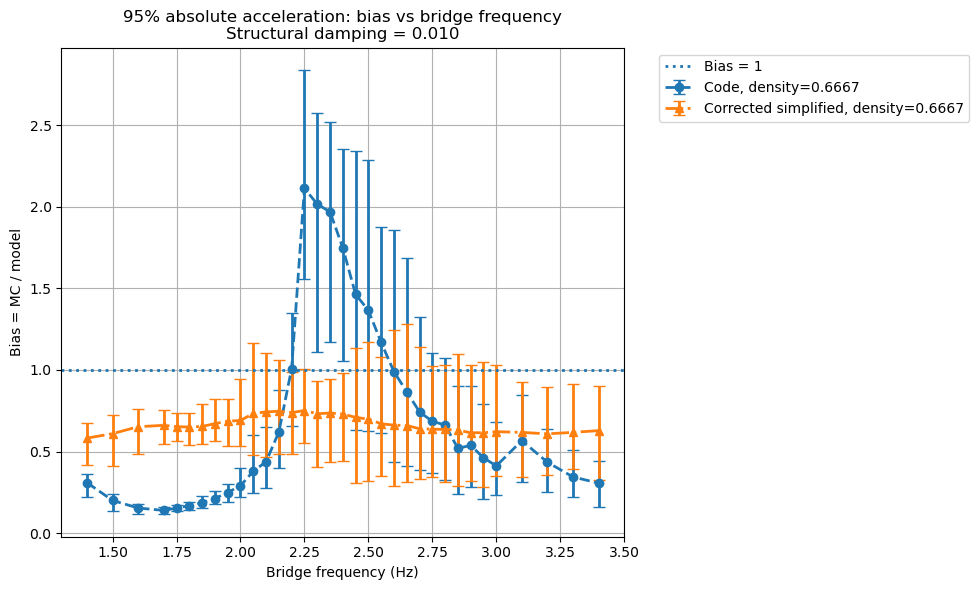

In [46]:
# ==================================================
# MULTI-FREQUENCY + MULTI-DAMPING MC + CODE + CORRECTED SIMPLIFIED SUMMARY
# Outputs:
#   1. original vs corrected modification factor plots
#   2. bias error bars for 3 response measures
# ==================================================

import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import torch
torch.set_num_threads(1)

import numpy as np
import matplotlib.pyplot as plt
import multiprocessing as mp
import pickle
import pandas as pd

from bias import run_simulation

from biascodefunction import (
    peak_rms_distribution,
    percentile_acc_distribution,
    peak_abs_acc_distribution,
    run_code_response_from_mc_inputs,
    interpolate_modification_factor_banded,
    running_mean_sd_1d,
    running_instantaneous_acc_stats
)


# --------------------------------------------------
# USER SETTINGS
# --------------------------------------------------
NUM_SIMULATIONS = 50
NUM_PROCESSES = 12

hht = 0.01
steady_start_time = 10.0
linear_mass = 500.0

peddamp = 0.30
pedBodyF = 3.10

Length = 50.0
Width = 2.0

# Multiple damping ratios
target_beamdamp_values = [0.010]

bridge_frequencies_to_run = [
    1.4, 1.5, 1.6, 1.7, 1.75, 1.8, 1.85, 1.9, 1.95, 2.0, 2.05, 2.1, 2.15, 2.2, 2.25, 2.3, 2.35, 2.4, 2.45, 2.5, 2.55, 2.6, 2.65, 2.7,
    2.75, 2.8, 2.85, 2.9, 2.95, 3.0, 3.1, 3.2, 3.3, 3.4
]

densities_to_run = [0.6667]

eps = 1e-12

# --------------------------------------------------
# Bias-correction settings
# --------------------------------------------------
CALIBRATION_MEASURE = "Peak absolute acceleration"
CORRECTION_STAT = "mean"      # options: "mean", "median", "p95"

# --------------------------------------------------
# Modification-factor database
# --------------------------------------------------
FORCE_FACTOR_FILE = "NMFR_2.pkl"

# Mass-ratio cap for interpolation database
MR_MIN_DATABASE = 0.0089
MR_MIN_USED = 0.0090
MR_MAX_DATABASE = 0.2954
MR_MAX_USED = 0.29


# --------------------------------------------------
# Helper: cap MC mass ratio inside interpolation range
# --------------------------------------------------
def cap_mass_ratio_for_interpolation(mc_mass_ratio):
    mc_mass_ratio = float(mc_mass_ratio)

    if mc_mass_ratio < MR_MIN_DATABASE:
        return MR_MIN_USED
    elif mc_mass_ratio > MR_MAX_DATABASE:
        return MR_MAX_USED
    else:
        return mc_mass_ratio


# --------------------------------------------------
# Response measures
# --------------------------------------------------
measure_specs = {
    "Peak 1-sec RMS": {
        "mc_key": "peak_rms",
        "code_key": "peak_1sec_rms",
    },
    "Peak absolute acceleration": {
        "mc_key": "peak_abs",
        "code_key": "peak_abs_acc",
    },
    "95% absolute acceleration": {
        "mc_key": "p95_abs",
        "code_key": "p95_abs_acc",
    },
}


# ==================================================
# MAIN LOOP
# ==================================================
if __name__ == "__main__":

    try:
        mp.set_start_method("spawn")
    except RuntimeError:
        pass

    # --------------------------------------------------
    # Load modification-factor database inside main block
    # --------------------------------------------------
    with open(FORCE_FACTOR_FILE, "rb") as f:
        ff_data = pickle.load(f)

    ff_results_all = ff_data["results_all"]
    ff_densities = ff_data["densities"]
    ff_damping_values = ff_data["damping_values"]
    ff_pedBodyF = ff_data["pedBodyF"]

    ff_bands_to_combine = list(ff_results_all.keys())

    print("Loaded NEW modification-factor database.")
    print("Available bands:", ff_bands_to_combine)
    print("Available damping values:", ff_damping_values)
    print("Available densities:", ff_densities)

    # Optional safety check
    test_band = ff_bands_to_combine[0]
    test_damp = ff_damping_values[0]
    test_bf = sorted(ff_results_all[test_band][test_damp].keys())[0]
    test_density = ff_densities[0]
    test_keys = ff_results_all[test_band][test_damp][test_bf][test_density].keys()

    print("\nDatabase check")
    print("--------------")
    print("Test band:", test_band)
    print("Test damping:", test_damp)
    print("Test bridge frequency:", test_bf)
    print("Test density:", test_density)
    print("Available keys:", test_keys)

    if "modification_factor" not in test_keys:
        raise KeyError("The database does not contain 'modification_factor'.")

    ctx = mp.get_context("spawn")
    rng = np.random.default_rng(12345)

    summary_rows = []
    convergence_rows = []

    with ctx.Pool(processes=NUM_PROCESSES) as pool:

        for target_beamdamp in target_beamdamp_values:

            print("\n" + "#" * 90)
            print(f"RUNNING STRUCTURAL DAMPING = {target_beamdamp:.4f}")
            print("#" * 90)

            for target_bf in bridge_frequencies_to_run:

                print("\n" + "=" * 80)
                print(f"RUNNING BRIDGE FREQUENCY = {target_bf:.3f} Hz")
                print("=" * 80)

                BeamFreq = np.array([target_bf, 4.0 * target_bf])
                Beamdamp = np.array([target_beamdamp])

                for density in densities_to_run:

                    print("\n" + "-" * 70)
                    print(f"Running density = {density:.4f}")
                    print("-" * 70)

                    # --------------------------------------------------
                    # Convert density to integer pedestrian counts
                    # --------------------------------------------------
                    total_peds_float = density * Length * Width
                    total_peds_int = int(round(total_peds_float))
                    total_peds_int = max(1, total_peds_int)

                    Tocity = total_peds_int // 2
                    Outcity = total_peds_int - Tocity

                    actual_density = (Tocity + Outcity) / (Length * Width)

                    print(f"Target density   = {density:.4f}")
                    print(f"Actual density   = {actual_density:.4f}")
                    print(f"Total peds       = {total_peds_int}")
                    print(f"Tocity, Outcity  = {Tocity}, {Outcity}")

                    # --------------------------------------------------
                    # Run MC reference simulations
                    # --------------------------------------------------
                    seeds = rng.integers(0, 2**31 - 1, size=NUM_SIMULATIONS)

                    args_list = [
                        (
                            int(seeds[i]),
                            peddamp,
                            pedBodyF,
                            BeamFreq,
                            Beamdamp,
                            Tocity,
                            Outcity,
                            Length,
                            Width
                        )
                        for i in range(NUM_SIMULATIONS)
                    ]

                    results = pool.map(run_simulation, args_list)

                    # --------------------------------------------------
                    # Extract MC acceleration histories and mass ratios
                    # --------------------------------------------------
                    accelerations = np.array([r[0] for r in results])
                    mean_mass_ratios = np.array([r[1] for r in results])

                    overall_mean_mass_ratio = np.mean(mean_mass_ratios)

                    print(f"MC acceleration shape       = {accelerations.shape}")
                    print(f"Mean modal mass ratio       = {overall_mean_mass_ratio:.6f}")

                    # --------------------------------------------------
                    # Remove initial transient
                    # --------------------------------------------------
                    steady_start_idx = int(round(steady_start_time / hht))

                    if steady_start_idx >= accelerations.shape[1]:
                        raise ValueError(
                            "steady_start_time is longer than acceleration time history."
                        )

                    accelerations_ss = accelerations[:, steady_start_idx:]

                    # --------------------------------------------------
                    # MC response distributions
                    # --------------------------------------------------
                    rms_histories, peak_rms_values = peak_rms_distribution(
                        accelerations_ss,
                        dt=hht,
                        window_sec=1.0
                    )

                    peak_abs_values = peak_abs_acc_distribution(
                        accelerations_ss
                    )

                    p95_abs_values = percentile_acc_distribution(
                        accelerations_ss,
                        percentile=95,
                        use_abs=True
                    )

                    mc_values = {
                        "peak_rms": peak_rms_values,
                        "peak_abs": peak_abs_values,
                        "p95_abs": p95_abs_values,
                    }

                    # ==================================================
                    # CONVERGENCE STATISTICS
                    # Instantaneous acceleration + response measures
                    # ==================================================

                    # --------------------------------------------------
                    # A) Instantaneous acceleration convergence
                    # --------------------------------------------------
                    sim_numbers_inst, inst_running_mean, inst_running_sd = (
                        running_instantaneous_acc_stats(accelerations_ss)
                    )

                    all_acc_values = accelerations_ss.reshape(-1)

                    inst_final_mean = np.mean(all_acc_values)
                    inst_final_sd = np.std(all_acc_values, ddof=1)

                    for i, n_sim in enumerate(sim_numbers_inst):

                        convergence_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "quantity": "Instantaneous acceleration",
                            "sim_number": int(n_sim),

                            "running_mean": inst_running_mean[i],
                            "running_sd": inst_running_sd[i],
                            "mean_abs_error": abs(inst_running_mean[i] - inst_final_mean),
                            "sd_abs_error": abs(inst_running_sd[i] - inst_final_sd),
                        })


                    # --------------------------------------------------
                    # B) Response-measure convergence
                    # --------------------------------------------------
                    for measure_name, spec in measure_specs.items():

                        measure_values = np.asarray(mc_values[spec["mc_key"]], dtype=float)
                        measure_values = measure_values[np.isfinite(measure_values)]

                        sim_numbers_m, measure_running_mean, measure_running_sd = (
                            running_mean_sd_1d(measure_values)
                        )

                        measure_final_mean = np.mean(measure_values)
                        measure_final_sd = np.std(measure_values, ddof=1)

                        for i, n_sim in enumerate(sim_numbers_m):

                            convergence_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "mean_modal_mass_ratio": overall_mean_mass_ratio,

                            "quantity": measure_name,
                            "sim_number": int(n_sim),

                            "running_mean": measure_running_mean[i],
                            "running_sd": measure_running_sd[i],

                            "mean_abs_error": abs(measure_running_mean[i] - measure_final_mean),
                            "sd_abs_error": abs(measure_running_sd[i] - measure_final_sd),
                        })

                    print("Convergence statistics stored for this case.")
                    # --------------------------------------------------
                    # Original deterministic/code model
                    # --------------------------------------------------
                    t_end = accelerations.shape[1] * hht

                    code_result, code_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=1.0
                    )

                    # --------------------------------------------------
                    # Interpolate original modification factor chi_0
                    # --------------------------------------------------
                    target_mass_ratio_used = cap_mass_ratio_for_interpolation(
                        overall_mean_mass_ratio
                    )

                    x_factor, interp_details = interpolate_modification_factor_banded(
                        results_all=ff_results_all,
                        target_bf=target_bf,
                        target_beamdamp=target_beamdamp,
                        target_mass_ratio=target_mass_ratio_used,
                        damping_values=ff_damping_values,
                        densities=ff_densities,
                        bands_to_combine=ff_bands_to_combine,
                        factor_key="modification_factor"
                    )

                    force_reduction_factor_used = x_factor

                    print("\nModification-factor interpolation")
                    print("---------------------------------")
                    print(f"Target bf                        = {target_bf:.6f}")
                    print(f"Target damping                   = {target_beamdamp:.6f}")
                    print(f"MC mean modal mass ratio          = {overall_mean_mass_ratio:.6f}")
                    print(f"Mass ratio used in interpolation  = {target_mass_ratio_used:.6f}")
                    print(f"Interpolated factor chi_0         = {x_factor:.6f}")

                    # --------------------------------------------------
                    # Simplified deterministic model using chi_0
                    # --------------------------------------------------
                    simplified_result, simplified_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=force_reduction_factor_used
                    )

                    # --------------------------------------------------
                    # Residual correction factor lambda
                    # --------------------------------------------------
                    cal_spec = measure_specs[CALIBRATION_MEASURE]

                    Y_cal = np.asarray(mc_values[cal_spec["mc_key"]], dtype=float)
                    Y_cal = Y_cal[np.isfinite(Y_cal)]

                    simp_val_cal = simplified_measures[cal_spec["code_key"]]

                    B_simp_cal = Y_cal / max(simp_val_cal, eps)

                    if CORRECTION_STAT == "mean":
                        residual_correction_factor = np.mean(B_simp_cal)

                    elif CORRECTION_STAT == "median":
                        residual_correction_factor = np.percentile(B_simp_cal, 50)

                    elif CORRECTION_STAT == "p95":
                        residual_correction_factor = np.percentile(B_simp_cal, 95)

                    else:
                        raise ValueError(
                            "CORRECTION_STAT must be 'mean', 'median', or 'p95'."
                        )

                    final_modification_factor = x_factor * residual_correction_factor

                    print("\nResidual bias correction")
                    print("------------------------")
                    print(f"Calibration measure        = {CALIBRATION_MEASURE}")
                    print(f"Correction statistic       = {CORRECTION_STAT}")
                    print(f"Initial factor chi_0        = {x_factor:.6f}")
                    print(f"Residual correction lambda  = {residual_correction_factor:.6f}")
                    print(f"Final factor chi_final      = {final_modification_factor:.6f}")

                    # --------------------------------------------------
                    # Corrected simplified deterministic model
                    # --------------------------------------------------
                    corrected_result, corrected_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=final_modification_factor
                    )

                    # --------------------------------------------------
                    # Bias distributions for all 3 measures
                    # --------------------------------------------------
                    for measure_name, spec in measure_specs.items():

                        Y_ref = np.asarray(mc_values[spec["mc_key"]], dtype=float)
                        Y_ref = Y_ref[np.isfinite(Y_ref)]

                        code_val = code_measures[spec["code_key"]]
                        simp_val = simplified_measures[spec["code_key"]]
                        corr_val = corrected_measures[spec["code_key"]]

                        B_code = Y_ref / max(code_val, eps)
                        B_simp = Y_ref / max(simp_val, eps)
                        B_corr = Y_ref / max(corr_val, eps)

                        summary_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "actual_density": actual_density,
                            "total_peds": total_peds_int,
                            "Tocity": Tocity,
                            "Outcity": Outcity,

                            "mean_modal_mass_ratio": overall_mean_mass_ratio,
                            "mass_ratio_used_for_interpolation": target_mass_ratio_used,

                            "initial_modification_factor": x_factor,
                            "residual_correction_factor": residual_correction_factor,
                            "final_modification_factor": final_modification_factor,

                            "calibration_measure": CALIBRATION_MEASURE,
                            "correction_stat": CORRECTION_STAT,

                            "measure": measure_name,

                            "mc_mean": np.mean(Y_ref),
                            "mc_p5": np.percentile(Y_ref, 5),
                            "mc_p50": np.percentile(Y_ref, 50),
                            "mc_p95": np.percentile(Y_ref, 95),

                            "code_prediction": code_val,
                            "simplified_prediction": simp_val,
                            "corrected_prediction": corr_val,

                            "code_bias_mean": np.mean(B_code),
                            "code_bias_p5": np.percentile(B_code, 5),
                            "code_bias_p50": np.percentile(B_code, 50),
                            "code_bias_p95": np.percentile(B_code, 95),

                            "simplified_bias_mean": np.mean(B_simp),
                            "simplified_bias_p5": np.percentile(B_simp, 5),
                            "simplified_bias_p50": np.percentile(B_simp, 50),
                            "simplified_bias_p95": np.percentile(B_simp, 95),

                            "corrected_bias_mean": np.mean(B_corr),
                            "corrected_bias_p5": np.percentile(B_corr, 5),
                            "corrected_bias_p50": np.percentile(B_corr, 50),
                            "corrected_bias_p95": np.percentile(B_corr, 95),
                        })

                        print(f"\n{measure_name}")
                        print(f"  MC mean                   = {np.mean(Y_ref):.6f}")
                        print(f"  Code prediction           = {code_val:.6f}")
                        print(f"  Simplified prediction     = {simp_val:.6f}")
                        print(f"  Corrected prediction      = {corr_val:.6f}")
                        print(f"  Code mean bias            = {np.mean(B_code):.6f}")
                        print(f"  Simplified mean bias      = {np.mean(B_simp):.6f}")
                        print(f"  Corrected simplified bias = {np.mean(B_corr):.6f}")

    # ==================================================
    # SAVE SUMMARY
    # ==================================================
    summary_df = pd.DataFrame(summary_rows)
    convergence_df = pd.DataFrame(convergence_rows)

    summary_pkl = "density0.6667_damping0.010_bias_summary.pkl"
    #convergence_pkl = "density0.6667_damping0.010_convergence_summary.pkl"

    with open(summary_pkl, "wb") as f:
        pickle.dump(summary_df, f, protocol=pickle.HIGHEST_PROTOCOL)

    #with open(convergence_pkl, "wb") as f:
        #pickle.dump(convergence_df, f, protocol=pickle.HIGHEST_PROTOCOL)

    print("\nSaved summary files:")
    print(summary_pkl)
    #print(convergence_pkl)

    # ==================================================
    # PLOT 1: ORIGINAL vs CORRECTED MODIFICATION FACTOR
    # One plot per density, all damping ratios included
    # ==================================================
    factor_df = summary_df.drop_duplicates(
        subset=["bridge_frequency", "target_density", "target_beamdamp"]
    ).copy()

    for density in densities_to_run:

        plt.figure(figsize=(10, 6))

        for target_beamdamp in target_beamdamp_values:

            sub = factor_df[
                (factor_df["target_density"] == density) &
                (factor_df["target_beamdamp"] == target_beamdamp)
            ].copy()

            sub = sub.sort_values("bridge_frequency")

            plt.plot(
                sub["bridge_frequency"],
                sub["initial_modification_factor"],
                marker="o",
                linestyle="--",
                linewidth=2,
                label=rf"Original $\chi_0$, $\zeta$={target_beamdamp:.3f}"
            )

            plt.plot(
                sub["bridge_frequency"],
                sub["final_modification_factor"],
                marker="s",
                linestyle="-",
                linewidth=2,
                label=rf"Corrected $\chi_{{final}}$, $\zeta$={target_beamdamp:.3f}"
            )

        plt.axhline(
            1.0,
            linestyle=":",
            linewidth=1.5,
            label="Factor = 1"
        )

        plt.xlabel("Bridge frequency (Hz)")
        plt.ylabel("Modification factor")
        plt.title(
            f"Original and corrected modification factors\n"
            f"density = {density:.4f} ped/m²"
        )

        plt.grid(True)
        plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.tight_layout()
        plt.show()

    # ==================================================
    # PLOTS 2-4: ERROR BARS FOR EACH RESPONSE MEASURE
    # One plot per vibration measure and damping ratio
    # Only Code and Corrected Simplified are plotted
    # ==================================================
    for target_beamdamp in target_beamdamp_values:

        for measure_name in measure_specs.keys():

            plt.figure(figsize=(10, 6))

            for density in densities_to_run:

                sub = summary_df[
                    (summary_df["target_beamdamp"] == target_beamdamp) &
                    (summary_df["target_density"] == density) &
                    (summary_df["measure"] == measure_name)
                ].copy()

                sub = sub.sort_values("bridge_frequency")

                x = sub["bridge_frequency"].values

                # -----------------------------
                # Original code bias
                # -----------------------------
                y_code = sub["code_bias_mean"].values
                y_code_p5 = sub["code_bias_p5"].values
                y_code_p95 = sub["code_bias_p95"].values

                yerr_code = np.vstack([
                    y_code - y_code_p5,
                    y_code_p95 - y_code
                ])

                plt.errorbar(
                    x,
                    y_code,
                    yerr=yerr_code,
                    marker="o",
                    linestyle="--",
                    linewidth=2,
                    capsize=4,
                    label=f"Code, density={density:.4f}"
                )

                # -----------------------------
                # Corrected simplified model bias
                # -----------------------------
                y_corr = sub["corrected_bias_mean"].values
                y_corr_p5 = sub["corrected_bias_p5"].values
                y_corr_p95 = sub["corrected_bias_p95"].values

                yerr_corr = np.vstack([
                    y_corr - y_corr_p5,
                    y_corr_p95 - y_corr
                ])

                plt.errorbar(
                    x,
                    y_corr,
                    yerr=yerr_corr,
                    marker="^",
                    linestyle="-.",
                    linewidth=2,
                    capsize=4,
                    label=f"Corrected simplified, density={density:.4f}"
                )

            plt.axhline(
                1.0,
                linestyle=":",
                linewidth=2,
                label="Bias = 1"
            )

            plt.xlabel("Bridge frequency (Hz)")
            plt.ylabel("Bias = MC / model")
            plt.title(
                f"{measure_name}: bias vs bridge frequency\n"
                f"Structural damping = {target_beamdamp:.3f}"
            )

            plt.grid(True)
            plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
            plt.tight_layout()
            plt.show()



Loaded NEW modification-factor database.
Available bands: ['1.25_to_4.60']
Available damping values: [0.005, 0.01, 0.015, 0.02, 0.025, 0.03]
Available densities: [0.0333, 0.1667, 0.3333, 0.5, 0.6667, 0.8333, 1.0]

Database check
--------------
Test band: 1.25_to_4.60
Test damping: 0.005
Test bridge frequency: 1.25
Test density: 0.0333
Available keys: dict_keys(['t', 'modalpedmass_i', 'modification_factor', 'frf_ratio', 'psi_ratio', 'psi_ratio_valid', 'f_eff_peak', 'f0_peak'])

##########################################################################################
RUNNING STRUCTURAL DAMPING = 0.0100
##########################################################################################

RUNNING BRIDGE FREQUENCY = 1.400 Hz

----------------------------------------------------------------------
Running density = 0.8333
----------------------------------------------------------------------
Target density   = 0.8333
Actual density   = 0.8300
Total peds       = 83
Tocity, Outcity  = 41

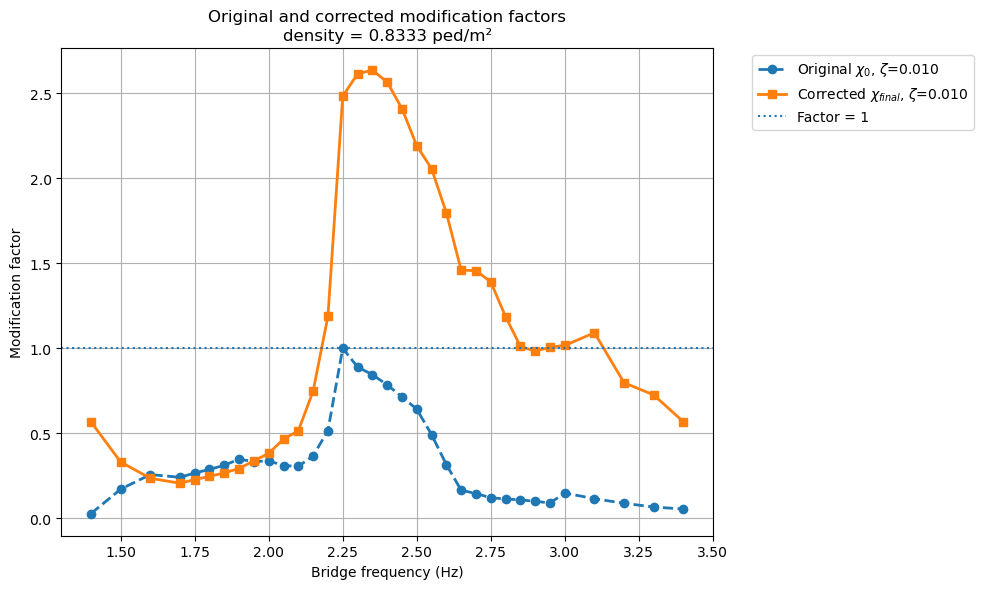

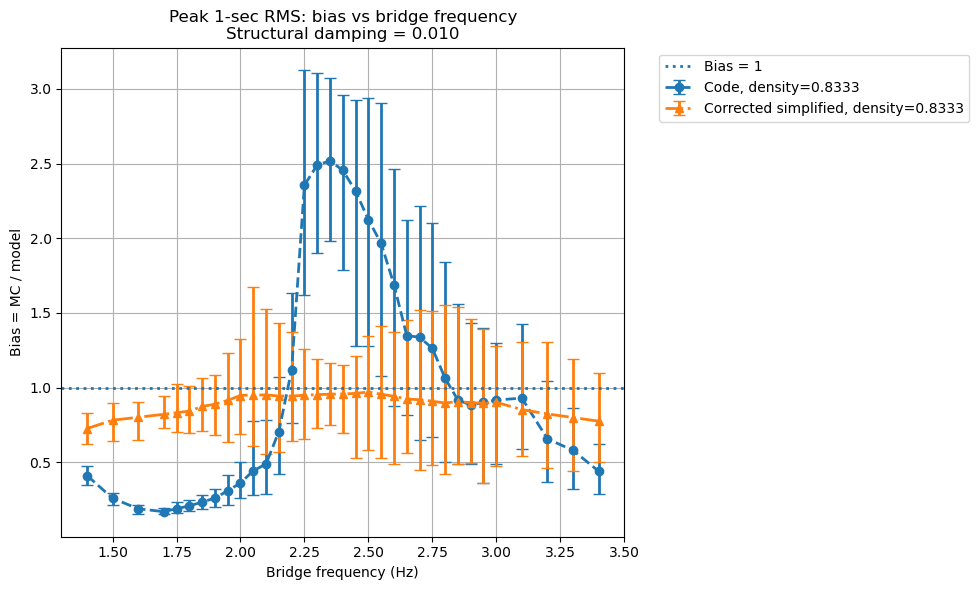

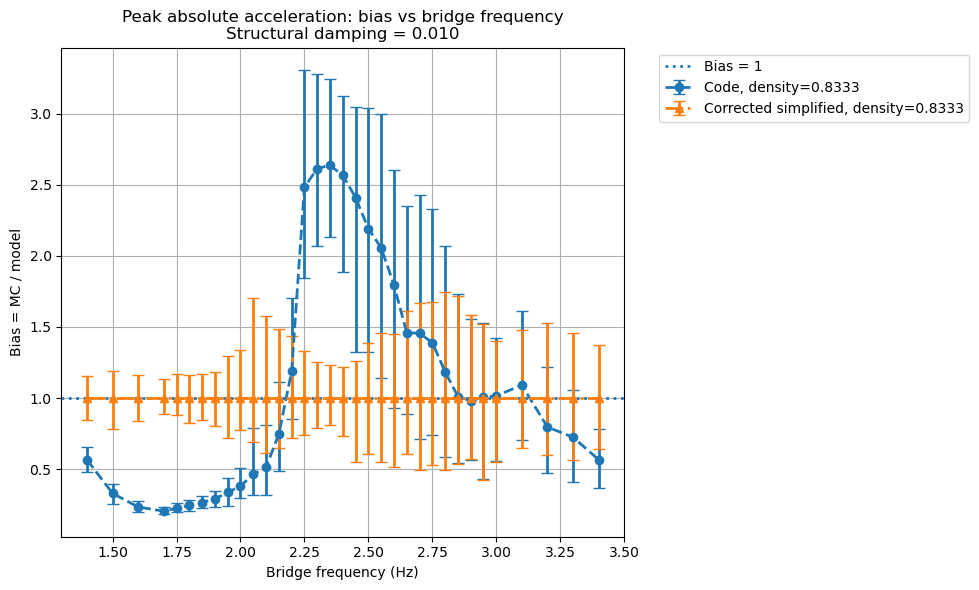

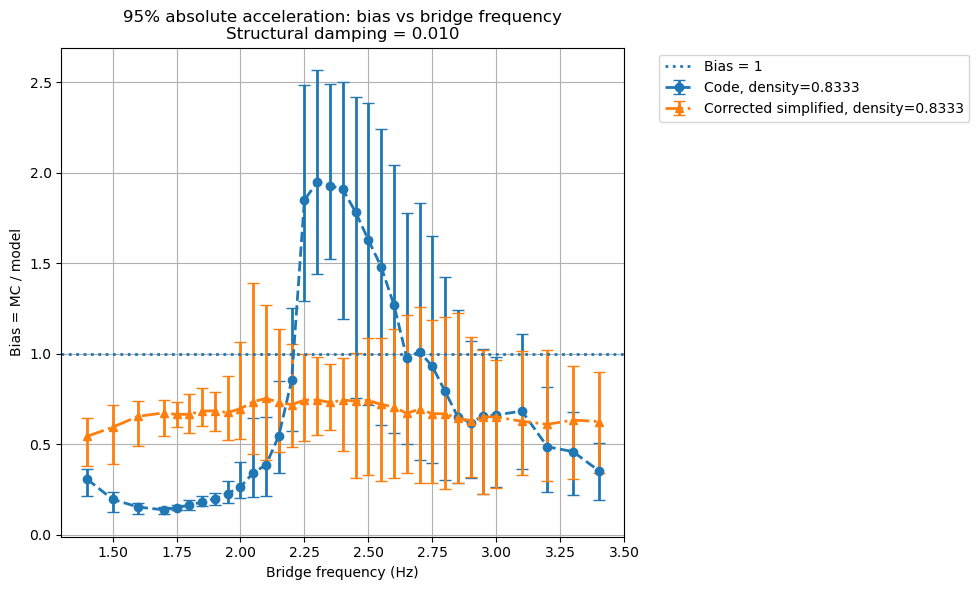

In [47]:
# ==================================================
# MULTI-FREQUENCY + MULTI-DAMPING MC + CODE + CORRECTED SIMPLIFIED SUMMARY
# Outputs:
#   1. original vs corrected modification factor plots
#   2. bias error bars for 3 response measures
# ==================================================

import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import torch
torch.set_num_threads(1)

import numpy as np
import matplotlib.pyplot as plt
import multiprocessing as mp
import pickle
import pandas as pd

from bias import run_simulation

from biascodefunction import (
    peak_rms_distribution,
    percentile_acc_distribution,
    peak_abs_acc_distribution,
    run_code_response_from_mc_inputs,
    interpolate_modification_factor_banded,
    running_mean_sd_1d,
    running_instantaneous_acc_stats
)


# --------------------------------------------------
# USER SETTINGS
# --------------------------------------------------
NUM_SIMULATIONS = 50
NUM_PROCESSES = 12

hht = 0.01
steady_start_time = 10.0
linear_mass = 500.0

peddamp = 0.30
pedBodyF = 3.10

Length = 50.0
Width = 2.0

# Multiple damping ratios
target_beamdamp_values = [0.010]

bridge_frequencies_to_run = [
    1.4, 1.5, 1.6, 1.7, 1.75, 1.8, 1.85, 1.9, 1.95, 2.0, 2.05, 2.1, 2.15, 2.2, 2.25, 2.3, 2.35, 2.4, 2.45, 2.5, 2.55, 2.6, 2.65, 2.7,
    2.75, 2.8, 2.85, 2.9, 2.95, 3.0, 3.1, 3.2, 3.3, 3.4
]

densities_to_run = [0.8333]

eps = 1e-12

# --------------------------------------------------
# Bias-correction settings
# --------------------------------------------------
CALIBRATION_MEASURE = "Peak absolute acceleration"
CORRECTION_STAT = "mean"      # options: "mean", "median", "p95"

# --------------------------------------------------
# Modification-factor database
# --------------------------------------------------
FORCE_FACTOR_FILE = "NMFR_2.pkl"

# Mass-ratio cap for interpolation database
MR_MIN_DATABASE = 0.0089
MR_MIN_USED = 0.0090
MR_MAX_DATABASE = 0.2954
MR_MAX_USED = 0.29


# --------------------------------------------------
# Helper: cap MC mass ratio inside interpolation range
# --------------------------------------------------
def cap_mass_ratio_for_interpolation(mc_mass_ratio):
    mc_mass_ratio = float(mc_mass_ratio)

    if mc_mass_ratio < MR_MIN_DATABASE:
        return MR_MIN_USED
    elif mc_mass_ratio > MR_MAX_DATABASE:
        return MR_MAX_USED
    else:
        return mc_mass_ratio


# --------------------------------------------------
# Response measures
# --------------------------------------------------
measure_specs = {
    "Peak 1-sec RMS": {
        "mc_key": "peak_rms",
        "code_key": "peak_1sec_rms",
    },
    "Peak absolute acceleration": {
        "mc_key": "peak_abs",
        "code_key": "peak_abs_acc",
    },
    "95% absolute acceleration": {
        "mc_key": "p95_abs",
        "code_key": "p95_abs_acc",
    },
}


# ==================================================
# MAIN LOOP
# ==================================================
if __name__ == "__main__":

    try:
        mp.set_start_method("spawn")
    except RuntimeError:
        pass

    # --------------------------------------------------
    # Load modification-factor database inside main block
    # --------------------------------------------------
    with open(FORCE_FACTOR_FILE, "rb") as f:
        ff_data = pickle.load(f)

    ff_results_all = ff_data["results_all"]
    ff_densities = ff_data["densities"]
    ff_damping_values = ff_data["damping_values"]
    ff_pedBodyF = ff_data["pedBodyF"]

    ff_bands_to_combine = list(ff_results_all.keys())

    print("Loaded NEW modification-factor database.")
    print("Available bands:", ff_bands_to_combine)
    print("Available damping values:", ff_damping_values)
    print("Available densities:", ff_densities)

    # Optional safety check
    test_band = ff_bands_to_combine[0]
    test_damp = ff_damping_values[0]
    test_bf = sorted(ff_results_all[test_band][test_damp].keys())[0]
    test_density = ff_densities[0]
    test_keys = ff_results_all[test_band][test_damp][test_bf][test_density].keys()

    print("\nDatabase check")
    print("--------------")
    print("Test band:", test_band)
    print("Test damping:", test_damp)
    print("Test bridge frequency:", test_bf)
    print("Test density:", test_density)
    print("Available keys:", test_keys)

    if "modification_factor" not in test_keys:
        raise KeyError("The database does not contain 'modification_factor'.")

    ctx = mp.get_context("spawn")
    rng = np.random.default_rng(12345)

    summary_rows = []
    convergence_rows = []

    with ctx.Pool(processes=NUM_PROCESSES) as pool:

        for target_beamdamp in target_beamdamp_values:

            print("\n" + "#" * 90)
            print(f"RUNNING STRUCTURAL DAMPING = {target_beamdamp:.4f}")
            print("#" * 90)

            for target_bf in bridge_frequencies_to_run:

                print("\n" + "=" * 80)
                print(f"RUNNING BRIDGE FREQUENCY = {target_bf:.3f} Hz")
                print("=" * 80)

                BeamFreq = np.array([target_bf, 4.0 * target_bf])
                Beamdamp = np.array([target_beamdamp])

                for density in densities_to_run:

                    print("\n" + "-" * 70)
                    print(f"Running density = {density:.4f}")
                    print("-" * 70)

                    # --------------------------------------------------
                    # Convert density to integer pedestrian counts
                    # --------------------------------------------------
                    total_peds_float = density * Length * Width
                    total_peds_int = int(round(total_peds_float))
                    total_peds_int = max(1, total_peds_int)

                    Tocity = total_peds_int // 2
                    Outcity = total_peds_int - Tocity

                    actual_density = (Tocity + Outcity) / (Length * Width)

                    print(f"Target density   = {density:.4f}")
                    print(f"Actual density   = {actual_density:.4f}")
                    print(f"Total peds       = {total_peds_int}")
                    print(f"Tocity, Outcity  = {Tocity}, {Outcity}")

                    # --------------------------------------------------
                    # Run MC reference simulations
                    # --------------------------------------------------
                    seeds = rng.integers(0, 2**31 - 1, size=NUM_SIMULATIONS)

                    args_list = [
                        (
                            int(seeds[i]),
                            peddamp,
                            pedBodyF,
                            BeamFreq,
                            Beamdamp,
                            Tocity,
                            Outcity,
                            Length,
                            Width
                        )
                        for i in range(NUM_SIMULATIONS)
                    ]

                    results = pool.map(run_simulation, args_list)

                    # --------------------------------------------------
                    # Extract MC acceleration histories and mass ratios
                    # --------------------------------------------------
                    accelerations = np.array([r[0] for r in results])
                    mean_mass_ratios = np.array([r[1] for r in results])

                    overall_mean_mass_ratio = np.mean(mean_mass_ratios)

                    print(f"MC acceleration shape       = {accelerations.shape}")
                    print(f"Mean modal mass ratio       = {overall_mean_mass_ratio:.6f}")

                    # --------------------------------------------------
                    # Remove initial transient
                    # --------------------------------------------------
                    steady_start_idx = int(round(steady_start_time / hht))

                    if steady_start_idx >= accelerations.shape[1]:
                        raise ValueError(
                            "steady_start_time is longer than acceleration time history."
                        )

                    accelerations_ss = accelerations[:, steady_start_idx:]

                    # --------------------------------------------------
                    # MC response distributions
                    # --------------------------------------------------
                    rms_histories, peak_rms_values = peak_rms_distribution(
                        accelerations_ss,
                        dt=hht,
                        window_sec=1.0
                    )

                    peak_abs_values = peak_abs_acc_distribution(
                        accelerations_ss
                    )

                    p95_abs_values = percentile_acc_distribution(
                        accelerations_ss,
                        percentile=95,
                        use_abs=True
                    )

                    mc_values = {
                        "peak_rms": peak_rms_values,
                        "peak_abs": peak_abs_values,
                        "p95_abs": p95_abs_values,
                    }

                    # ==================================================
                    # CONVERGENCE STATISTICS
                    # Instantaneous acceleration + response measures
                    # ==================================================

                    # --------------------------------------------------
                    # A) Instantaneous acceleration convergence
                    # --------------------------------------------------
                    sim_numbers_inst, inst_running_mean, inst_running_sd = (
                        running_instantaneous_acc_stats(accelerations_ss)
                    )

                    all_acc_values = accelerations_ss.reshape(-1)

                    inst_final_mean = np.mean(all_acc_values)
                    inst_final_sd = np.std(all_acc_values, ddof=1)

                    for i, n_sim in enumerate(sim_numbers_inst):

                        convergence_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "quantity": "Instantaneous acceleration",
                            "sim_number": int(n_sim),

                            "running_mean": inst_running_mean[i],
                            "running_sd": inst_running_sd[i],
                            "mean_abs_error": abs(inst_running_mean[i] - inst_final_mean),
                            "sd_abs_error": abs(inst_running_sd[i] - inst_final_sd),
                        })


                    # --------------------------------------------------
                    # B) Response-measure convergence
                    # --------------------------------------------------
                    for measure_name, spec in measure_specs.items():

                        measure_values = np.asarray(mc_values[spec["mc_key"]], dtype=float)
                        measure_values = measure_values[np.isfinite(measure_values)]

                        sim_numbers_m, measure_running_mean, measure_running_sd = (
                            running_mean_sd_1d(measure_values)
                        )

                        measure_final_mean = np.mean(measure_values)
                        measure_final_sd = np.std(measure_values, ddof=1)

                        for i, n_sim in enumerate(sim_numbers_m):

                            convergence_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "mean_modal_mass_ratio": overall_mean_mass_ratio,

                            "quantity": measure_name,
                            "sim_number": int(n_sim),

                            "running_mean": measure_running_mean[i],
                            "running_sd": measure_running_sd[i],

                            "mean_abs_error": abs(measure_running_mean[i] - measure_final_mean),
                            "sd_abs_error": abs(measure_running_sd[i] - measure_final_sd),
                        })

                    print("Convergence statistics stored for this case.")
                    # --------------------------------------------------
                    # Original deterministic/code model
                    # --------------------------------------------------
                    t_end = accelerations.shape[1] * hht

                    code_result, code_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=1.0
                    )

                    # --------------------------------------------------
                    # Interpolate original modification factor chi_0
                    # --------------------------------------------------
                    target_mass_ratio_used = cap_mass_ratio_for_interpolation(
                        overall_mean_mass_ratio
                    )

                    x_factor, interp_details = interpolate_modification_factor_banded(
                        results_all=ff_results_all,
                        target_bf=target_bf,
                        target_beamdamp=target_beamdamp,
                        target_mass_ratio=target_mass_ratio_used,
                        damping_values=ff_damping_values,
                        densities=ff_densities,
                        bands_to_combine=ff_bands_to_combine,
                        factor_key="modification_factor"
                    )

                    force_reduction_factor_used = x_factor

                    print("\nModification-factor interpolation")
                    print("---------------------------------")
                    print(f"Target bf                        = {target_bf:.6f}")
                    print(f"Target damping                   = {target_beamdamp:.6f}")
                    print(f"MC mean modal mass ratio          = {overall_mean_mass_ratio:.6f}")
                    print(f"Mass ratio used in interpolation  = {target_mass_ratio_used:.6f}")
                    print(f"Interpolated factor chi_0         = {x_factor:.6f}")

                    # --------------------------------------------------
                    # Simplified deterministic model using chi_0
                    # --------------------------------------------------
                    simplified_result, simplified_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=force_reduction_factor_used
                    )

                    # --------------------------------------------------
                    # Residual correction factor lambda
                    # --------------------------------------------------
                    cal_spec = measure_specs[CALIBRATION_MEASURE]

                    Y_cal = np.asarray(mc_values[cal_spec["mc_key"]], dtype=float)
                    Y_cal = Y_cal[np.isfinite(Y_cal)]

                    simp_val_cal = simplified_measures[cal_spec["code_key"]]

                    B_simp_cal = Y_cal / max(simp_val_cal, eps)

                    if CORRECTION_STAT == "mean":
                        residual_correction_factor = np.mean(B_simp_cal)

                    elif CORRECTION_STAT == "median":
                        residual_correction_factor = np.percentile(B_simp_cal, 50)

                    elif CORRECTION_STAT == "p95":
                        residual_correction_factor = np.percentile(B_simp_cal, 95)

                    else:
                        raise ValueError(
                            "CORRECTION_STAT must be 'mean', 'median', or 'p95'."
                        )

                    final_modification_factor = x_factor * residual_correction_factor

                    print("\nResidual bias correction")
                    print("------------------------")
                    print(f"Calibration measure        = {CALIBRATION_MEASURE}")
                    print(f"Correction statistic       = {CORRECTION_STAT}")
                    print(f"Initial factor chi_0        = {x_factor:.6f}")
                    print(f"Residual correction lambda  = {residual_correction_factor:.6f}")
                    print(f"Final factor chi_final      = {final_modification_factor:.6f}")

                    # --------------------------------------------------
                    # Corrected simplified deterministic model
                    # --------------------------------------------------
                    corrected_result, corrected_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=final_modification_factor
                    )

                    # --------------------------------------------------
                    # Bias distributions for all 3 measures
                    # --------------------------------------------------
                    for measure_name, spec in measure_specs.items():

                        Y_ref = np.asarray(mc_values[spec["mc_key"]], dtype=float)
                        Y_ref = Y_ref[np.isfinite(Y_ref)]

                        code_val = code_measures[spec["code_key"]]
                        simp_val = simplified_measures[spec["code_key"]]
                        corr_val = corrected_measures[spec["code_key"]]

                        B_code = Y_ref / max(code_val, eps)
                        B_simp = Y_ref / max(simp_val, eps)
                        B_corr = Y_ref / max(corr_val, eps)

                        summary_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "actual_density": actual_density,
                            "total_peds": total_peds_int,
                            "Tocity": Tocity,
                            "Outcity": Outcity,

                            "mean_modal_mass_ratio": overall_mean_mass_ratio,
                            "mass_ratio_used_for_interpolation": target_mass_ratio_used,

                            "initial_modification_factor": x_factor,
                            "residual_correction_factor": residual_correction_factor,
                            "final_modification_factor": final_modification_factor,

                            "calibration_measure": CALIBRATION_MEASURE,
                            "correction_stat": CORRECTION_STAT,

                            "measure": measure_name,

                            "mc_mean": np.mean(Y_ref),
                            "mc_p5": np.percentile(Y_ref, 5),
                            "mc_p50": np.percentile(Y_ref, 50),
                            "mc_p95": np.percentile(Y_ref, 95),

                            "code_prediction": code_val,
                            "simplified_prediction": simp_val,
                            "corrected_prediction": corr_val,

                            "code_bias_mean": np.mean(B_code),
                            "code_bias_p5": np.percentile(B_code, 5),
                            "code_bias_p50": np.percentile(B_code, 50),
                            "code_bias_p95": np.percentile(B_code, 95),

                            "simplified_bias_mean": np.mean(B_simp),
                            "simplified_bias_p5": np.percentile(B_simp, 5),
                            "simplified_bias_p50": np.percentile(B_simp, 50),
                            "simplified_bias_p95": np.percentile(B_simp, 95),

                            "corrected_bias_mean": np.mean(B_corr),
                            "corrected_bias_p5": np.percentile(B_corr, 5),
                            "corrected_bias_p50": np.percentile(B_corr, 50),
                            "corrected_bias_p95": np.percentile(B_corr, 95),
                        })

                        print(f"\n{measure_name}")
                        print(f"  MC mean                   = {np.mean(Y_ref):.6f}")
                        print(f"  Code prediction           = {code_val:.6f}")
                        print(f"  Simplified prediction     = {simp_val:.6f}")
                        print(f"  Corrected prediction      = {corr_val:.6f}")
                        print(f"  Code mean bias            = {np.mean(B_code):.6f}")
                        print(f"  Simplified mean bias      = {np.mean(B_simp):.6f}")
                        print(f"  Corrected simplified bias = {np.mean(B_corr):.6f}")

    # ==================================================
    # SAVE SUMMARY
    # ==================================================
    summary_df = pd.DataFrame(summary_rows)
    convergence_df = pd.DataFrame(convergence_rows)

    summary_pkl = "density0.8333_damping0.010_bias_summary.pkl"
    #convergence_pkl = "density0.8333_damping0.010_convergence_summary.pkl"

    with open(summary_pkl, "wb") as f:
        pickle.dump(summary_df, f, protocol=pickle.HIGHEST_PROTOCOL)

    #with open(convergence_pkl, "wb") as f:
        #pickle.dump(convergence_df, f, protocol=pickle.HIGHEST_PROTOCOL)

    print("\nSaved summary files:")
    print(summary_pkl)
    #print(convergence_pkl)

    # ==================================================
    # PLOT 1: ORIGINAL vs CORRECTED MODIFICATION FACTOR
    # One plot per density, all damping ratios included
    # ==================================================
    factor_df = summary_df.drop_duplicates(
        subset=["bridge_frequency", "target_density", "target_beamdamp"]
    ).copy()

    for density in densities_to_run:

        plt.figure(figsize=(10, 6))

        for target_beamdamp in target_beamdamp_values:

            sub = factor_df[
                (factor_df["target_density"] == density) &
                (factor_df["target_beamdamp"] == target_beamdamp)
            ].copy()

            sub = sub.sort_values("bridge_frequency")

            plt.plot(
                sub["bridge_frequency"],
                sub["initial_modification_factor"],
                marker="o",
                linestyle="--",
                linewidth=2,
                label=rf"Original $\chi_0$, $\zeta$={target_beamdamp:.3f}"
            )

            plt.plot(
                sub["bridge_frequency"],
                sub["final_modification_factor"],
                marker="s",
                linestyle="-",
                linewidth=2,
                label=rf"Corrected $\chi_{{final}}$, $\zeta$={target_beamdamp:.3f}"
            )

        plt.axhline(
            1.0,
            linestyle=":",
            linewidth=1.5,
            label="Factor = 1"
        )

        plt.xlabel("Bridge frequency (Hz)")
        plt.ylabel("Modification factor")
        plt.title(
            f"Original and corrected modification factors\n"
            f"density = {density:.4f} ped/m²"
        )

        plt.grid(True)
        plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.tight_layout()
        plt.show()

    # ==================================================
    # PLOTS 2-4: ERROR BARS FOR EACH RESPONSE MEASURE
    # One plot per vibration measure and damping ratio
    # Only Code and Corrected Simplified are plotted
    # ==================================================
    for target_beamdamp in target_beamdamp_values:

        for measure_name in measure_specs.keys():

            plt.figure(figsize=(10, 6))

            for density in densities_to_run:

                sub = summary_df[
                    (summary_df["target_beamdamp"] == target_beamdamp) &
                    (summary_df["target_density"] == density) &
                    (summary_df["measure"] == measure_name)
                ].copy()

                sub = sub.sort_values("bridge_frequency")

                x = sub["bridge_frequency"].values

                # -----------------------------
                # Original code bias
                # -----------------------------
                y_code = sub["code_bias_mean"].values
                y_code_p5 = sub["code_bias_p5"].values
                y_code_p95 = sub["code_bias_p95"].values

                yerr_code = np.vstack([
                    y_code - y_code_p5,
                    y_code_p95 - y_code
                ])

                plt.errorbar(
                    x,
                    y_code,
                    yerr=yerr_code,
                    marker="o",
                    linestyle="--",
                    linewidth=2,
                    capsize=4,
                    label=f"Code, density={density:.4f}"
                )

                # -----------------------------
                # Corrected simplified model bias
                # -----------------------------
                y_corr = sub["corrected_bias_mean"].values
                y_corr_p5 = sub["corrected_bias_p5"].values
                y_corr_p95 = sub["corrected_bias_p95"].values

                yerr_corr = np.vstack([
                    y_corr - y_corr_p5,
                    y_corr_p95 - y_corr
                ])

                plt.errorbar(
                    x,
                    y_corr,
                    yerr=yerr_corr,
                    marker="^",
                    linestyle="-.",
                    linewidth=2,
                    capsize=4,
                    label=f"Corrected simplified, density={density:.4f}"
                )

            plt.axhline(
                1.0,
                linestyle=":",
                linewidth=2,
                label="Bias = 1"
            )

            plt.xlabel("Bridge frequency (Hz)")
            plt.ylabel("Bias = MC / model")
            plt.title(
                f"{measure_name}: bias vs bridge frequency\n"
                f"Structural damping = {target_beamdamp:.3f}"
            )

            plt.grid(True)
            plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
            plt.tight_layout()
            plt.show()



Loaded NEW modification-factor database.
Available bands: ['1.25_to_4.60']
Available damping values: [0.005, 0.01, 0.015, 0.02, 0.025, 0.03]
Available densities: [0.0333, 0.1667, 0.3333, 0.5, 0.6667, 0.8333, 1.0]

Database check
--------------
Test band: 1.25_to_4.60
Test damping: 0.005
Test bridge frequency: 1.25
Test density: 0.0333
Available keys: dict_keys(['t', 'modalpedmass_i', 'modification_factor', 'frf_ratio', 'psi_ratio', 'psi_ratio_valid', 'f_eff_peak', 'f0_peak'])

##########################################################################################
RUNNING STRUCTURAL DAMPING = 0.0100
##########################################################################################

RUNNING BRIDGE FREQUENCY = 1.400 Hz

----------------------------------------------------------------------
Running density = 0.0333
----------------------------------------------------------------------
Target density   = 0.0333
Actual density   = 0.0300
Total peds       = 3
Tocity, Outcity  = 1, 

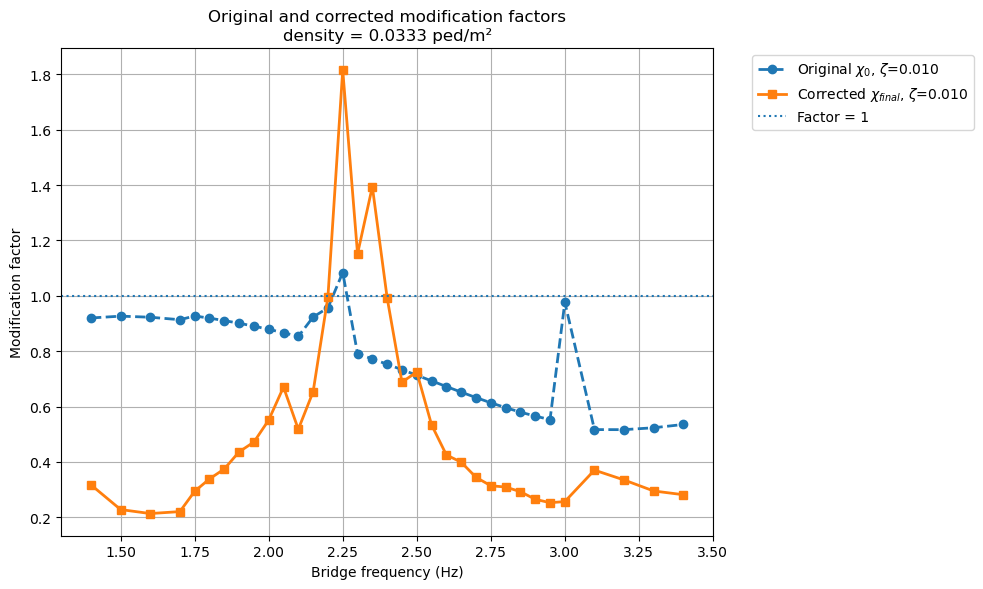

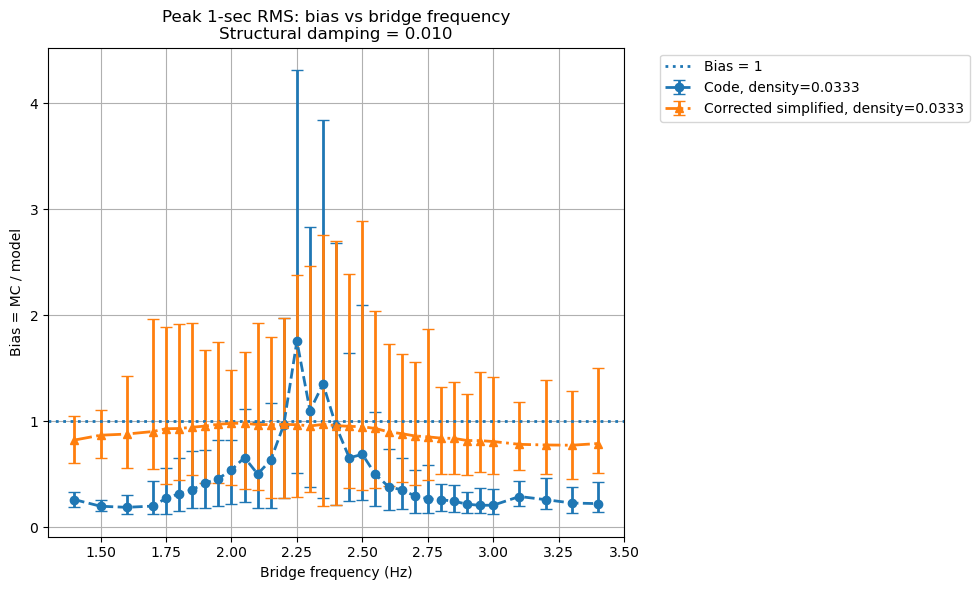

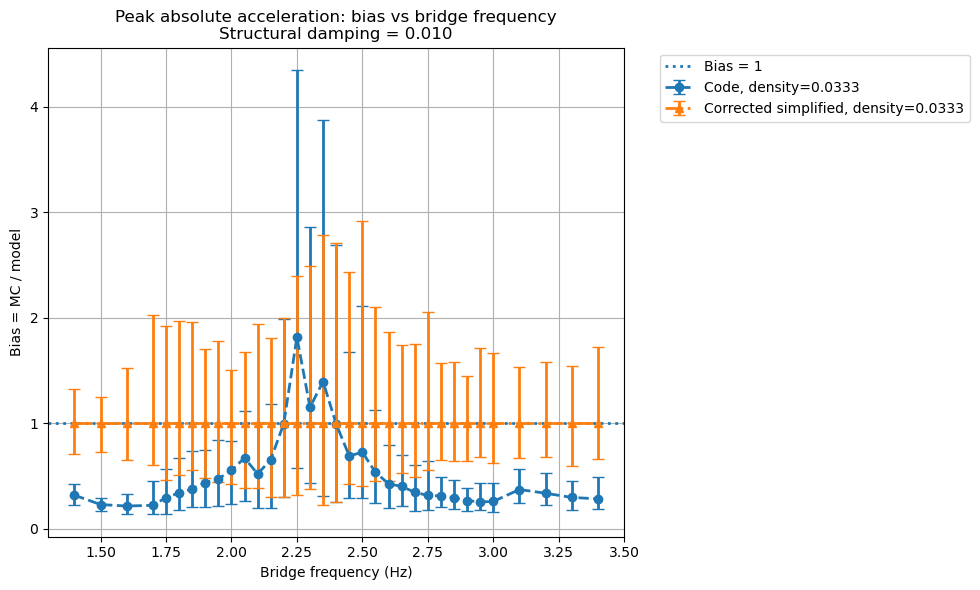

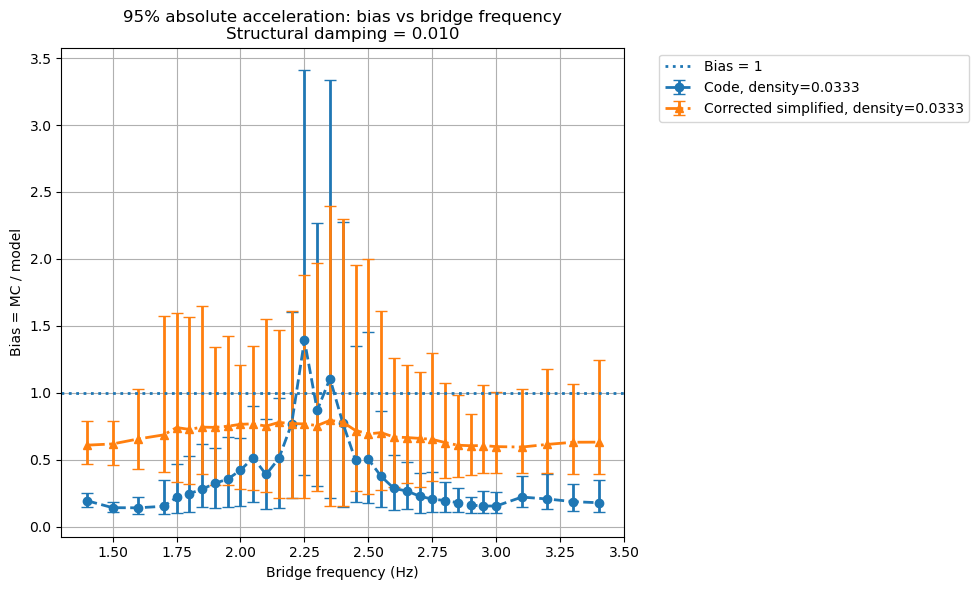

In [48]:
# ==================================================
# MULTI-FREQUENCY + MULTI-DAMPING MC + CODE + CORRECTED SIMPLIFIED SUMMARY
# Outputs:
#   1. original vs corrected modification factor plots
#   2. bias error bars for 3 response measures
# ==================================================

import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import torch
torch.set_num_threads(1)

import numpy as np
import matplotlib.pyplot as plt
import multiprocessing as mp
import pickle
import pandas as pd

from bias import run_simulation

from biascodefunction import (
    peak_rms_distribution,
    percentile_acc_distribution,
    peak_abs_acc_distribution,
    run_code_response_from_mc_inputs,
    interpolate_modification_factor_banded,
    running_mean_sd_1d,
    running_instantaneous_acc_stats
)


# --------------------------------------------------
# USER SETTINGS
# --------------------------------------------------
NUM_SIMULATIONS = 50
NUM_PROCESSES = 12

hht = 0.01
steady_start_time = 10.0
linear_mass = 500.0

peddamp = 0.30
pedBodyF = 3.10

Length = 50.0
Width = 2.0

# Multiple damping ratios
target_beamdamp_values = [0.010]

bridge_frequencies_to_run = [
    1.4, 1.5, 1.6, 1.7, 1.75, 1.8, 1.85, 1.9, 1.95, 2.0, 2.05, 2.1, 2.15, 2.2, 2.25, 2.3, 2.35, 2.4, 2.45, 2.5, 2.55, 2.6, 2.65, 2.7,
    2.75, 2.8, 2.85, 2.9, 2.95, 3.0, 3.1, 3.2, 3.3, 3.4
]

densities_to_run = [0.0333]

eps = 1e-12

# --------------------------------------------------
# Bias-correction settings
# --------------------------------------------------
CALIBRATION_MEASURE = "Peak absolute acceleration"
CORRECTION_STAT = "mean"      # options: "mean", "median", "p95"

# --------------------------------------------------
# Modification-factor database
# --------------------------------------------------
FORCE_FACTOR_FILE = "NMFR_2.pkl"

# Mass-ratio cap for interpolation database
MR_MIN_DATABASE = 0.0089
MR_MIN_USED = 0.0090
MR_MAX_DATABASE = 0.2954
MR_MAX_USED = 0.29


# --------------------------------------------------
# Helper: cap MC mass ratio inside interpolation range
# --------------------------------------------------
def cap_mass_ratio_for_interpolation(mc_mass_ratio):
    mc_mass_ratio = float(mc_mass_ratio)

    if mc_mass_ratio < MR_MIN_DATABASE:
        return MR_MIN_USED
    elif mc_mass_ratio > MR_MAX_DATABASE:
        return MR_MAX_USED
    else:
        return mc_mass_ratio


# --------------------------------------------------
# Response measures
# --------------------------------------------------
measure_specs = {
    "Peak 1-sec RMS": {
        "mc_key": "peak_rms",
        "code_key": "peak_1sec_rms",
    },
    "Peak absolute acceleration": {
        "mc_key": "peak_abs",
        "code_key": "peak_abs_acc",
    },
    "95% absolute acceleration": {
        "mc_key": "p95_abs",
        "code_key": "p95_abs_acc",
    },
}


# ==================================================
# MAIN LOOP
# ==================================================
if __name__ == "__main__":

    try:
        mp.set_start_method("spawn")
    except RuntimeError:
        pass

    # --------------------------------------------------
    # Load modification-factor database inside main block
    # --------------------------------------------------
    with open(FORCE_FACTOR_FILE, "rb") as f:
        ff_data = pickle.load(f)

    ff_results_all = ff_data["results_all"]
    ff_densities = ff_data["densities"]
    ff_damping_values = ff_data["damping_values"]
    ff_pedBodyF = ff_data["pedBodyF"]

    ff_bands_to_combine = list(ff_results_all.keys())

    print("Loaded NEW modification-factor database.")
    print("Available bands:", ff_bands_to_combine)
    print("Available damping values:", ff_damping_values)
    print("Available densities:", ff_densities)

    # Optional safety check
    test_band = ff_bands_to_combine[0]
    test_damp = ff_damping_values[0]
    test_bf = sorted(ff_results_all[test_band][test_damp].keys())[0]
    test_density = ff_densities[0]
    test_keys = ff_results_all[test_band][test_damp][test_bf][test_density].keys()

    print("\nDatabase check")
    print("--------------")
    print("Test band:", test_band)
    print("Test damping:", test_damp)
    print("Test bridge frequency:", test_bf)
    print("Test density:", test_density)
    print("Available keys:", test_keys)

    if "modification_factor" not in test_keys:
        raise KeyError("The database does not contain 'modification_factor'.")

    ctx = mp.get_context("spawn")
    rng = np.random.default_rng(12345)

    summary_rows = []
    convergence_rows = []

    with ctx.Pool(processes=NUM_PROCESSES) as pool:

        for target_beamdamp in target_beamdamp_values:

            print("\n" + "#" * 90)
            print(f"RUNNING STRUCTURAL DAMPING = {target_beamdamp:.4f}")
            print("#" * 90)

            for target_bf in bridge_frequencies_to_run:

                print("\n" + "=" * 80)
                print(f"RUNNING BRIDGE FREQUENCY = {target_bf:.3f} Hz")
                print("=" * 80)

                BeamFreq = np.array([target_bf, 4.0 * target_bf])
                Beamdamp = np.array([target_beamdamp])

                for density in densities_to_run:

                    print("\n" + "-" * 70)
                    print(f"Running density = {density:.4f}")
                    print("-" * 70)

                    # --------------------------------------------------
                    # Convert density to integer pedestrian counts
                    # --------------------------------------------------
                    total_peds_float = density * Length * Width
                    total_peds_int = int(round(total_peds_float))
                    total_peds_int = max(1, total_peds_int)

                    Tocity = total_peds_int // 2
                    Outcity = total_peds_int - Tocity

                    actual_density = (Tocity + Outcity) / (Length * Width)

                    print(f"Target density   = {density:.4f}")
                    print(f"Actual density   = {actual_density:.4f}")
                    print(f"Total peds       = {total_peds_int}")
                    print(f"Tocity, Outcity  = {Tocity}, {Outcity}")

                    # --------------------------------------------------
                    # Run MC reference simulations
                    # --------------------------------------------------
                    seeds = rng.integers(0, 2**31 - 1, size=NUM_SIMULATIONS)

                    args_list = [
                        (
                            int(seeds[i]),
                            peddamp,
                            pedBodyF,
                            BeamFreq,
                            Beamdamp,
                            Tocity,
                            Outcity,
                            Length,
                            Width
                        )
                        for i in range(NUM_SIMULATIONS)
                    ]

                    results = pool.map(run_simulation, args_list)

                    # --------------------------------------------------
                    # Extract MC acceleration histories and mass ratios
                    # --------------------------------------------------
                    accelerations = np.array([r[0] for r in results])
                    mean_mass_ratios = np.array([r[1] for r in results])

                    overall_mean_mass_ratio = np.mean(mean_mass_ratios)

                    print(f"MC acceleration shape       = {accelerations.shape}")
                    print(f"Mean modal mass ratio       = {overall_mean_mass_ratio:.6f}")

                    # --------------------------------------------------
                    # Remove initial transient
                    # --------------------------------------------------
                    steady_start_idx = int(round(steady_start_time / hht))

                    if steady_start_idx >= accelerations.shape[1]:
                        raise ValueError(
                            "steady_start_time is longer than acceleration time history."
                        )

                    accelerations_ss = accelerations[:, steady_start_idx:]

                    # --------------------------------------------------
                    # MC response distributions
                    # --------------------------------------------------
                    rms_histories, peak_rms_values = peak_rms_distribution(
                        accelerations_ss,
                        dt=hht,
                        window_sec=1.0
                    )

                    peak_abs_values = peak_abs_acc_distribution(
                        accelerations_ss
                    )

                    p95_abs_values = percentile_acc_distribution(
                        accelerations_ss,
                        percentile=95,
                        use_abs=True
                    )

                    mc_values = {
                        "peak_rms": peak_rms_values,
                        "peak_abs": peak_abs_values,
                        "p95_abs": p95_abs_values,
                    }

                    # ==================================================
                    # CONVERGENCE STATISTICS
                    # Instantaneous acceleration + response measures
                    # ==================================================

                    # --------------------------------------------------
                    # A) Instantaneous acceleration convergence
                    # --------------------------------------------------
                    sim_numbers_inst, inst_running_mean, inst_running_sd = (
                        running_instantaneous_acc_stats(accelerations_ss)
                    )

                    all_acc_values = accelerations_ss.reshape(-1)

                    inst_final_mean = np.mean(all_acc_values)
                    inst_final_sd = np.std(all_acc_values, ddof=1)

                    for i, n_sim in enumerate(sim_numbers_inst):

                        convergence_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "quantity": "Instantaneous acceleration",
                            "sim_number": int(n_sim),

                            "running_mean": inst_running_mean[i],
                            "running_sd": inst_running_sd[i],
                            "mean_abs_error": abs(inst_running_mean[i] - inst_final_mean),
                            "sd_abs_error": abs(inst_running_sd[i] - inst_final_sd),
                        })


                    # --------------------------------------------------
                    # B) Response-measure convergence
                    # --------------------------------------------------
                    for measure_name, spec in measure_specs.items():

                        measure_values = np.asarray(mc_values[spec["mc_key"]], dtype=float)
                        measure_values = measure_values[np.isfinite(measure_values)]

                        sim_numbers_m, measure_running_mean, measure_running_sd = (
                            running_mean_sd_1d(measure_values)
                        )

                        measure_final_mean = np.mean(measure_values)
                        measure_final_sd = np.std(measure_values, ddof=1)

                        for i, n_sim in enumerate(sim_numbers_m):

                            convergence_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "mean_modal_mass_ratio": overall_mean_mass_ratio,

                            "quantity": measure_name,
                            "sim_number": int(n_sim),

                            "running_mean": measure_running_mean[i],
                            "running_sd": measure_running_sd[i],

                            "mean_abs_error": abs(measure_running_mean[i] - measure_final_mean),
                            "sd_abs_error": abs(measure_running_sd[i] - measure_final_sd),
                        })

                    print("Convergence statistics stored for this case.")
                    # --------------------------------------------------
                    # Original deterministic/code model
                    # --------------------------------------------------
                    t_end = accelerations.shape[1] * hht

                    code_result, code_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=1.0
                    )

                    # --------------------------------------------------
                    # Interpolate original modification factor chi_0
                    # --------------------------------------------------
                    target_mass_ratio_used = cap_mass_ratio_for_interpolation(
                        overall_mean_mass_ratio
                    )

                    x_factor, interp_details = interpolate_modification_factor_banded(
                        results_all=ff_results_all,
                        target_bf=target_bf,
                        target_beamdamp=target_beamdamp,
                        target_mass_ratio=target_mass_ratio_used,
                        damping_values=ff_damping_values,
                        densities=ff_densities,
                        bands_to_combine=ff_bands_to_combine,
                        factor_key="modification_factor"
                    )

                    force_reduction_factor_used = x_factor

                    print("\nModification-factor interpolation")
                    print("---------------------------------")
                    print(f"Target bf                        = {target_bf:.6f}")
                    print(f"Target damping                   = {target_beamdamp:.6f}")
                    print(f"MC mean modal mass ratio          = {overall_mean_mass_ratio:.6f}")
                    print(f"Mass ratio used in interpolation  = {target_mass_ratio_used:.6f}")
                    print(f"Interpolated factor chi_0         = {x_factor:.6f}")

                    # --------------------------------------------------
                    # Simplified deterministic model using chi_0
                    # --------------------------------------------------
                    simplified_result, simplified_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=force_reduction_factor_used
                    )

                    # --------------------------------------------------
                    # Residual correction factor lambda
                    # --------------------------------------------------
                    cal_spec = measure_specs[CALIBRATION_MEASURE]

                    Y_cal = np.asarray(mc_values[cal_spec["mc_key"]], dtype=float)
                    Y_cal = Y_cal[np.isfinite(Y_cal)]

                    simp_val_cal = simplified_measures[cal_spec["code_key"]]

                    B_simp_cal = Y_cal / max(simp_val_cal, eps)

                    if CORRECTION_STAT == "mean":
                        residual_correction_factor = np.mean(B_simp_cal)

                    elif CORRECTION_STAT == "median":
                        residual_correction_factor = np.percentile(B_simp_cal, 50)

                    elif CORRECTION_STAT == "p95":
                        residual_correction_factor = np.percentile(B_simp_cal, 95)

                    else:
                        raise ValueError(
                            "CORRECTION_STAT must be 'mean', 'median', or 'p95'."
                        )

                    final_modification_factor = x_factor * residual_correction_factor

                    print("\nResidual bias correction")
                    print("------------------------")
                    print(f"Calibration measure        = {CALIBRATION_MEASURE}")
                    print(f"Correction statistic       = {CORRECTION_STAT}")
                    print(f"Initial factor chi_0        = {x_factor:.6f}")
                    print(f"Residual correction lambda  = {residual_correction_factor:.6f}")
                    print(f"Final factor chi_final      = {final_modification_factor:.6f}")

                    # --------------------------------------------------
                    # Corrected simplified deterministic model
                    # --------------------------------------------------
                    corrected_result, corrected_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=final_modification_factor
                    )

                    # --------------------------------------------------
                    # Bias distributions for all 3 measures
                    # --------------------------------------------------
                    for measure_name, spec in measure_specs.items():

                        Y_ref = np.asarray(mc_values[spec["mc_key"]], dtype=float)
                        Y_ref = Y_ref[np.isfinite(Y_ref)]

                        code_val = code_measures[spec["code_key"]]
                        simp_val = simplified_measures[spec["code_key"]]
                        corr_val = corrected_measures[spec["code_key"]]

                        B_code = Y_ref / max(code_val, eps)
                        B_simp = Y_ref / max(simp_val, eps)
                        B_corr = Y_ref / max(corr_val, eps)

                        summary_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "actual_density": actual_density,
                            "total_peds": total_peds_int,
                            "Tocity": Tocity,
                            "Outcity": Outcity,

                            "mean_modal_mass_ratio": overall_mean_mass_ratio,
                            "mass_ratio_used_for_interpolation": target_mass_ratio_used,

                            "initial_modification_factor": x_factor,
                            "residual_correction_factor": residual_correction_factor,
                            "final_modification_factor": final_modification_factor,

                            "calibration_measure": CALIBRATION_MEASURE,
                            "correction_stat": CORRECTION_STAT,

                            "measure": measure_name,

                            "mc_mean": np.mean(Y_ref),
                            "mc_p5": np.percentile(Y_ref, 5),
                            "mc_p50": np.percentile(Y_ref, 50),
                            "mc_p95": np.percentile(Y_ref, 95),

                            "code_prediction": code_val,
                            "simplified_prediction": simp_val,
                            "corrected_prediction": corr_val,

                            "code_bias_mean": np.mean(B_code),
                            "code_bias_p5": np.percentile(B_code, 5),
                            "code_bias_p50": np.percentile(B_code, 50),
                            "code_bias_p95": np.percentile(B_code, 95),

                            "simplified_bias_mean": np.mean(B_simp),
                            "simplified_bias_p5": np.percentile(B_simp, 5),
                            "simplified_bias_p50": np.percentile(B_simp, 50),
                            "simplified_bias_p95": np.percentile(B_simp, 95),

                            "corrected_bias_mean": np.mean(B_corr),
                            "corrected_bias_p5": np.percentile(B_corr, 5),
                            "corrected_bias_p50": np.percentile(B_corr, 50),
                            "corrected_bias_p95": np.percentile(B_corr, 95),
                        })

                        print(f"\n{measure_name}")
                        print(f"  MC mean                   = {np.mean(Y_ref):.6f}")
                        print(f"  Code prediction           = {code_val:.6f}")
                        print(f"  Simplified prediction     = {simp_val:.6f}")
                        print(f"  Corrected prediction      = {corr_val:.6f}")
                        print(f"  Code mean bias            = {np.mean(B_code):.6f}")
                        print(f"  Simplified mean bias      = {np.mean(B_simp):.6f}")
                        print(f"  Corrected simplified bias = {np.mean(B_corr):.6f}")

    # ==================================================
    # SAVE SUMMARY
    # ==================================================
    summary_df = pd.DataFrame(summary_rows)
    convergence_df = pd.DataFrame(convergence_rows)

    summary_pkl = "density0.0333_damping0.010_bias_summary.pkl"
    #convergence_pkl = "density0.0333_damping0.010_convergence_summary.pkl"

    with open(summary_pkl, "wb") as f:
        pickle.dump(summary_df, f, protocol=pickle.HIGHEST_PROTOCOL)

    #with open(convergence_pkl, "wb") as f:
        #pickle.dump(convergence_df, f, protocol=pickle.HIGHEST_PROTOCOL)

    print("\nSaved summary files:")
    print(summary_pkl)
    #print(convergence_pkl)

    # ==================================================
    # PLOT 1: ORIGINAL vs CORRECTED MODIFICATION FACTOR
    # One plot per density, all damping ratios included
    # ==================================================
    factor_df = summary_df.drop_duplicates(
        subset=["bridge_frequency", "target_density", "target_beamdamp"]
    ).copy()

    for density in densities_to_run:

        plt.figure(figsize=(10, 6))

        for target_beamdamp in target_beamdamp_values:

            sub = factor_df[
                (factor_df["target_density"] == density) &
                (factor_df["target_beamdamp"] == target_beamdamp)
            ].copy()

            sub = sub.sort_values("bridge_frequency")

            plt.plot(
                sub["bridge_frequency"],
                sub["initial_modification_factor"],
                marker="o",
                linestyle="--",
                linewidth=2,
                label=rf"Original $\chi_0$, $\zeta$={target_beamdamp:.3f}"
            )

            plt.plot(
                sub["bridge_frequency"],
                sub["final_modification_factor"],
                marker="s",
                linestyle="-",
                linewidth=2,
                label=rf"Corrected $\chi_{{final}}$, $\zeta$={target_beamdamp:.3f}"
            )

        plt.axhline(
            1.0,
            linestyle=":",
            linewidth=1.5,
            label="Factor = 1"
        )

        plt.xlabel("Bridge frequency (Hz)")
        plt.ylabel("Modification factor")
        plt.title(
            f"Original and corrected modification factors\n"
            f"density = {density:.4f} ped/m²"
        )

        plt.grid(True)
        plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.tight_layout()
        plt.show()

    # ==================================================
    # PLOTS 2-4: ERROR BARS FOR EACH RESPONSE MEASURE
    # One plot per vibration measure and damping ratio
    # Only Code and Corrected Simplified are plotted
    # ==================================================
    for target_beamdamp in target_beamdamp_values:

        for measure_name in measure_specs.keys():

            plt.figure(figsize=(10, 6))

            for density in densities_to_run:

                sub = summary_df[
                    (summary_df["target_beamdamp"] == target_beamdamp) &
                    (summary_df["target_density"] == density) &
                    (summary_df["measure"] == measure_name)
                ].copy()

                sub = sub.sort_values("bridge_frequency")

                x = sub["bridge_frequency"].values

                # -----------------------------
                # Original code bias
                # -----------------------------
                y_code = sub["code_bias_mean"].values
                y_code_p5 = sub["code_bias_p5"].values
                y_code_p95 = sub["code_bias_p95"].values

                yerr_code = np.vstack([
                    y_code - y_code_p5,
                    y_code_p95 - y_code
                ])

                plt.errorbar(
                    x,
                    y_code,
                    yerr=yerr_code,
                    marker="o",
                    linestyle="--",
                    linewidth=2,
                    capsize=4,
                    label=f"Code, density={density:.4f}"
                )

                # -----------------------------
                # Corrected simplified model bias
                # -----------------------------
                y_corr = sub["corrected_bias_mean"].values
                y_corr_p5 = sub["corrected_bias_p5"].values
                y_corr_p95 = sub["corrected_bias_p95"].values

                yerr_corr = np.vstack([
                    y_corr - y_corr_p5,
                    y_corr_p95 - y_corr
                ])

                plt.errorbar(
                    x,
                    y_corr,
                    yerr=yerr_corr,
                    marker="^",
                    linestyle="-.",
                    linewidth=2,
                    capsize=4,
                    label=f"Corrected simplified, density={density:.4f}"
                )

            plt.axhline(
                1.0,
                linestyle=":",
                linewidth=2,
                label="Bias = 1"
            )

            plt.xlabel("Bridge frequency (Hz)")
            plt.ylabel("Bias = MC / model")
            plt.title(
                f"{measure_name}: bias vs bridge frequency\n"
                f"Structural damping = {target_beamdamp:.3f}"
            )

            plt.grid(True)
            plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
            plt.tight_layout()
            plt.show()

